# Case Técnico — Especialista de Dados I

**BigQuery / SQL → Data Quality, filtros, agregações e regras em escala**  
**Python → estatística, visualização, interpretação e Machine Learning**

Objetivos do case:
- avaliar qualidade e consistência dos dados;
- análise do negócio;
- insights antes do modelo preditivo;

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gb_ml.io import estimate_query_bytes, read_query, table_metadata

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

## Consumo Bigquery

Antes de cada consulta, fazemos um **dry-run** para estimar bytes processados.

In [2]:
def run_bq(sql: str, label: str | None = None) -> pd.DataFrame:
    bytes_processed = estimate_query_bytes(
        sql,
        project_id=PROJECT_ID,
        location=BQ_LOCATION,
    )
    mb = bytes_processed / 1024**2
    print(f"[BigQuery] {label or 'query'} | estimativa processada: {mb:,.2f} MB")

    return read_query(
        sql,
        project_id=PROJECT_ID,
        location=BQ_LOCATION,
    )

# 1. Dados — fonte, schema e período

In [3]:
metadata, bq_schema = table_metadata(
    TABLE_ID,
    project_id=PROJECT_ID,
    location=BQ_LOCATION,
)

display(pd.DataFrame([metadata]))
display(bq_schema)

,table_id,num_rows,num_bytes,created,modified,location,partitioning_type,partition_field,clustering_fields
0,gms-prod-01.projeto_gb.fact_vendas,89566,6876011,2026-10-04 18:20:15.053000+00:00,2026-10-04 18:20:15.054000+00:00,us-east4,TimePartitioning,dt_hr_venda,"[des_canal_venda_final_agrup, des_categoria_ma..."


,name,field_type,mode,description
0,dt_hr_venda,DATETIME,NULLABLE,None
1,des_canal_venda_final_agrup,STRING,NULLABLE,None
2,des_categoria_material,STRING,NULLABLE,None
3,receita_aprovada,NUMERIC,NULLABLE,None
4,qt_material,INTEGER,NULLABLE,None
5,nr_pedidos,INTEGER,NULLABLE,None
6,vlr_venda_desconto,NUMERIC,NULLABLE,None


In [4]:
sql_overview = f"""
SELECT
  COUNT(*) AS linhas,
  MIN(dt_hr_venda) AS dt_min,
  MAX(dt_hr_venda) AS dt_max,
  COUNT(DISTINCT DATE(dt_hr_venda)) AS dias,
  COUNT(DISTINCT des_canal_venda_final_agrup) AS canais,
  COUNT(DISTINCT des_categoria_material) AS categorias_brutas
FROM `{TABLE_ID}`
WHERE 1=1
"""

overview = run_bq(sql_overview, "overview")
display(overview)

[BigQuery] overview | estimativa processada: 2.46 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,linhas,dt_min,dt_max,dias,canais,categorias_brutas
0,89566,2025-11-01,2026-06-30 23:00:00,242,2,5349


### Série diária (base para as seções 3 e 4)

Agregamos a base no grão diário uma única vez, no BigQuery. Esta série (`daily`) é reutilizada nos extremos, no baseline, nas correlações e na modelagem.

In [5]:
sql_daily = f"""
SELECT
  DATE(dt_hr_venda) AS data,

  CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
    WHEN 2 THEN 0
    WHEN 3 THEN 1
    WHEN 4 THEN 2
    WHEN 5 THEN 3
    WHEN 6 THEN 4
    WHEN 7 THEN 5
    WHEN 1 THEN 6
  END AS dia_semana_num,

  CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
    WHEN 2 THEN 'Segunda'
    WHEN 3 THEN 'Terça'
    WHEN 4 THEN 'Quarta'
    WHEN 5 THEN 'Quinta'
    WHEN 6 THEN 'Sexta'
    WHEN 7 THEN 'Sábado'
    WHEN 1 THEN 'Domingo'
  END AS dia_semana,

  FORMAT_DATE('%Y-%m', DATE(dt_hr_venda)) AS mes,
  EXTRACT(MONTH FROM DATE(dt_hr_venda)) AS mes_num,
  EXTRACT(YEAR FROM DATE(dt_hr_venda)) AS ano,
  EXTRACT(ISOWEEK FROM DATE(dt_hr_venda)) AS semana_ano,
  EXTRACT(ISOYEAR FROM DATE(dt_hr_venda)) AS ano_iso,
  DATE_TRUNC(DATE(dt_hr_venda), WEEK(MONDAY)) AS semana_inicio,
  IF(EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda)) IN (1, 7), 1, 0) AS fim_de_semana,

  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  CAST(SUM(vlr_venda_desconto) AS FLOAT64) AS vlr_venda_desconto,

  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(qt_material)
  ) AS preco_medio_item,

  SAFE_DIVIDE(
    CAST(SUM(receita_aprovada) AS FLOAT64),
    SUM(nr_pedidos)
  ) AS ticket_medio,

  SAFE_DIVIDE(
    SUM(qt_material),
    SUM(nr_pedidos)
  ) AS itens_por_pedido,

  SAFE_DIVIDE(
    CAST(SUM(vlr_venda_desconto) AS FLOAT64),
    CAST(SUM(receita_aprovada + vlr_venda_desconto) AS FLOAT64)
  ) AS taxa_desconto

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY ALL
ORDER BY 1
"""

daily = run_bq(sql_daily, "agregação diária")
daily["data"] = pd.to_datetime(daily["data"])

print(f"Linhas trazidas para Pandas: {len(daily)}")
display(daily.head())
display(
    daily[
        [
            "receita_aprovada",
            "nr_pedidos",
            "qt_material",
            "vlr_venda_desconto",
            "taxa_desconto",
            "preco_medio_item",
            "ticket_medio",
            "itens_por_pedido",
        ]
    ].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T
)

[BigQuery] agregação diária | estimativa processada: 4.78 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Linhas trazidas para Pandas: 242


,data,dia_semana_num,dia_semana,mes,mes_num,ano,semana_ano,ano_iso,semana_inicio,fim_de_semana,receita_aprovada,nr_pedidos,qt_material,vlr_venda_desconto,preco_medio_item,ticket_medio,itens_por_pedido,taxa_desconto
0,2025-11-01,5,Sábado,2025-11,11,2025,44,2025,2025-10-27,1,"1,726,330.8700",19347,27265,"1,068,230.0800",63.3167,89.2299,1.4093,0.3823
1,2025-11-02,6,Domingo,2025-11,11,2025,44,2025,2025-10-27,1,"1,944,052.5700",23668,36328,"1,656,038.4300",53.5139,82.1384,1.5349,0.4600
2,2025-11-03,0,Segunda,2025-11,11,2025,45,2025,2025-11-03,0,"6,165,950.5600",93066,148539,"8,539,908.1600",41.5107,66.2535,1.5961,0.5807
3,2025-11-04,1,Terça,2025-11,11,2025,45,2025,2025-11-03,0,"4,923,643.7800",80728,125065,"6,447,197.4600",39.3687,60.9905,1.5492,0.5670
4,2025-11-05,2,Quarta,2025-11,11,2025,45,2025,2025-11-03,0,"5,286,456.3800",94316,151324,"7,142,309.1400",34.9347,56.0505,1.6044,0.5747


,count,mean,std,min,1%,5%,50%,95%,99%,max
receita_aprovada,242.0000,"2,026,073.6637","1,262,137.3326","618,877.6800","768,213.6194","977,218.3075","1,692,029.7450","4,236,459.2380","6,383,015.5999","12,707,522.6100"
nr_pedidos,242.0000,"26,945.8471","24,154.4979","6,718.0000","7,210.6400","10,455.0500","19,916.0000","72,598.8000","112,920.0600","251,986.0000"
qt_material,242.0000,"40,893.3926","40,617.2974","9,090.0000","10,223.3000","14,914.4500","28,956.5000","120,074.9500","192,228.1900","422,860.0000"
vlr_venda_desconto,242.0000,"1,569,286.5404","1,832,156.9427","192,754.6700","243,596.4424","394,019.1020","1,043,355.1400","5,112,070.1875","8,263,758.5862","17,444,767.1200"
taxa_desconto,242.0000,0.3859,0.0925,0.2144,0.2243,0.2501,0.3787,0.5563,0.5804,0.5868
preco_medio_item,242.0000,56.9502,13.0434,29.0770,29.8999,34.8342,56.5462,76.3872,93.7876,100.0286
ticket_medio,242.0000,82.6509,14.4836,50.1818,50.4755,57.3318,82.7907,106.1485,119.2144,123.0793
itens_por_pedido,242.0000,1.4734,0.1322,1.2100,1.2556,1.3227,1.4336,1.7179,1.9490,2.0541


### Base dos KPIs e funções de visualização

As seções 1.1 a 1.4 seguem o mesmo roteiro para cada KPI:

1. **Geral:** total do período;
2. **Linha do tempo:** evolução mês a mês;
3. **Canal:** App × Site no geral e mês a mês;
4. **Categoria:** no geral e mês a mês;
5. **Canal × categoria:** App e Site lado a lado por categoria.

Para não repetir código, o BigQuery agrega **uma única vez** a base no grão **mês × canal × categoria** (categorias numéricas agrupadas como `CATEGORIA_INVALIDA`), e as funções abaixo montam cada visão a partir dela.

- **KPIs de soma** (`qt_material`, `nr_pedidos`, `receita_aprovada`): os gráficos mostram o **valor absoluto** e, no rótulo, o **share** (% do total).
- **KPIs de razão** (preço médio e taxa de desconto): os gráficos mostram o valor da razão, recalculada a partir das somas em cada recorte (média ponderada, nunca média de médias).

In [6]:
sql_base_kpi = f"""
SELECT
  DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
  des_canal_venda_final_agrup,
  IF(
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL,
    'CATEGORIA_INVALIDA',
    des_categoria_material
  ) AS des_categoria_material,
  SUM(qt_material) AS qt_material,
  SUM(nr_pedidos) AS nr_pedidos,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  CAST(SUM(vlr_venda_desconto) AS FLOAT64) AS vlr_venda_desconto
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1, 2, 3
"""

base_kpi = run_bq(sql_base_kpi, "base dos KPIs: mês x canal x categoria")
base_kpi["mes"] = pd.to_datetime(base_kpi["mes"]).dt.strftime("%Y-%m")
for coluna in ["qt_material", "nr_pedidos", "receita_aprovada", "vlr_venda_desconto"]:
    base_kpi[coluna] = base_kpi[coluna].astype(float)

# KPIs de razão: numerador e denominador são somados antes de dividir (média ponderada)
RAZOES = {
    "preco_medio": lambda d: d["receita_aprovada"] / d["nr_pedidos"],
    "taxa_desconto": lambda d: d["vlr_venda_desconto"] / (d["receita_aprovada"] + d["vlr_venda_desconto"]),
}
ROTULOS = {
    "qt_material": "qt_material",
    "nr_pedidos": "nr_pedidos",
    "receita_aprovada": "receita_aprovada (R$)",
    "preco_medio": "preço médio = receita_aprovada / nr_pedidos (R$)",
    "taxa_desconto": "taxa de desconto (%)",
}
CANAIS = ["App", "Site"]
CORES_CANAL = {"App": "#1f4e79", "Site": "#d17a22"}

# Ordem e cores das categorias (maior volume primeiro; inválida por último, em cinza)
categorias = (
    base_kpi[base_kpi["des_categoria_material"] != "CATEGORIA_INVALIDA"]
    .groupby("des_categoria_material")["qt_material"].sum()
    .sort_values(ascending=False)
    .index.tolist()
)
paleta = ["#1f4e79", "#2e86ab", "#8c564b", "#6a994e", "#c9a227", "#d17a22", "#a23b72", "#7d5ba6"]
cores = dict(zip(categorias, paleta))
categorias_com_invalida = categorias + ["CATEGORIA_INVALIDA"]
cores_com_invalida = {**cores, "CATEGORIA_INVALIDA": "#b0b0b0"}


def agregar(df: pd.DataFrame, por: list[str]) -> pd.DataFrame:
    """Soma as métricas base no nível `por` e recalcula os KPIs de razão."""
    soma = ["qt_material", "nr_pedidos", "receita_aprovada", "vlr_venda_desconto"]
    out = df.groupby(por, as_index=False)[soma].sum() if por else df[soma].sum().to_frame().T
    for nome, formula in RAZOES.items():
        out[nome] = formula(out)
    return out


def formatar(valor: float, metrica: str) -> str:
    """Formato curto para rótulos: mil/mi, R$ e %."""
    if metrica == "taxa_desconto":
        return f"{valor:.1%}"
    prefixo = "R$ " if metrica in ("receita_aprovada", "preco_medio") else ""
    if metrica == "preco_medio":
        return f"{prefixo}{valor:,.2f}"
    if abs(valor) >= 1e6:
        return f"{prefixo}{valor / 1e6:,.1f} mi"
    if abs(valor) >= 1e3:
        return f"{prefixo}{valor / 1e3:,.0f} mil"
    return f"{prefixo}{valor:,.0f}"


def eh_soma(metrica: str) -> bool:
    return metrica not in RAZOES


def eixo(ax, metrica: str, eixo_valor: str = "y") -> None:
    """Formata o eixo de valores no mesmo padrão dos rótulos (mil/mi, R$, %)."""
    from matplotlib.ticker import FuncFormatter
    alvo = ax.yaxis if eixo_valor == "y" else ax.xaxis
    alvo.set_major_formatter(FuncFormatter(lambda v, _: formatar(v, metrica) if v != 0 else "0"))


def kpi_geral(metricas: list[str]) -> None:
    """Tabela com o valor total do período de cada KPI."""
    total = agregar(base_kpi, [])
    display(pd.DataFrame({
        "kpi": metricas,
        "total_periodo": [formatar(total[m].iloc[0], m) for m in metricas],
    }))


def kpi_linha_do_tempo(metricas: list[str]) -> None:
    """Evolução mensal de cada KPI (barras para soma, linha para razão)."""
    mensal = agregar(base_kpi, ["mes"]).sort_values("mes")
    fig, axes = plt.subplots(1, len(metricas), figsize=(8 * len(metricas), 4.5), squeeze=False)
    for ax, m in zip(axes[0], metricas):
        if eh_soma(m):
            barras = ax.bar(mensal["mes"], mensal[m], color="#1f4e79")
            ax.bar_label(barras, labels=[formatar(v, m) for v in mensal[m]], fontsize=7, padding=2)
        else:
            ax.plot(mensal["mes"], mensal[m], marker="o", color="#1f4e79")
            for x, v in zip(mensal["mes"], mensal[m]):
                ax.annotate(formatar(v, m), (x, v), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=7)
            ax.margins(y=0.2)
        ax.set_title(f"{ROTULOS[m]} por mês")
        eixo(ax, m)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


def kpi_por_canal(metricas: list[str]) -> None:
    """Por canal: à esquerda o total do período; à direita a evolução mensal.

    Soma: barras com valor e share; mês a mês empilhado com o share de cada canal no rótulo.
    Razão: valor por canal e linhas mês a mês.
    """
    geral = agregar(base_kpi, ["des_canal_venda_final_agrup"]).set_index("des_canal_venda_final_agrup").loc[CANAIS]
    mensal = agregar(base_kpi, ["mes", "des_canal_venda_final_agrup"])
    fig, axes = plt.subplots(len(metricas), 2, figsize=(16, 4.5 * len(metricas)), squeeze=False,
                             gridspec_kw={"width_ratios": [1, 2.2]})
    for linha, m in zip(axes, metricas):
        ax = linha[0]
        barras = ax.bar(CANAIS, geral[m], color=[CORES_CANAL[c] for c in CANAIS])
        if eh_soma(m):
            share = geral[m] / geral[m].sum()
            rotulos = [f"{formatar(v, m)}\n({s:.1%})" for v, s in zip(geral[m], share)]
        else:
            rotulos = [formatar(v, m) for v in geral[m]]
        ax.bar_label(barras, labels=rotulos, fontsize=8, padding=2)
        ax.margins(y=0.2)
        ax.set_title(f"{ROTULOS[m]} — período")
        eixo(ax, m)

        ax = linha[1]
        pivo = mensal.pivot(index="mes", columns="des_canal_venda_final_agrup", values=m)[CANAIS].sort_index()
        if eh_soma(m):
            share = pivo.div(pivo.sum(axis=1), axis=0)
            base = np.zeros(len(pivo))
            for canal in CANAIS:
                barras = ax.bar(pivo.index, pivo[canal], bottom=base, color=CORES_CANAL[canal], label=canal)
                ax.bar_label(barras, labels=[f"{s:.0%}" for s in share[canal]], label_type="center",
                             fontsize=7, color="white")
                base += pivo[canal].to_numpy()
        else:
            for canal in CANAIS:
                ax.plot(pivo.index, pivo[canal], marker="o", color=CORES_CANAL[canal], label=canal)
                for x, v in zip(pivo.index, pivo[canal]):
                    ax.annotate(formatar(v, m), (x, v), xytext=(0, 6), textcoords="offset points",
                                ha="center", fontsize=7, color=CORES_CANAL[canal])
            ax.margins(y=0.2)
        ax.set_title(f"{ROTULOS[m]} — mês a mês por canal")
        eixo(ax, m)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def kpi_por_categoria(metricas: list[str]) -> None:
    """Por categoria: à esquerda o total do período; à direita a evolução mensal.

    Soma: barras com valor e share; mês a mês empilhado (share no rótulo quando >= 5%).
    Razão: valor por categoria e linhas mês a mês.
    """
    geral = agregar(base_kpi, ["des_categoria_material"]).set_index("des_categoria_material")
    mensal = agregar(base_kpi, ["mes", "des_categoria_material"])
    fig, axes = plt.subplots(len(metricas), 2, figsize=(18, 5.5 * len(metricas)), squeeze=False,
                             gridspec_kw={"width_ratios": [1, 1.8]})
    for linha, m in zip(axes, metricas):
        ax = linha[0]
        ordem = geral[m].reindex(categorias_com_invalida).sort_values()
        barras = ax.barh(ordem.index, ordem.values, color=[cores_com_invalida[c] for c in ordem.index])
        if eh_soma(m):
            share = ordem / ordem.sum()
            rotulos = [f"{formatar(v, m)} ({s:.1%})" for v, s in zip(ordem.values, share)]
        else:
            rotulos = [formatar(v, m) for v in ordem.values]
        ax.bar_label(barras, labels=rotulos, fontsize=7, padding=2)
        ax.margins(x=0.3)
        ax.set_title(f"{ROTULOS[m]} — período")
        eixo(ax, m, "x")

        ax = linha[1]
        pivo = (
            mensal.pivot(index="mes", columns="des_categoria_material", values=m)
            .reindex(columns=categorias_com_invalida).sort_index()
        )
        if eh_soma(m):
            share = pivo.div(pivo.sum(axis=1), axis=0)
            base = np.zeros(len(pivo))
            for cat in categorias_com_invalida:
                barras = ax.bar(pivo.index, pivo[cat], bottom=base, color=cores_com_invalida[cat], label=cat)
                ax.bar_label(barras, labels=[f"{s:.0%}" if s >= 0.05 else "" for s in share[cat]],
                             label_type="center", fontsize=6, color="white")
                base += pivo[cat].fillna(0).to_numpy()
        else:
            for cat in categorias_com_invalida:
                ax.plot(pivo.index, pivo[cat], marker="o", markersize=3, linewidth=1.8,
                        color=cores_com_invalida[cat], label=cat)
        ax.set_title(f"{ROTULOS[m]} — mês a mês por categoria")
        eixo(ax, m)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
    fig.tight_layout()
    plt.show()


def kpi_canal_x_categoria(metricas: list[str]) -> None:
    """App e Site lado a lado, por categoria (mesma ordem de categorias nos dois painéis).

    Soma: valor absoluto e share da categoria dentro do canal, cada canal na sua escala
    (o Site é ~1/4 do App; o share no rótulo é o que se compara).
    Razão: valor da razão, com a mesma escala nos dois canais.
    """
    cc = agregar(base_kpi, ["des_canal_venda_final_agrup", "des_categoria_material"])
    fig, axes = plt.subplots(len(metricas), 2, figsize=(16, 5 * len(metricas)), squeeze=False)
    for linha, m in zip(axes, metricas):
        for ax, canal in zip(linha, CANAIS):
            serie = (
                cc[cc["des_canal_venda_final_agrup"] == canal]
                .set_index("des_categoria_material")[m]
                .reindex(categorias_com_invalida[::-1])
            )
            barras = ax.barh(serie.index, serie.values, color=[cores_com_invalida[c] for c in serie.index])
            if eh_soma(m):
                share = serie / serie.sum()
                rotulos = [f"{formatar(v, m)} ({s:.1%})" for v, s in zip(serie.values, share)]
            else:
                rotulos = [formatar(v, m) for v in serie.values]
            ax.bar_label(barras, labels=rotulos, fontsize=7, padding=2)
            ax.margins(x=0.3)
            ax.set_title(f"{canal} — {ROTULOS[m]} por categoria")
            eixo(ax, m, "x")
        if not eh_soma(m):
            # razões na mesma escala para comparar App x Site diretamente
            limite = max(a.get_xlim()[1] for a in linha)
            for a in linha:
                a.set_xlim(0, limite)
    fig.tight_layout()
    plt.show()

[BigQuery] base dos KPIs: mês x canal x categoria | estimativa processada: 6.56 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## 1.1 `qt_material` e `nr_pedidos`

`qt_material` (itens vendidos) é o **target** do forecast; `nr_pedidos` é a métrica de **apoio**. Analisamos os dois juntos: geral → linha do tempo → canal → categoria → App × Site por categoria.

,kpi,total_periodo
0,qt_material,9.9 mi
1,nr_pedidos,6.5 mi


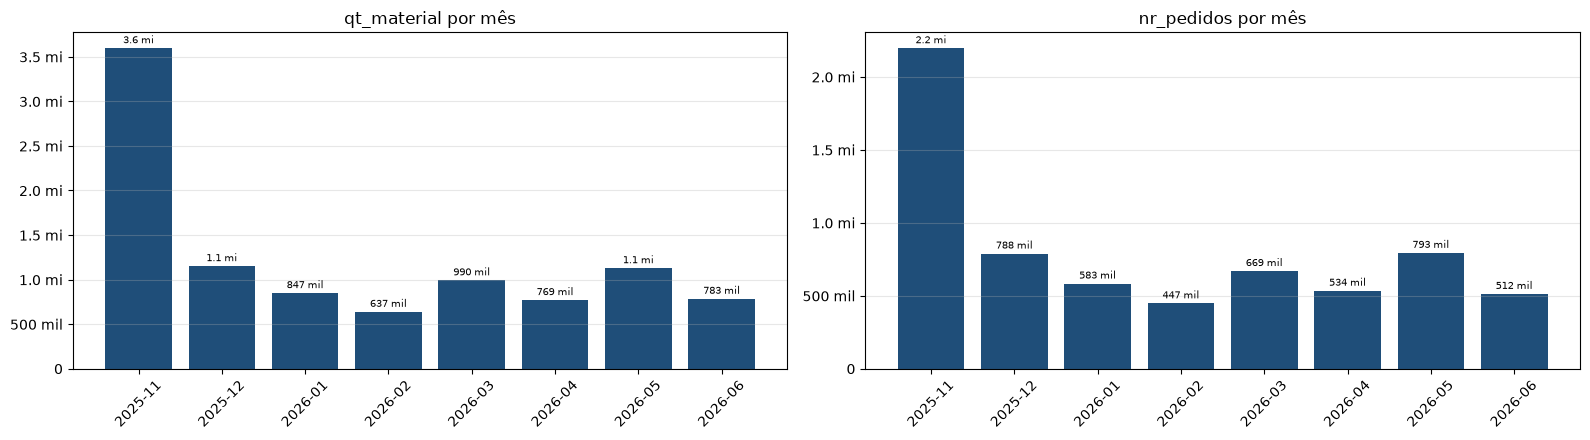

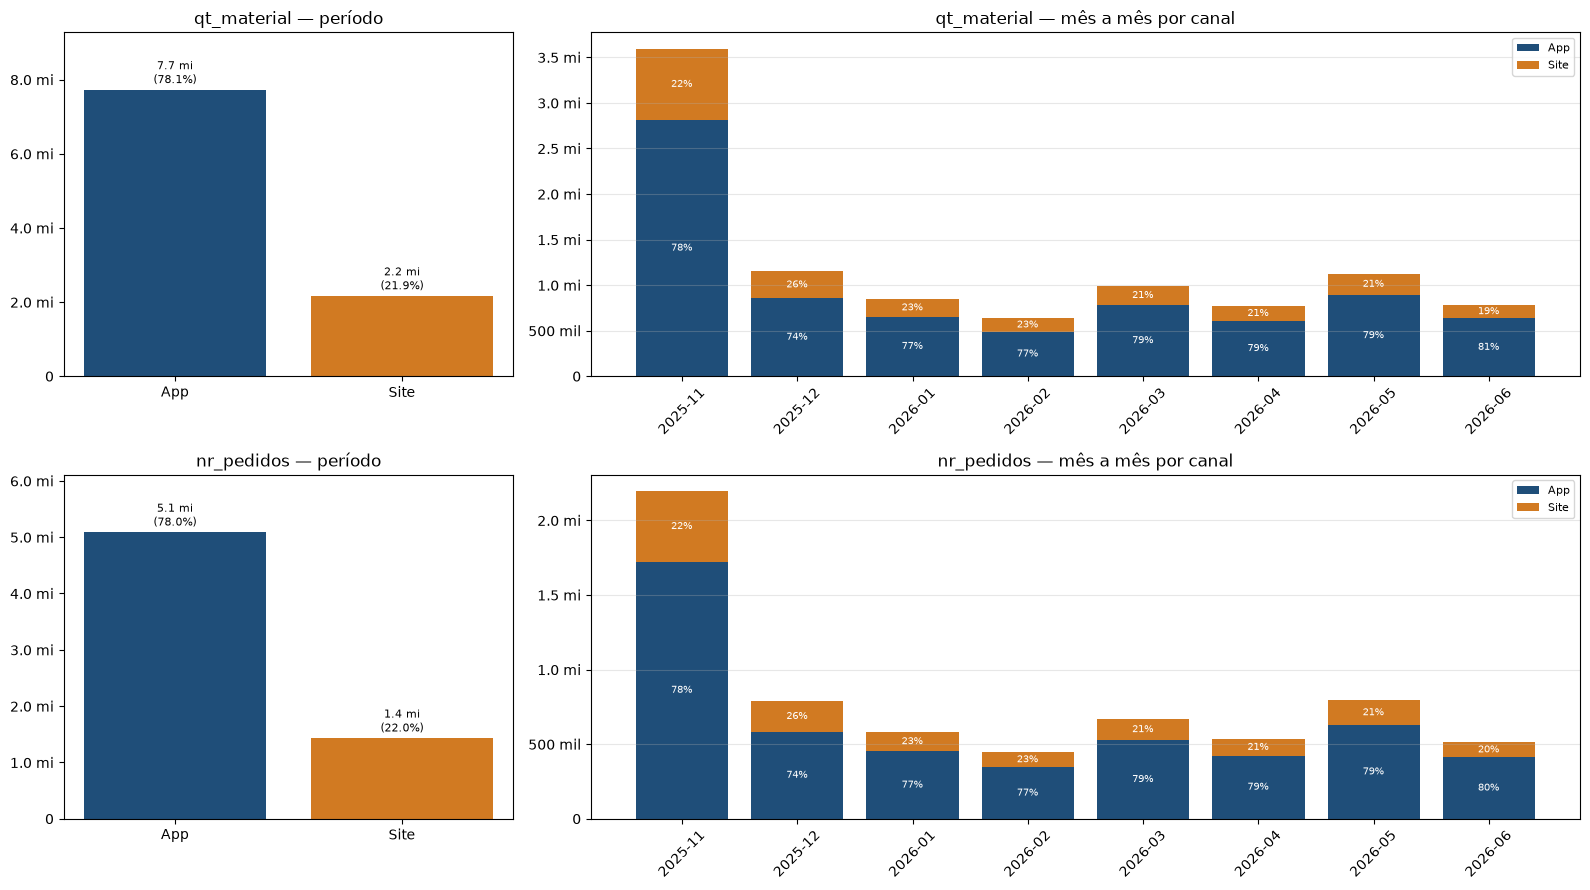

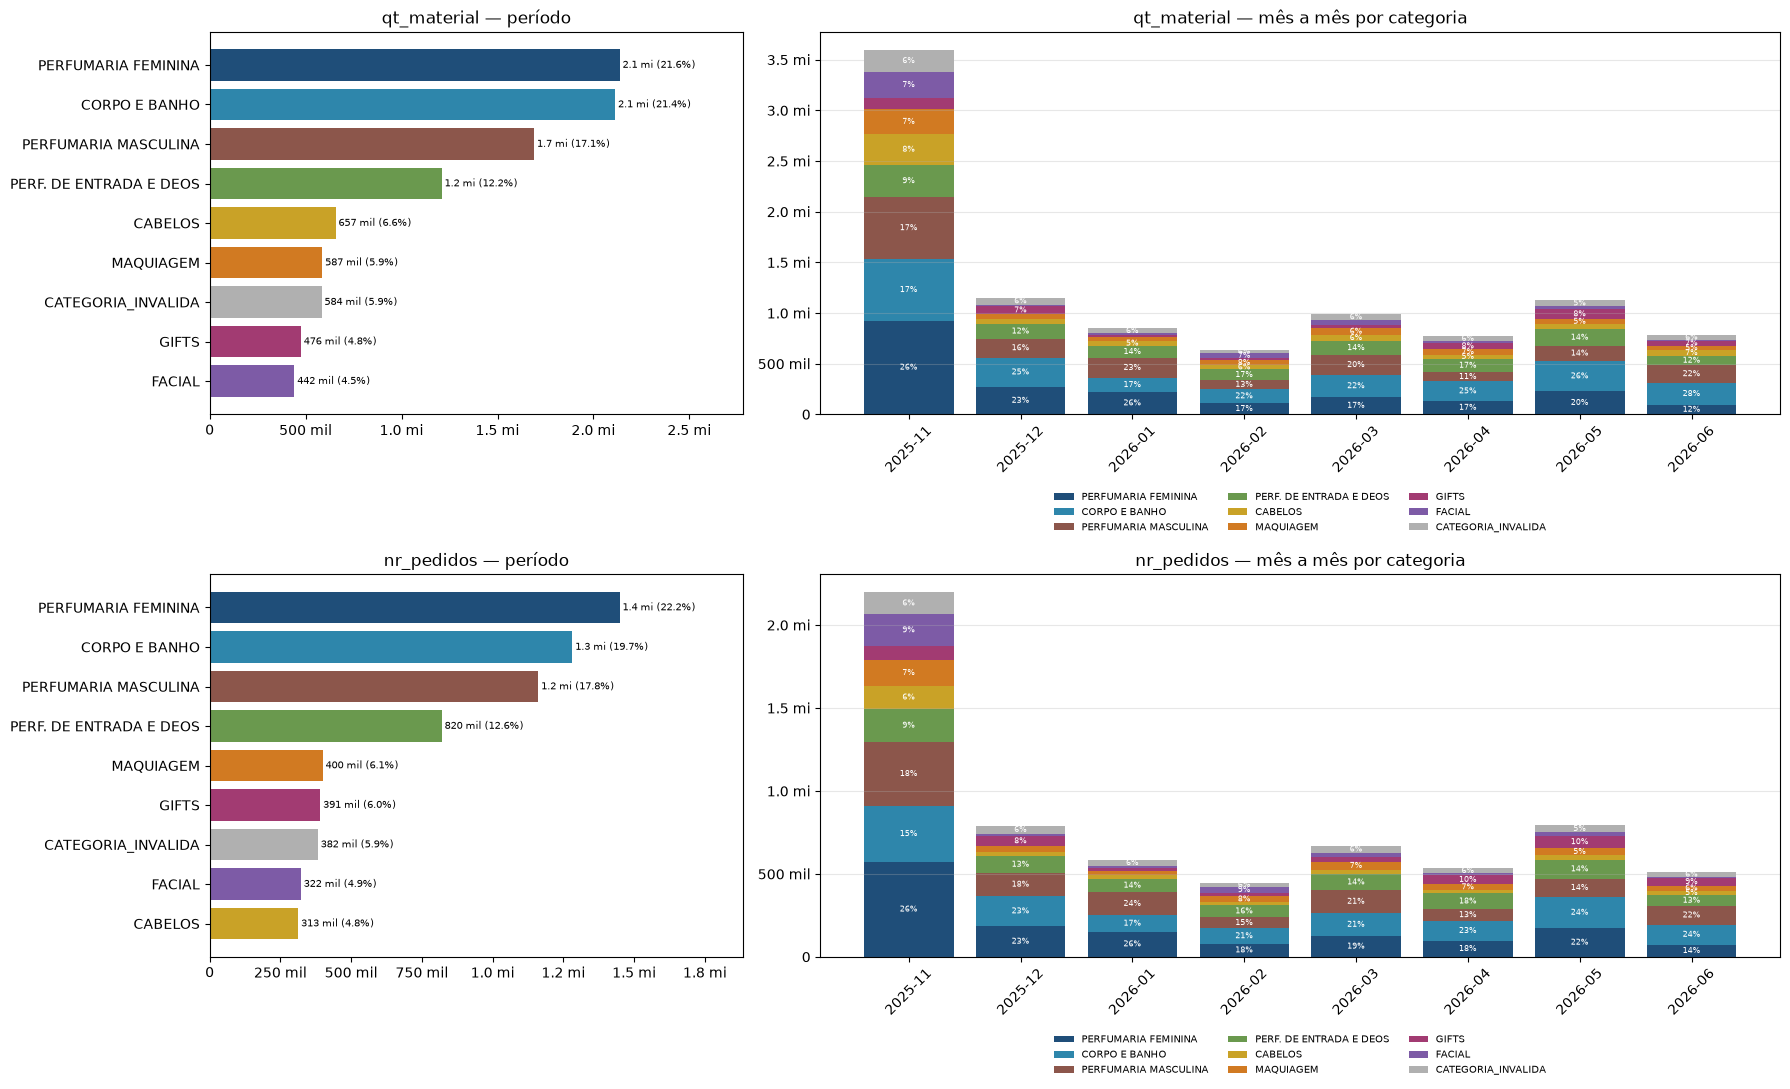

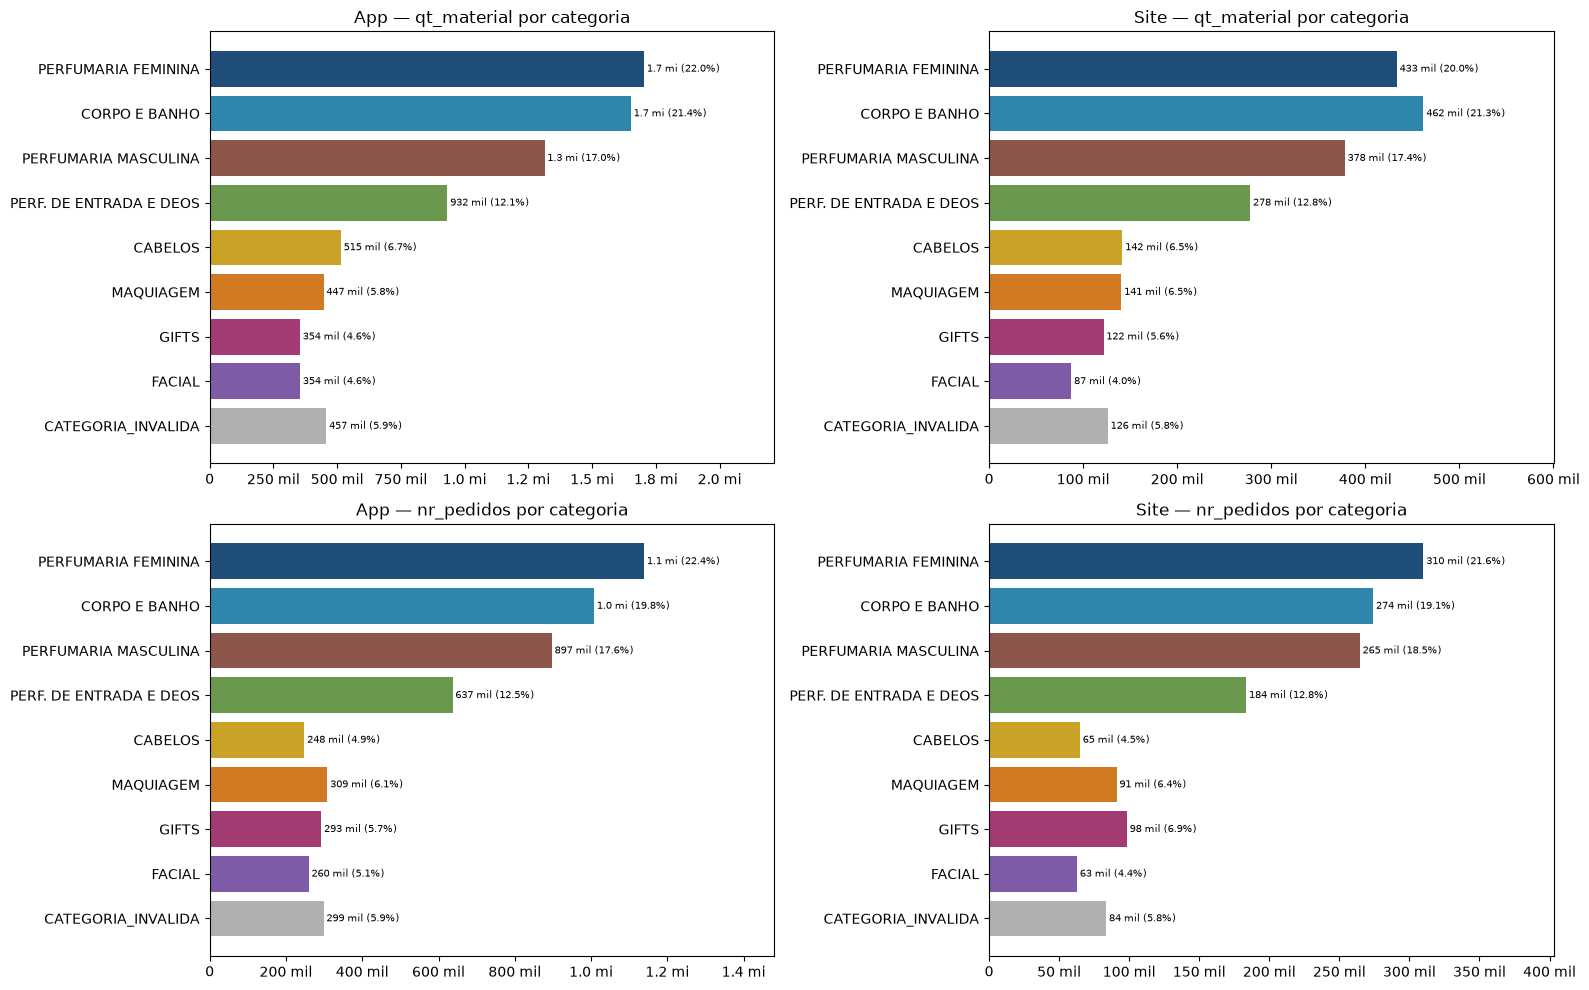

In [7]:
metricas_volume = ["qt_material", "nr_pedidos"]

kpi_geral(metricas_volume)
kpi_linha_do_tempo(metricas_volume)
kpi_por_canal(metricas_volume)
kpi_por_categoria(metricas_volume)
kpi_canal_x_categoria(metricas_volume)

In [8]:
# App x Site têm o mesmo mix? Pareia o share de cada (mês, categoria) nos dois canais
mix_mensal = agregar(
    base_kpi[base_kpi["des_categoria_material"] != "CATEGORIA_INVALIDA"],
    ["mes", "des_canal_venda_final_agrup", "des_categoria_material"],
)
mix_mensal["share_qt_material_mes_canal"] = (
    mix_mensal["qt_material"]
    / mix_mensal.groupby(["mes", "des_canal_venda_final_agrup"])["qt_material"].transform("sum")
)
mix_canal = (
    mix_mensal
    .pivot_table(index=["mes", "des_categoria_material"], columns="des_canal_venda_final_agrup",
                 values="share_qt_material_mes_canal")
    .dropna()
    * 100
)

# Nível: mesma composição? | Movimento: removida a média de cada categoria, as variações andam juntas?
corr_nivel = mix_canal["App"].corr(mix_canal["Site"])
desvio = mix_canal - mix_canal.groupby(level="des_categoria_material").transform("mean")
corr_movimento = desvio["App"].corr(desvio["Site"])

display(pd.DataFrame({
    "medida": [
        "Correlação dos shares (nível)",
        "Correlação das variações mensais (movimento)",
        "Diferença média absoluta (p.p.)",
        "Pares mês × categoria comparados",
    ],
    "valor": [
        round(corr_nivel, 3),
        round(corr_movimento, 3),
        round((mix_canal["App"] - mix_canal["Site"]).abs().mean(), 2),
        len(mix_canal),
    ],
}))

,medida,valor
0,Correlação dos shares (nível),0.9830
1,Correlação das variações mensais (movimento),0.9280
2,Diferença média absoluta (p.p.),1.2100
3,Pares mês × categoria comparados,64.0000


#### Insights — `qt_material` e `nr_pedidos`

- **Volume:** 9,9 mi de itens em 6,5 mi de pedidos no período (~1,5 item por pedido).
- **Novembro concentra 36% dos itens do período** (3,6 mi; ~120 mil/dia contra 23–37 mil/dia nos demais meses). Depois da Black Friday a série tem picos em **dezembro** (Natal), **março** e **maio** (Dia das Mães) e vales em fevereiro, abril e junho. Na Black Friday a cesta também cresce (1,64 item/pedido contra ~1,42–1,53).
- **Canal:** o App responde por **78%** de itens e de pedidos, e a participação cresce ao longo do período (74% em dezembro → 81% em junho). Dezembro é o único mês em que o Site ganha espaço.
- **Categoria:** PERFUMARIA FEMININA e CORPO E BANHO lideram (~21% dos itens cada). As categorias diferem no tamanho da cesta: **CABELOS** tem 6,6% dos itens mas 4,8% dos pedidos (**2,1 itens por pedido**), e **GIFTS** o inverso (4,8% dos itens, 6,0% dos pedidos, 1,2 item por pedido). A categoria inválida representa 5,9%.
- **Mix ao longo do tempo:** CORPO E BANHO ganha participação e PERFUMARIA FEMININA perde (de ~26% dos itens em novembro para ~12% em junho).
- **App × Site:** os dois canais vendem o mesmo mix (correlação dos shares de 0,98; das variações mensais, 0,93). O canal muda o volume, não o que se compra — não é preciso modelar o mix por canal.

## 1.2 `receita_aprovada`

Receita **líquida** (já com desconto aplicado; ver verificação na 1.4). Mesmo roteiro da 1.1.

,kpi,total_periodo
0,receita_aprovada,R$ 490.3 mi


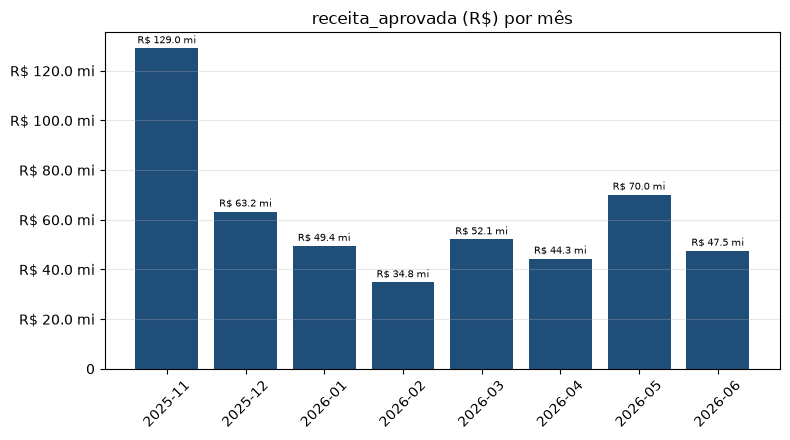

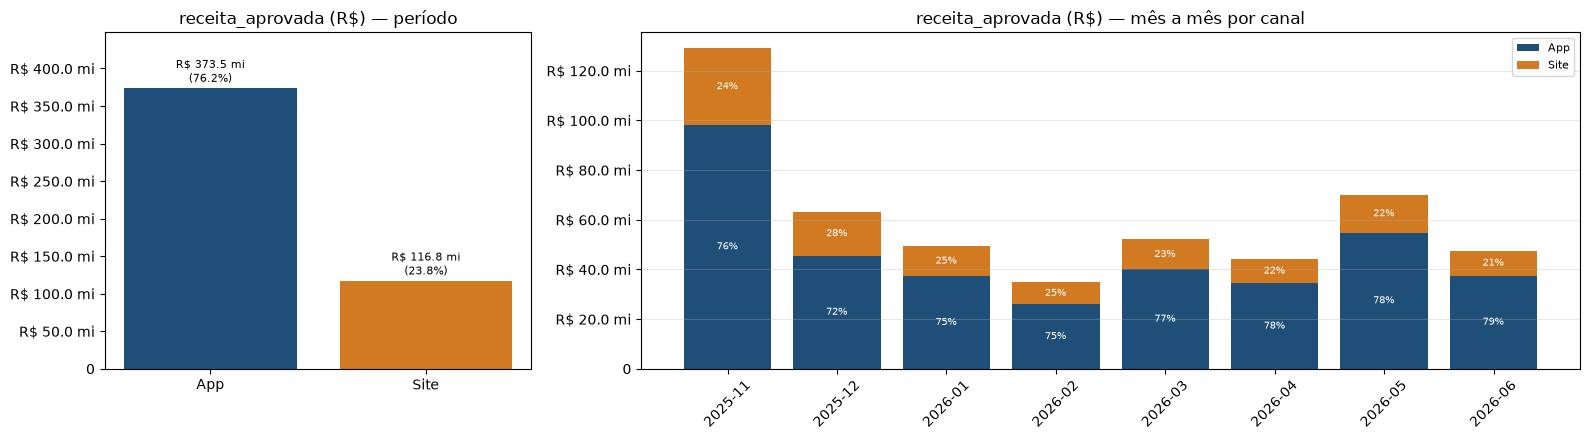

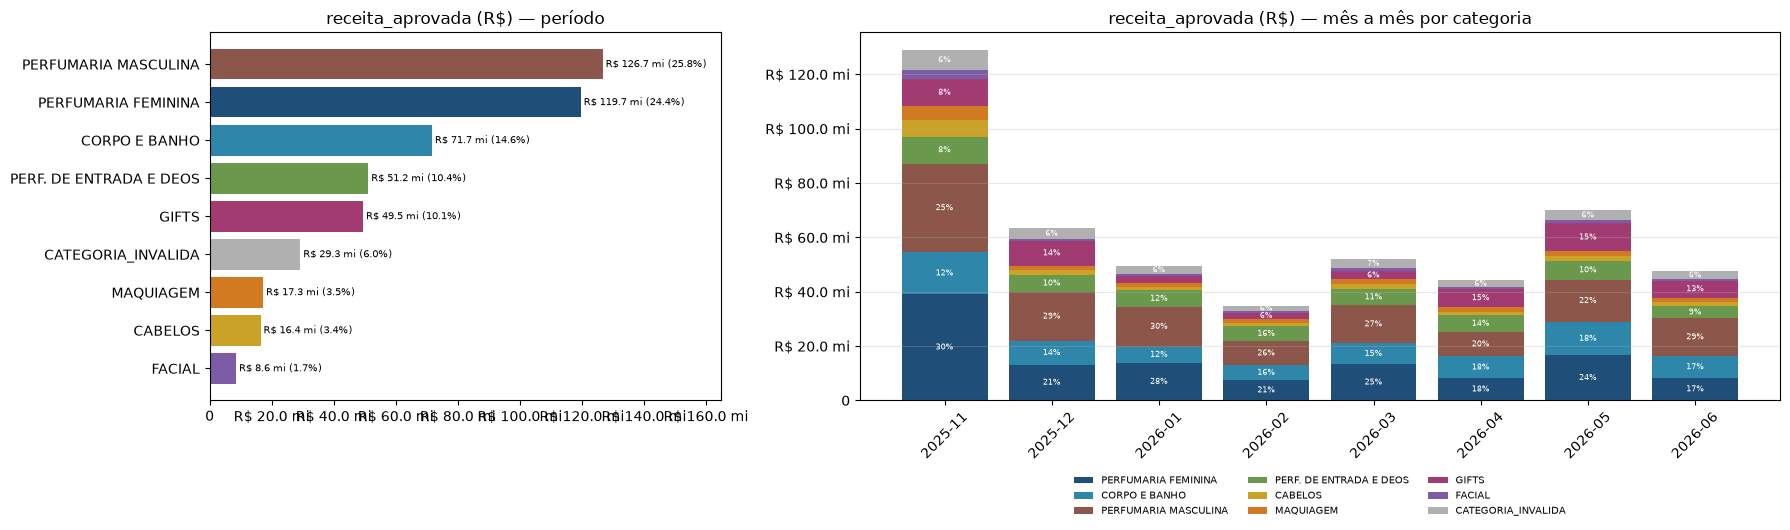

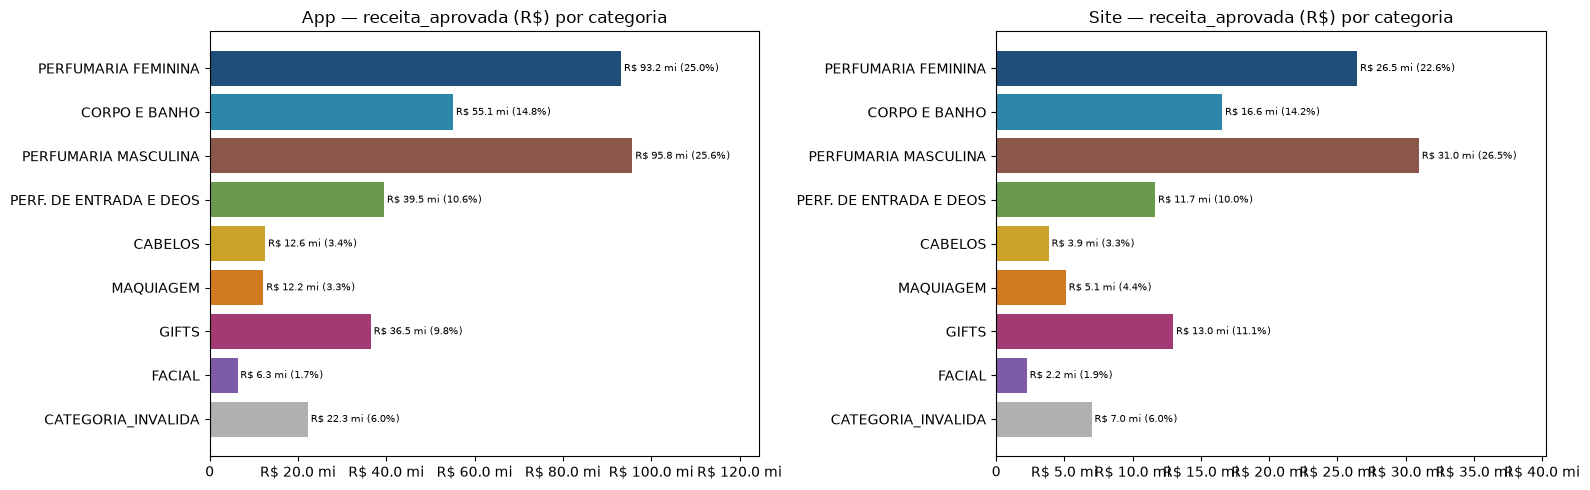

In [9]:
metricas_receita = ["receita_aprovada"]

kpi_geral(metricas_receita)
kpi_linha_do_tempo(metricas_receita)
kpi_por_canal(metricas_receita)
kpi_por_categoria(metricas_receita)
kpi_canal_x_categoria(metricas_receita)

#### Insights — `receita_aprovada`

- **R$ 490 mi** de receita líquida no período. Este total inclui as linhas com receita negativa, que são erro de sinal (seção 2.4); com o sinal corrigido, o total sobe ~8,6%.
- **Novembro concentra 26% da receita**, bem menos que os 36% dos itens: na Black Friday vende-se muito mais, porém mais barato. Fora novembro, a receita acompanha os picos de volume (dezembro e maio).
- **Canal:** o App tem 76% da receita, um pouco abaixo dos 78% dos itens, porque o Site vende mais caro (1.3). A participação do App na receita também cresce (72% em dezembro → 79% em junho).
- **Categoria — receita ≠ volume:** PERFUMARIA MASCULINA lidera a receita (**26%**) sendo só a 3ª em itens (17%); PERFUMARIA FEMININA vem logo atrás (24%). CORPO E BANHO tem 21% dos itens, mas só 15% da receita. **GIFTS dobra de peso** (5% dos itens → 10% da receita). CABELOS, MAQUIAGEM e FACIAL somam menos de 9% da receita.
- **Datas comerciais aparecem na receita por categoria:** GIFTS sai de ~R$ 2 mi/mês em janeiro–fevereiro para R$ 9 mi em dezembro e R$ 10 mi em maio; fora novembro, PERFUMARIA FEMININA tem o maior mês em maio (Dia das Mães) e PERFUMARIA MASCULINA em dezembro e junho (Natal e Dia dos Namorados).

## 1.3 Preço médio = `receita_aprovada` / `nr_pedidos`

Receita líquida média por pedido, sempre calculada como **soma da receita ÷ soma dos pedidos** em cada recorte (média ponderada). Mesmo roteiro da 1.1.

,kpi,total_periodo
0,preco_medio,R$ 75.19


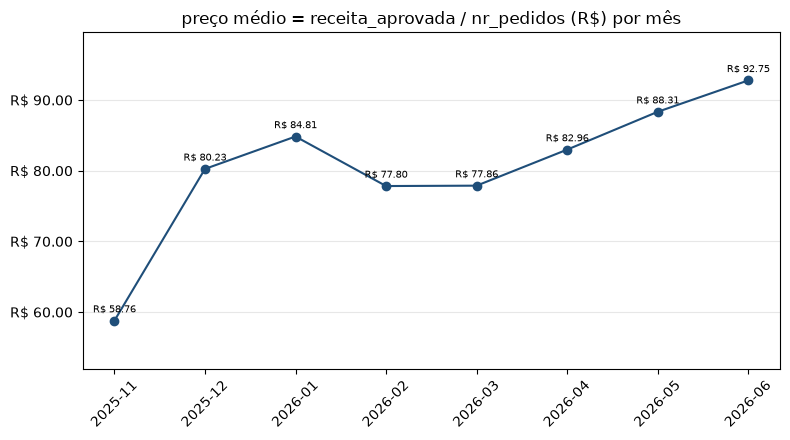

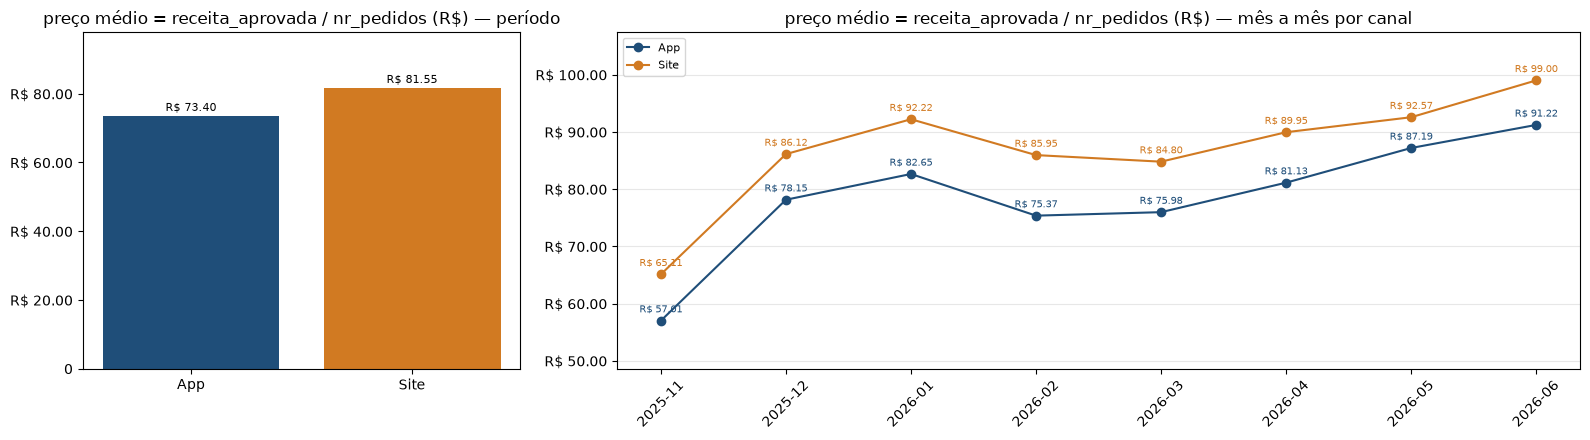

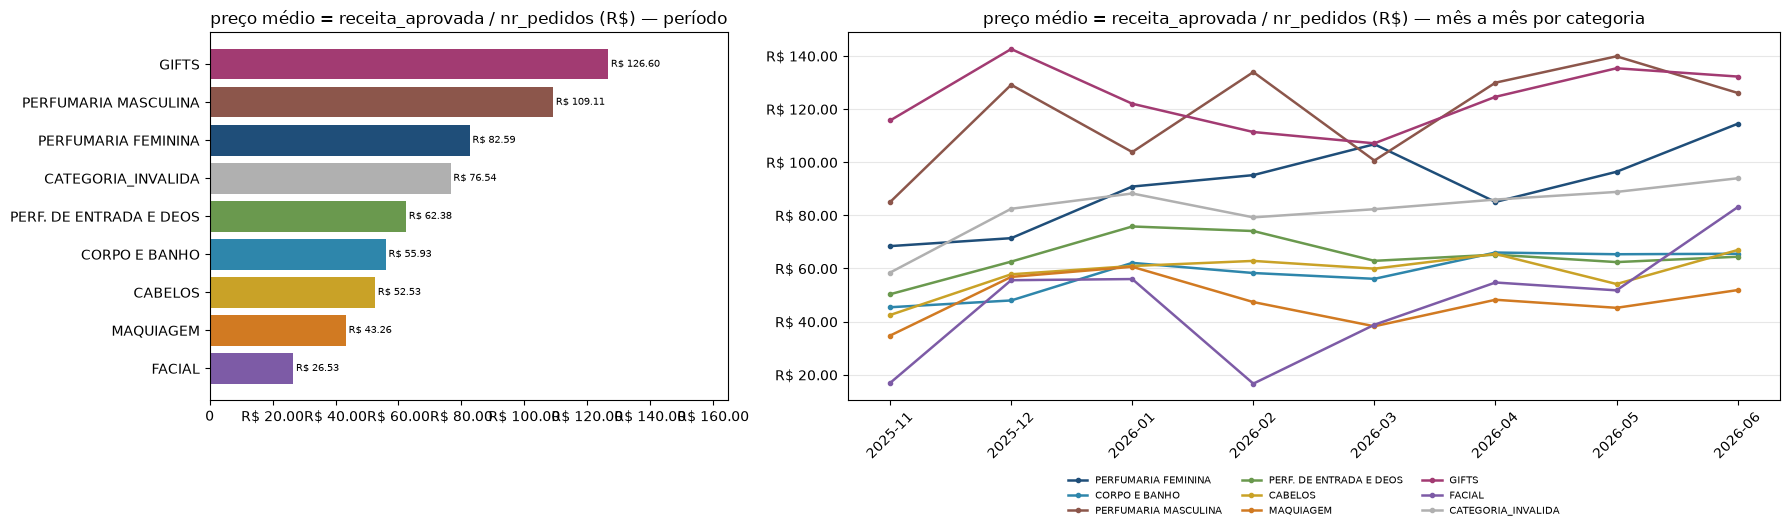

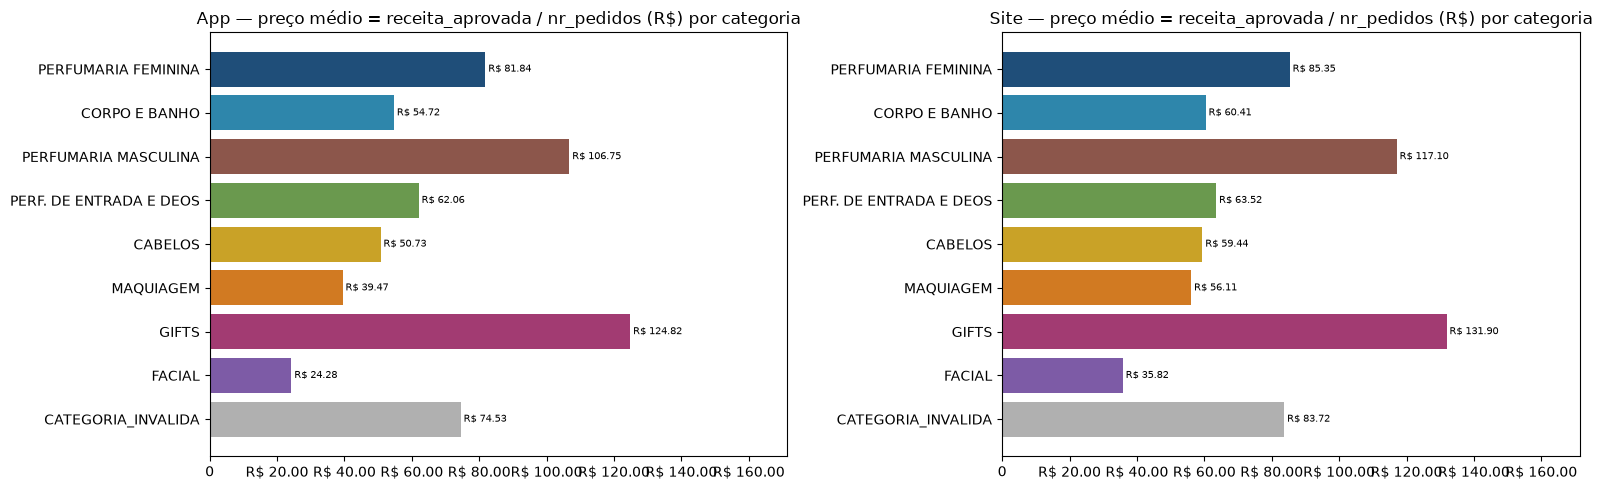

In [10]:
metricas_preco = ["preco_medio"]

kpi_geral(metricas_preco)
kpi_linha_do_tempo(metricas_preco)
kpi_por_canal(metricas_preco)
kpi_por_categoria(metricas_preco)
kpi_canal_x_categoria(metricas_preco)

#### Insights — preço médio

- **R$ 75,19 por pedido** no período.
- **Novembro tem o menor preço (R$ 58,76)** — efeito dos descontos da Black Friday — salta para ~R$ 80–85 em dezembro–janeiro, recua em fevereiro–março (~R$ 78) e depois **sobe todos os meses até R$ 92,75 em junho** (+58% sobre novembro; +19% de março para junho).
- **Site é mais caro que o App em todos os meses** (R$ 81,55 × R$ 73,40 no período, +11%).
- **Categoria:** GIFTS (R$ 127) e PERFUMARIA MASCULINA (R$ 109) têm os pedidos mais caros; FACIAL o mais barato (R$ 27). FACIAL é também o mais instável mês a mês (de ~R$ 17 a ~R$ 56), acompanhando a taxa de desconto (1.4).
- **App × Site por categoria:** o Site é mais caro em todas as categorias. As maiores diferenças são **FACIAL (+48%)** e **MAQUIAGEM (+42%)**; PERF. DE ENTRADA E DEOS praticamente não muda (+2%). Essas diferenças acompanham a diferença de desconto entre canais (1.4).

## 1.4 Desconto

Primeiro confirmamos como receita e desconto se relacionam; depois seguimos o mesmo roteiro da 1.1 com a **taxa de desconto** = `vlr_venda_desconto / (receita_aprovada + vlr_venda_desconto)`.

### A `receita_aprovada` já vem com o desconto aplicado?

A descrição do case diz apenas "receita gerada na venda". Antes de analisar desconto, precisamos saber como as duas colunas se relacionam:

- **Hipótese A (receita líquida):** `receita_aprovada` é o que o cliente pagou, já com desconto. Preço cheio = `receita_aprovada + vlr_venda_desconto`.
- **Hipótese B (receita bruta):** `receita_aprovada` é o preço cheio. Valor pago = `receita_aprovada - vlr_venda_desconto`.

Foi testado as duas com três verificações. Só considerado linhas com receita ≥ 0.

In [11]:
sql_revenue_semantics = f"""
SELECT
  COUNTIF(receita_aprovada > 0) AS linhas_receita_positiva,

  -- 1) Em B, desconto > receita significaria venda líquida negativa
  COUNTIF(receita_aprovada > 0 AND vlr_venda_desconto > receita_aprovada) AS linhas_desconto_maior_que_receita,

  -- 2) Linhas com receita zero e desconto positivo: em A é item 100% gratuito (brinde)
  COUNTIF(receita_aprovada = 0) AS linhas_receita_zero,
  COUNTIF(receita_aprovada = 0 AND vlr_venda_desconto > 0) AS linhas_receita_zero_com_desconto,

  -- 3) Taxa de desconto por linha em cada hipótese
  APPROX_QUANTILES(SAFE_DIVIDE(vlr_venda_desconto, receita_aprovada + vlr_venda_desconto), 100)[OFFSET(50)] AS taxa_mediana_hipotese_a,
  MAX(SAFE_DIVIDE(vlr_venda_desconto, receita_aprovada + vlr_venda_desconto)) AS taxa_maxima_hipotese_a,
  APPROX_QUANTILES(IF(receita_aprovada > 0, SAFE_DIVIDE(vlr_venda_desconto, receita_aprovada), NULL), 100)[OFFSET(50)] AS taxa_mediana_hipotese_b,
  APPROX_QUANTILES(IF(receita_aprovada > 0, SAFE_DIVIDE(vlr_venda_desconto, receita_aprovada), NULL), 100)[OFFSET(95)] AS taxa_p95_hipotese_b
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND receita_aprovada >= 0
"""

revenue_semantics = run_bq(sql_revenue_semantics, "semântica receita x desconto")
display(revenue_semantics.T.rename(columns={0: "valor"}))

sql_price_hypotheses = f"""
SELECT
  des_categoria_material,
  SAFE_DIVIDE(SUM(receita_aprovada), SUM(qt_material)) AS a_pago_por_item,
  SAFE_DIVIDE(SUM(receita_aprovada + vlr_venda_desconto), SUM(qt_material)) AS a_preco_cheio_por_item,
  SAFE_DIVIDE(SUM(receita_aprovada - vlr_venda_desconto), SUM(qt_material)) AS b_pago_por_item,
  SAFE_DIVIDE(SUM(receita_aprovada), SUM(qt_material)) AS b_preco_cheio_por_item
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND receita_aprovada >= 0
  AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
GROUP BY 1
ORDER BY a_pago_por_item
"""

price_hypotheses = run_bq(sql_price_hypotheses, "preço por item em cada hipótese")
display(price_hypotheses)

sql_free_items = f"""
SELECT
  des_categoria_material,
  qt_material,
  receita_aprovada,
  vlr_venda_desconto,
  SAFE_DIVIDE(vlr_venda_desconto, qt_material) AS desconto_por_item
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND receita_aprovada = 0
  AND vlr_venda_desconto > 0
  AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
ORDER BY vlr_venda_desconto DESC
LIMIT 5
"""

print("Exemplos de linhas com receita zero e desconto positivo:")
display(run_bq(sql_free_items, "itens com receita zero"))

[BigQuery] semântica receita x desconto | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,valor
linhas_receita_positiva,85155
linhas_desconto_maior_que_receita,11209
linhas_receita_zero,898
linhas_receita_zero_com_desconto,832
taxa_mediana_hipotese_a,0.311491045
taxa_maxima_hipotese_a,1.000000000
taxa_mediana_hipotese_b,0.448939470
taxa_p95_hipotese_b,1.493343592


[BigQuery] preço por item em cada hipótese | estimativa processada: 5.41 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_categoria_material,a_pago_por_item,a_preco_cheio_por_item,b_pago_por_item,b_preco_cheio_por_item
0,FACIAL,21.268851922,57.390447169,-14.852743326,21.268851922
1,CABELOS,27.558972657,46.783890575,8.334054740,27.558972657
2,MAQUIAGEM,32.236542271,56.043611049,8.429473494,32.236542271
3,CORPO E BANHO,36.723121881,61.460892002,11.985351759,36.723121881
4,PERF. DE ENTRADA E DEOS,45.725422821,62.838556068,28.612289573,45.725422821
5,PERFUMARIA FEMININA,61.432020485,118.604989220,4.259051750,61.432020485
6,PERFUMARIA MASCULINA,80.843944752,137.588131461,24.099758043,80.843944752
7,GIFTS,112.916191226,161.566899153,64.265483299,112.916191226


Exemplos de linhas com receita zero e desconto positivo:


[BigQuery] itens com receita zero | estimativa processada: 5.41 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_categoria_material,qt_material,receita_aprovada,vlr_venda_desconto,desconto_por_item
0,FACIAL,27,0E-9,1077.300000000,39.900000000
1,FACIAL,25,0E-9,895.760000000,35.830400000
2,FACIAL,21,0E-9,858.300000000,40.871428571
3,CORPO E BANHO,12,0E-9,778.800000000,64.900000000
4,FACIAL,13,0E-9,518.700000000,39.900000000


**Conclusão: `receita_aprovada` é receita líquida (hipótese A).**

1. **Na hipótese B haveria vendas negativas.** Em ~13% das linhas o desconto é maior que a receita; o valor pago seria negativo, e o preço médio pago por item em FACIAL ficaria abaixo de zero (e PERFUMARIA FEMININA a ~R$ 4). Na hipótese A os preços cheios são plausíveis para o catálogo (perfumaria masculina ~R$ 138, feminina ~R$ 119).
2. **Linhas com receita zero são itens gratuitos.** Elas têm desconto positivo, e o desconto por item tem cara de preço de catálogo (R$ 39,90 em FACIAL, R$ 64,90 em CORPO E BANHO): o item saiu 100% de graça (brinde). Na hipótese B seria um produto de preço zero com desconto, o que é impossível.
3. **A taxa só faz sentido na hipótese A.** Em A a taxa por linha tem mediana de ~31% e nunca passa de 100% (chega a 100% exatamente nos itens gratuitos); em B, 5% das linhas teriam desconto maior que o próprio preço (p95 ~149%).

**Convenção usada daqui em diante:** receita líquida = `receita_aprovada`; receita bruta (preço cheio) = `receita_aprovada + vlr_venda_desconto`; taxa de desconto = `vlr_venda_desconto / (receita_aprovada + vlr_venda_desconto)`. É uma inferência a partir dos dados, a confirmar com o negócio.

### Números gerais do desconto

Antes das relações, o tamanho do desconto na base: quanto foi concedido, a taxa média e em quantas linhas, pedidos e itens ele aparece.

**Atenção ao grão:** a base é agregada por hora × canal × categoria, então não dá para saber se *cada pedido* teve desconto. O que medimos é a parcela dos pedidos/itens que está em **linhas com desconto > 0**.

In [12]:
sql_discount_overview = f"""
SELECT
  CASE
    WHEN vlr_venda_desconto > 0 THEN 'COM_DESCONTO'
    WHEN vlr_venda_desconto = 0 THEN 'SEM_DESCONTO'
    WHEN vlr_venda_desconto < 0 THEN 'DESCONTO_NEGATIVO'
    ELSE 'NULO'
  END AS grupo_desconto,
  COUNT(*) AS linhas,
  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
  CAST(SUM(vlr_venda_desconto) AS FLOAT64) AS vlr_venda_desconto
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY linhas DESC
"""

discount_overview = run_bq(sql_discount_overview, "visão geral do desconto")

for coluna in ["linhas", "nr_pedidos", "qt_material", "receita_aprovada"]:
    discount_overview[f"pct_{coluna}"] = discount_overview[coluna] / discount_overview[coluna].sum()

display(discount_overview[[
    "grupo_desconto", "linhas", "pct_linhas", "nr_pedidos", "pct_nr_pedidos",
    "qt_material", "pct_qt_material", "pct_receita_aprovada",
]])

receita_total = discount_overview["receita_aprovada"].sum()
desconto_total = discount_overview["vlr_venda_desconto"].sum()

display(pd.DataFrame({
    "indicador": [
        "Desconto concedido (R$)",
        "Receita aprovada (R$)",
        "Receita bruta estimada = receita + desconto (R$)",
        "Taxa de desconto global (desconto / receita bruta)",
        "R$ de desconto para cada R$ 1 de receita",
    ],
    "valor": [
        f"{desconto_total:,.0f}",
        f"{receita_total:,.0f}",
        f"{receita_total + desconto_total:,.0f}",
        f"{desconto_total / (receita_total + desconto_total):.1%}",
        f"{desconto_total / receita_total:.2f}",
    ],
}))

[BigQuery] visão geral do desconto | estimativa processada: 4.78 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,grupo_desconto,linhas,pct_linhas,nr_pedidos,pct_nr_pedidos,qt_material,pct_qt_material,pct_receita_aprovada
0,COM_DESCONTO,89153,0.9954,6520422,0.9999,9895547,0.9999,0.9999
1,SEM_DESCONTO,413,0.0046,473,0.0001,654,0.0001,0.0001


,indicador,valor
0,Desconto concedido (R$),"379,767,343"
1,Receita aprovada (R$),"490,309,827"
2,Receita bruta estimada = receita + desconto (R$),"870,077,169"
3,Taxa de desconto global (desconto / receita br...,43.6%
4,R$ de desconto para cada R$ 1 de receita,0.77


**Leitura:** o desconto é **estrutural**, não pontual. **99,5% das linhas** têm desconto e as linhas sem desconto somam só 473 pedidos (~0,01%). Por isso comparar "com × sem desconto" não diz nada: a pergunta útil é sobre a **intensidade** do desconto. No período, foram concedidos ~R$ 380 milhões de desconto para ~R$ 490 milhões de receita: a taxa média é de **~44% sobre a receita bruta**, ou ~R$ 0,77 de desconto para cada R$ 1 de receita aprovada.

### Taxa de desconto: geral, tempo, canal e categoria

,kpi,total_periodo
0,taxa_desconto,43.6%


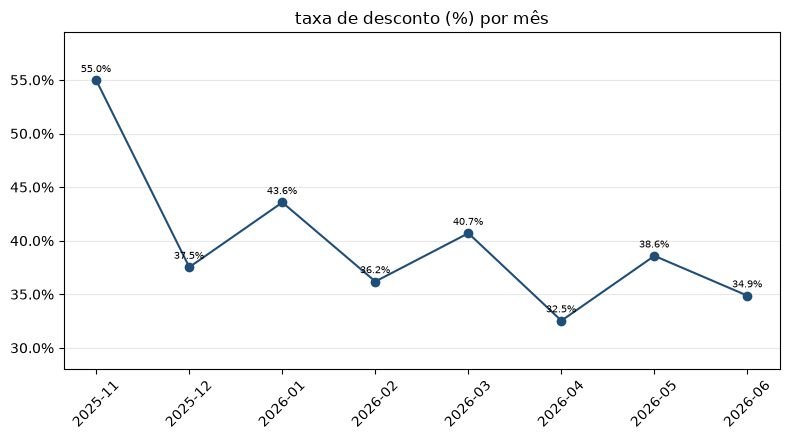

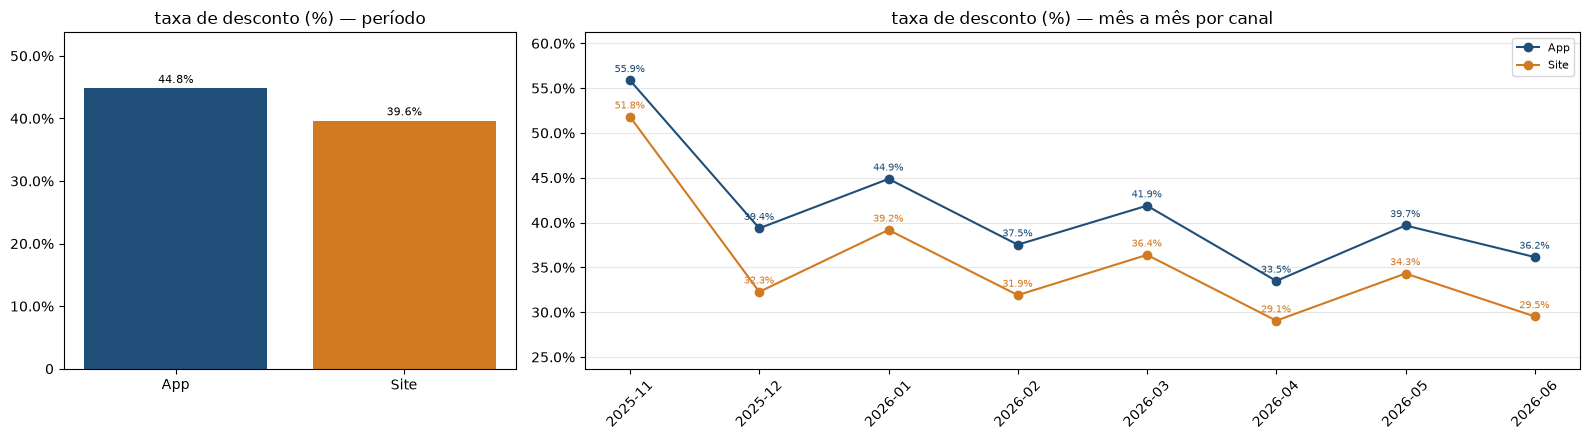

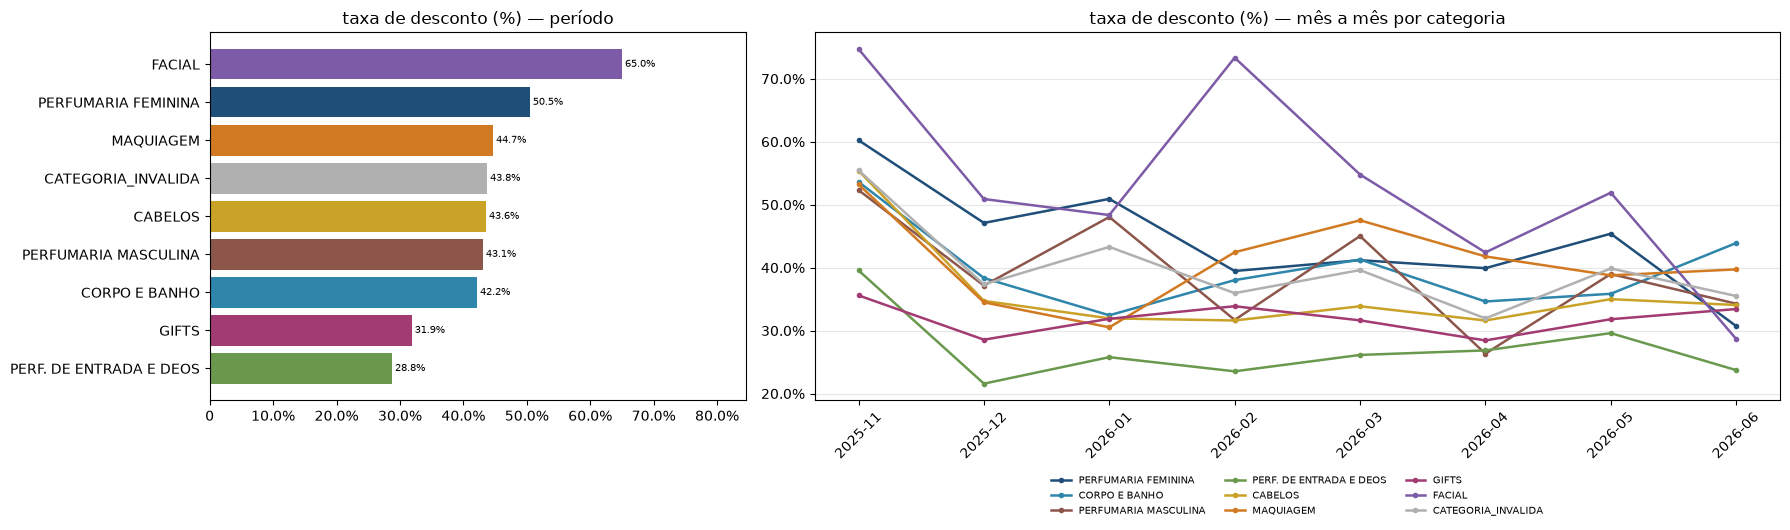

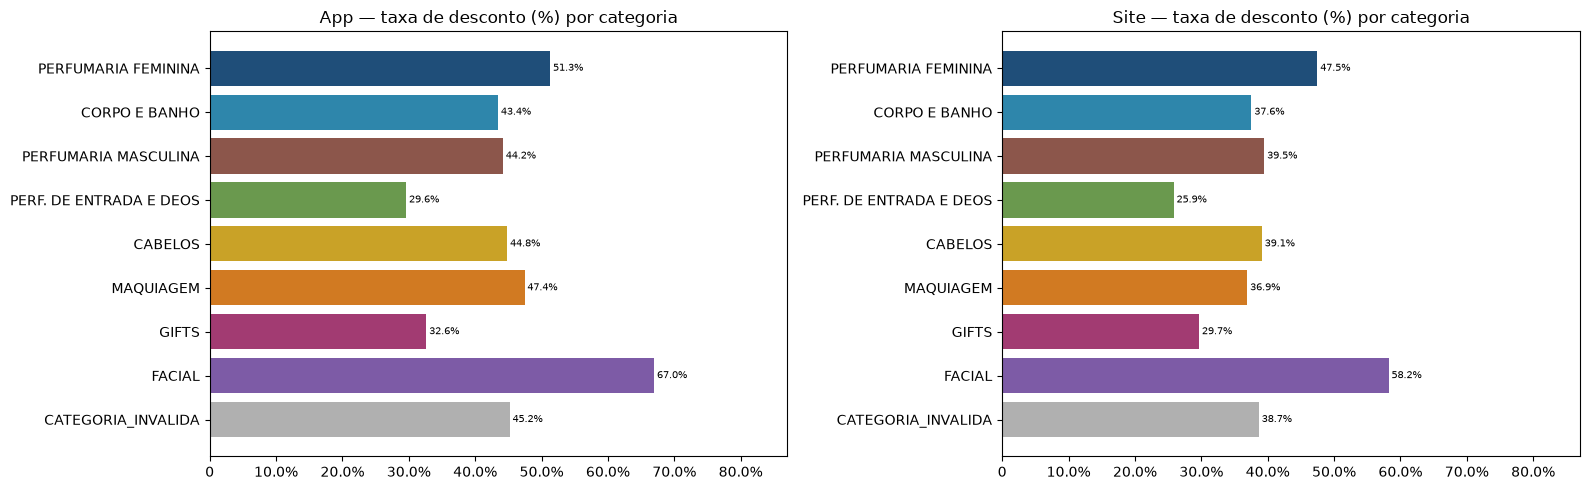

In [13]:
metricas_desconto = ["taxa_desconto"]

kpi_geral(metricas_desconto)
kpi_linha_do_tempo(metricas_desconto)
kpi_por_canal(metricas_desconto)
kpi_por_categoria(metricas_desconto)
kpi_canal_x_categoria(metricas_desconto)

### Implicação para o modelo

A **taxa de desconto realizada do próprio dia** não pode ser usada para prever esse mesmo dia, pois causaria leakage.

Por outro lado, se a empresa tiver um **plano promocional conhecido antecipadamente** — percentual planejado, campanha ou faixa de desconto — essa informação seria uma excelente feature exógena para o forecast.

#### Insights — desconto

- `receita_aprovada` já é **líquida** de desconto; a taxa de desconto é `vlr_venda_desconto / (receita_aprovada + vlr_venda_desconto)`.
- **Taxa global de 43,6%**, com desconto em 99,5% das linhas: o desconto é estrutural, não pontual.
- **Novembro tem a maior taxa (55%)**; nos demais meses ela fica entre 32% e 44%.
- **O App dá mais desconto que o Site em todos os meses** (44,8% × 39,6% no período, 4–7 p.p. de diferença por mês) e **em todas as categorias**. Isso explica boa parte do preço menor do App (1.3): as maiores diferenças de desconto (MAQUIAGEM 47% × 37%; FACIAL 67% × 58%) são as mesmas das maiores diferenças de preço.
- **Categoria:** FACIAL tem a maior taxa (**65%**, chegando a ~75% em novembro e fevereiro) e PERFUMARIA FEMININA 50%; as menores são PERF. DE ENTRADA E DEOS (29%) e GIFTS (32%), as categorias de preço mais estável.

## 1.5 Potencial de vendas por dia da semana

Comparamos **média e mediana**. A mediana reduz o efeito de datas promocionais extremas.

[BigQuery] potencial por dia da semana | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,dia_semana_num,dia_semana,dias,qt_material_media,qt_material_mediana,nr_pedidos_media,receita_aprovada_media,indice_potencial_qt_material
0,0,Segunda,35,"38,128.5143",27942,"25,287.5143","2,028,103.1451",0.9661
1,1,Terça,35,"43,206.2286",29995,"28,499.8571","2,162,365.5077",1.0371
2,2,Quarta,34,"43,115.3824",32567,"28,577.7353","2,104,828.8132",1.1261
3,3,Quinta,34,"45,675.0000",31463,"29,581.8824","2,104,095.3259",1.0879
4,4,Sexta,34,"51,330.9412",29553,"33,310.1471","2,371,419.2085",1.0219
5,5,Sábado,35,"36,921.7143",27265,"24,737.4571","1,892,664.8180",0.9427
6,6,Domingo,35,"28,374.2857",22781,"18,930.1143","1,533,385.1806",0.7877


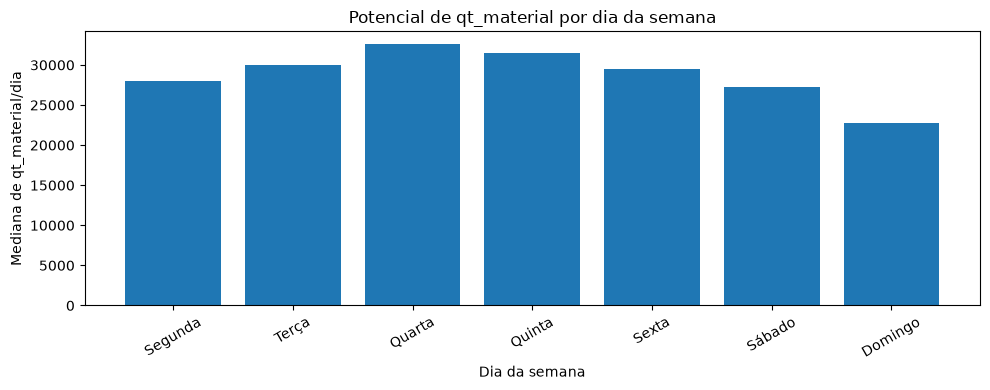

In [14]:
sql_weekday = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 0
      WHEN 3 THEN 1
      WHEN 4 THEN 2
      WHEN 5 THEN 3
      WHEN 6 THEN 4
      WHEN 7 THEN 5
      WHEN 1 THEN 6
    END AS dia_semana_num,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 'Segunda'
      WHEN 3 THEN 'Terça'
      WHEN 4 THEN 'Quarta'
      WHEN 5 THEN 'Quinta'
      WHEN 6 THEN 'Sexta'
      WHEN 7 THEN 'Sábado'
      WHEN 1 THEN 'Domingo'
    END AS dia_semana,

    SUM(qt_material) AS qt_material,
    SUM(nr_pedidos) AS nr_pedidos,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3
),
global AS (
  SELECT
    APPROX_QUANTILES(qt_material, 100)[OFFSET(50)] AS mediana_global_qt_material
  FROM daily
)
SELECT
  d.dia_semana_num,
  d.dia_semana,
  COUNT(*) AS dias,
  AVG(d.qt_material) AS qt_material_media,
  APPROX_QUANTILES(d.qt_material, 100)[OFFSET(50)] AS qt_material_mediana,
  AVG(d.nr_pedidos) AS nr_pedidos_media,
  AVG(d.receita_aprovada) AS receita_aprovada_media,
  SAFE_DIVIDE(
    APPROX_QUANTILES(d.qt_material, 100)[OFFSET(50)],
    g.mediana_global_qt_material
  ) AS indice_potencial_qt_material
FROM daily d
CROSS JOIN global g
GROUP BY 1, 2, g.mediana_global_qt_material
ORDER BY 1
"""

weekday = run_bq(sql_weekday, "potencial por dia da semana")
display(weekday)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(weekday["dia_semana"], weekday["qt_material_mediana"])
ax.set_title("Potencial de qt_material por dia da semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Mediana de qt_material/dia")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

### Qual dia vence em cada semana?

O gráfico anterior compara a distribuição agregada por dia da semana. Agora olhamos **semana a semana** e identificamos qual dia teve mais `qt_material`.

A linha tracejada mostra a **mediana da posição do dia vencedor**. Porém, para responder qual dia vence mais frequentemente, a estatística correta é a **moda/frequência**, mostrada logo depois.

[BigQuery] dia vencedor por semana | estimativa processada: 1.37 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


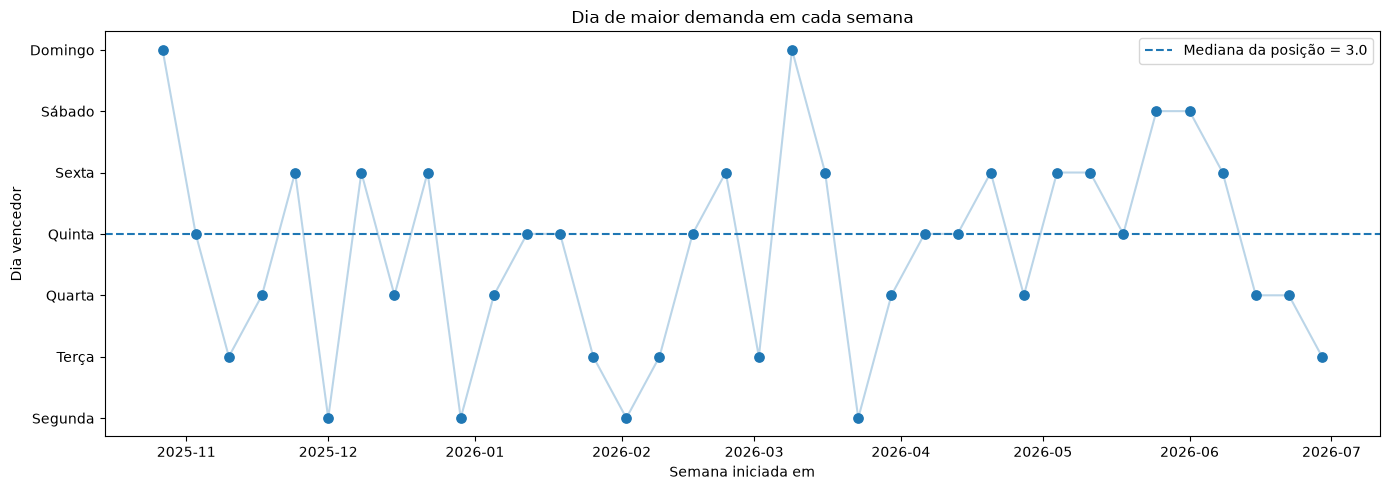

,dia_semana,semanas_vencedoras,pct_semanas
0,Segunda,4,0.1111
1,Terça,5,0.1389
2,Quarta,7,0.1944
3,Quinta,7,0.1944
4,Sexta,9,0.2500
5,Sábado,2,0.0556
6,Domingo,2,0.0556


Dia que mais venceu semanas (moda): Sexta


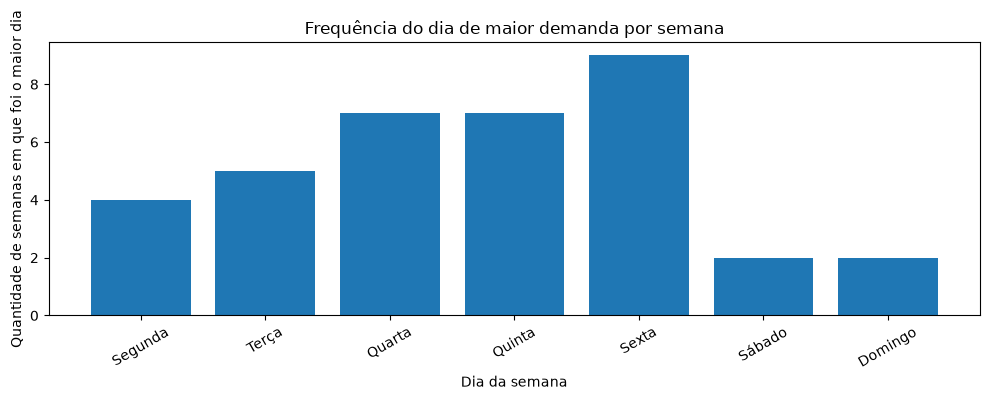

In [15]:
sql_weekly_winners = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    DATE_TRUNC(DATE(dt_hr_venda), WEEK(MONDAY)) AS semana_inicio,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 0
      WHEN 3 THEN 1
      WHEN 4 THEN 2
      WHEN 5 THEN 3
      WHEN 6 THEN 4
      WHEN 7 THEN 5
      WHEN 1 THEN 6
    END AS dia_semana_num,

    CASE EXTRACT(DAYOFWEEK FROM DATE(dt_hr_venda))
      WHEN 2 THEN 'Segunda'
      WHEN 3 THEN 'Terça'
      WHEN 4 THEN 'Quarta'
      WHEN 5 THEN 'Quinta'
      WHEN 6 THEN 'Sexta'
      WHEN 7 THEN 'Sábado'
      WHEN 1 THEN 'Domingo'
    END AS dia_semana,

    SUM(qt_material) AS qt_material

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3, 4
),
ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY semana_inicio
      ORDER BY qt_material DESC, data
    ) AS rn
  FROM daily
)
SELECT
  semana_inicio,
  data,
  dia_semana_num,
  dia_semana,
  qt_material
FROM ranked
WHERE rn = 1
ORDER BY semana_inicio
"""

weekly_winners = run_bq(
    sql_weekly_winners,
    "dia vencedor por semana",
)
weekly_winners["semana_inicio"] = pd.to_datetime(weekly_winners["semana_inicio"])
weekly_winners["data"] = pd.to_datetime(weekly_winners["data"])

weekday_labels = [
    "Segunda",
    "Terça",
    "Quarta",
    "Quinta",
    "Sexta",
    "Sábado",
    "Domingo",
]

median_winner = float(weekly_winners["dia_semana_num"].median())

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    weekly_winners["semana_inicio"],
    weekly_winners["dia_semana_num"],
    s=45,
)
ax.plot(
    weekly_winners["semana_inicio"],
    weekly_winners["dia_semana_num"],
    alpha=0.3,
)
ax.axhline(
    median_winner,
    linestyle="--",
    label=f"Mediana da posição = {median_winner:.1f}",
)
ax.set_yticks(range(7))
ax.set_yticklabels(weekday_labels)
ax.set_title("Dia de maior demanda em cada semana")
ax.set_xlabel("Semana iniciada em")
ax.set_ylabel("Dia vencedor")
ax.legend()
fig.tight_layout()
plt.show()

winner_frequency = (
    weekly_winners["dia_semana"]
    .value_counts()
    .reindex(weekday_labels, fill_value=0)
    .rename_axis("dia_semana")
    .reset_index(name="semanas_vencedoras")
)

winner_frequency["pct_semanas"] = (
    winner_frequency["semanas_vencedoras"]
    / winner_frequency["semanas_vencedoras"].sum()
)

display(winner_frequency)

winner_mode = winner_frequency.loc[
    winner_frequency["semanas_vencedoras"].idxmax(),
    "dia_semana",
]
print(f"Dia que mais venceu semanas (moda): {winner_mode}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    winner_frequency["dia_semana"],
    winner_frequency["semanas_vencedoras"],
)
ax.set_title("Frequência do dia de maior demanda por semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Quantidade de semanas em que foi o maior dia")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

#### Insights — potencial de vendas por dia da semana

- **Dias úteis vendem mais que o fim de semana.** Pela mediana de `qt_material` por dia, **quarta-feira** é o dia mais forte (~32,6 mil itens, 13% acima da mediana geral), seguida de quinta (~31,5 mil) e terça (~30,0 mil).
- **Domingo é o dia mais fraco** (~22,8 mil, 21% abaixo da mediana geral); sábado também fica abaixo (~27,3 mil).
- **Média × mediana:** pela média, sexta-feira aparece como o melhor dia (~51 mil), puxada pela Black Friday (28/11). A mediana, menos sensível a esse pico, mostra que a sexta típica fica na média.
- **Dia vencedor de cada semana:** sexta ganha mais semanas (25%), seguida de quarta e quinta (19% cada); sábado e domingo vencem só 6% das semanas cada.
- **Implicação:** o dia da semana é uma variável relevante para o forecast, com efeito de ~±20% entre o melhor e o pior dia.

## 1.6 Horários — flutuação ao longo do dia

Para evitar que dias de grande volume dominem a análise, calculamos a **participação de cada hora no total de seu próprio dia** e só depois fazemos a média entre os dias.

[BigQuery] perfil intradiário | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,hora,receita_aprovada_media,nr_pedidos_media,qt_material_media,share_receita_aprovada_media,share_qt_material_media
0,0,"42,600.9350",630.1694,"1,002.0248",0.0203,0.0228
1,1,"21,349.3745",331.5248,530.0041,0.0104,0.0124
2,2,"11,390.4952",174.9752,276.4421,0.0056,0.0067
3,3,"7,142.1881",109.4380,174.2975,0.0036,0.0043
4,4,"6,261.4588",94.4339,149.9711,0.0030,0.0036
5,5,"11,069.3015",160.4752,254.1694,0.0051,0.0055
6,6,"26,101.4783",366.7975,569.8347,0.0120,0.0126
7,7,"52,096.9040",705.0165,"1,086.5785",0.0247,0.0249
8,8,"81,325.4243","1,052.8430","1,595.7107",0.0387,0.0377
9,9,"110,460.5357","1,404.4215","2,108.1570",0.0538,0.0519


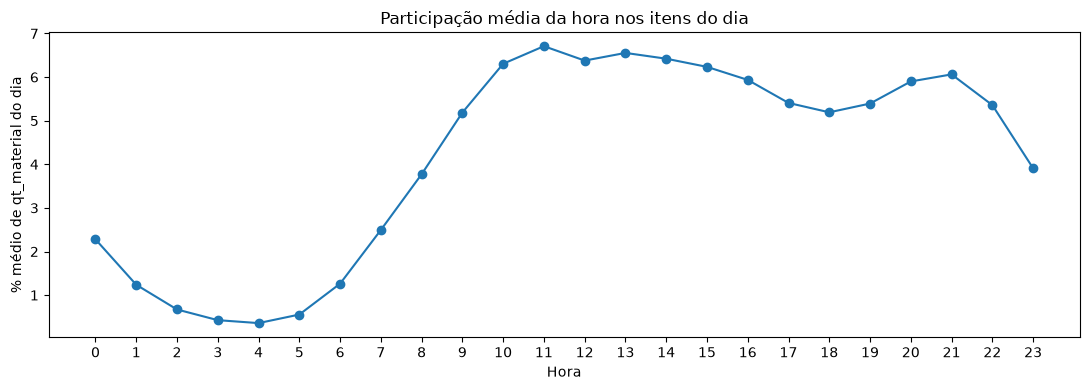

In [16]:
sql_hourly = f"""
WITH hourly_daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    EXTRACT(HOUR FROM dt_hr_venda) AS hora,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
    SUM(nr_pedidos) AS nr_pedidos,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2
),
shares AS (
  SELECT
    *,
    SAFE_DIVIDE(receita_aprovada, SUM(receita_aprovada) OVER (PARTITION BY data)) AS share_receita_aprovada,
    SAFE_DIVIDE(qt_material, SUM(qt_material) OVER (PARTITION BY data)) AS share_qt_material
  FROM hourly_daily
)
SELECT
  hora,
  AVG(receita_aprovada) AS receita_aprovada_media,
  AVG(nr_pedidos) AS nr_pedidos_media,
  AVG(qt_material) AS qt_material_media,
  AVG(share_receita_aprovada) AS share_receita_aprovada_media,
  AVG(share_qt_material) AS share_qt_material_media
FROM shares
GROUP BY 1
ORDER BY 1
"""

hourly = run_bq(sql_hourly, "perfil intradiário")
display(hourly)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly["hora"], hourly["share_qt_material_media"] * 100, marker="o")
ax.set_title("Participação média da hora nos itens do dia")
ax.set_xlabel("Hora")
ax.set_ylabel("% médio de qt_material do dia")
ax.set_xticks(range(24))
fig.tight_layout()
plt.show()

#### Participação por hora — App × Site

Mesma lógica do gráfico acima (participação da hora no total do próprio dia, depois média entre os dias), calculada separadamente para cada canal. Horas sem venda em um dia contam como zero.

[BigQuery] perfil intradiário por canal | estimativa processada: 1.84 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


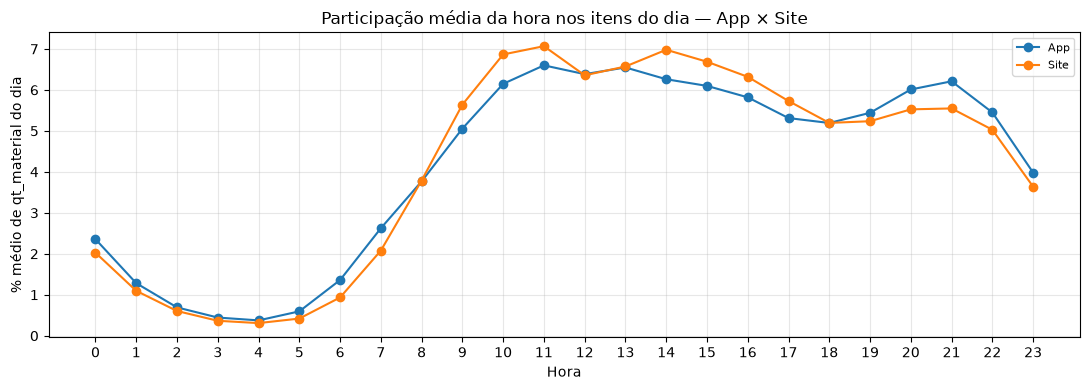

hora,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
des_canal_venda_final_agrup,,,,,,,,,,,,,,,,,,,,,,,,
App,2.3600,1.2800,0.6900,0.4400,0.3700,0.5900,1.3600,2.6200,3.7700,5.0600,6.1500,6.6000,6.3800,6.5500,6.2600,6.1000,5.8200,5.3100,5.1900,5.4400,6.0100,6.2100,5.4500,3.9800
Site,2.0300,1.1000,0.6000,0.3600,0.3100,0.4200,0.9300,2.0800,3.7900,5.6400,6.8700,7.0700,6.3600,6.5700,6.9800,6.6900,6.3200,5.7300,5.1900,5.2400,5.5300,5.5500,5.0300,3.6400


In [17]:
sql_hourly_channel = f"""
WITH base AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    EXTRACT(HOUR FROM dt_hr_venda) AS hora,
    des_canal_venda_final_agrup,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3
),
dia AS (
  SELECT data, des_canal_venda_final_agrup, SUM(qt_material) AS qt_material_dia
  FROM base
  GROUP BY 1, 2
  HAVING SUM(qt_material) > 0
),
n_dias AS (
  SELECT des_canal_venda_final_agrup, COUNT(*) AS n_dias
  FROM dia
  GROUP BY 1
)
SELECT
  b.des_canal_venda_final_agrup,
  b.hora,
  -- soma das participações / nº de dias: horas sem venda entram como zero
  SUM(SAFE_DIVIDE(b.qt_material, d.qt_material_dia)) / ANY_VALUE(n.n_dias) AS share_qt_material_media
FROM base b
JOIN dia d USING (data, des_canal_venda_final_agrup)
JOIN n_dias n USING (des_canal_venda_final_agrup)
GROUP BY 1, 2
ORDER BY 1, 2
"""

hourly_channel = run_bq(sql_hourly_channel, "perfil intradiário por canal")

fig, ax = plt.subplots(figsize=(11, 4))
for canal, grupo in hourly_channel.groupby("des_canal_venda_final_agrup"):
    ax.plot(grupo["hora"], grupo["share_qt_material_media"] * 100, marker="o", label=canal)
ax.set_title("Participação média da hora nos itens do dia — App × Site")
ax.set_xlabel("Hora")
ax.set_ylabel("% médio de qt_material do dia")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(
    hourly_channel
    .pivot(index="hora", columns="des_canal_venda_final_agrup", values="share_qt_material_media")
    .mul(100)
    .round(2)
    .T
)

**Leitura:** os dois canais seguem a mesma curva geral, mas com horários de pico diferentes. O **Site concentra mais vendas no horário comercial** (10h–16h, até ~7% por hora), compatível com compras feitas do computador durante o dia. O **App tem mais peso à noite** (20h–22h e virada da meia-noite) e no início da manhã (6h–7h), compatível com uso do celular fora do horário de trabalho.

#### Participação por hora por categoria — App × Site

Para cada categoria: participação da hora no total **da própria categoria** no dia, média entre os dias. Assim categorias pequenas e grandes ficam na mesma escala e dá para comparar o *formato* da curva.

[BigQuery] perfil intradiário por canal e categoria | estimativa processada: 3.14 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


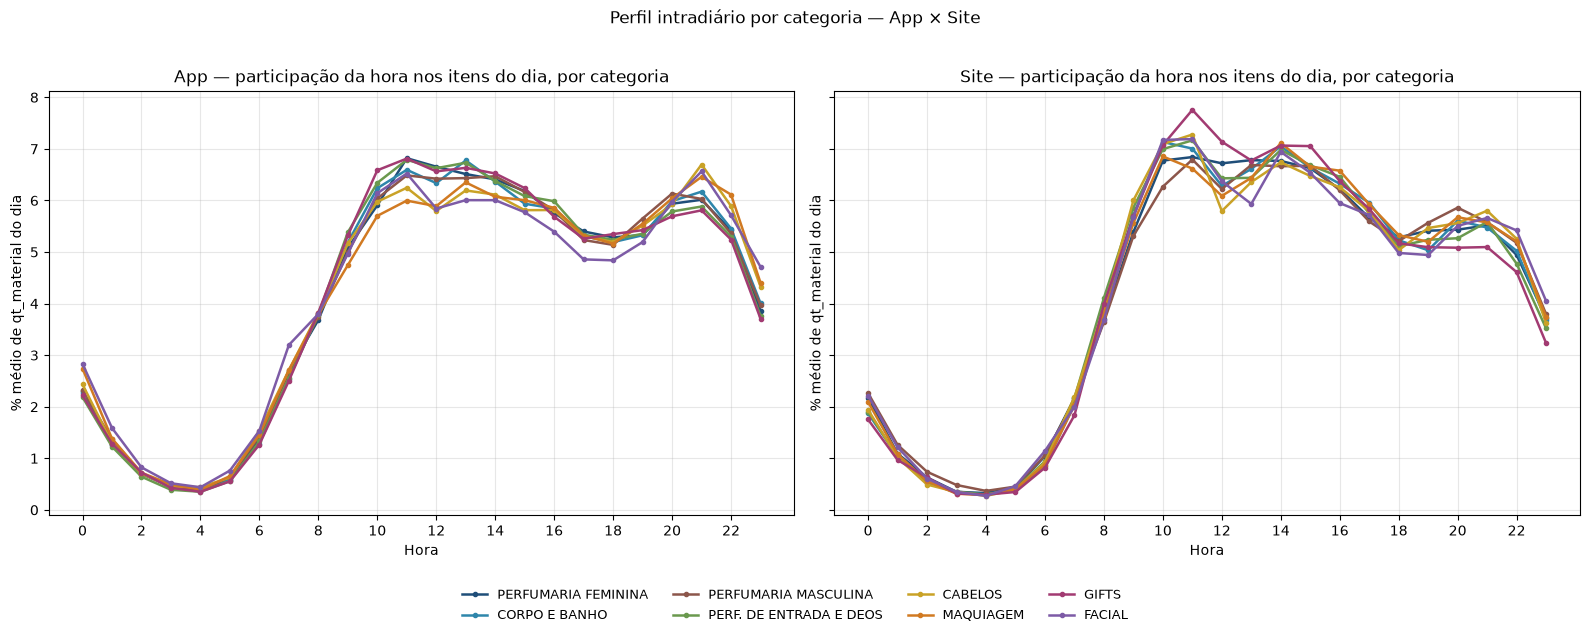

In [18]:
sql_hourly_category = f"""
WITH base AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    EXTRACT(HOUR FROM dt_hr_venda) AS hora,
    des_canal_venda_final_agrup,
    des_categoria_material,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
  GROUP BY 1, 2, 3, 4
),
dia AS (
  SELECT data, des_canal_venda_final_agrup, des_categoria_material, SUM(qt_material) AS qt_material_dia
  FROM base
  GROUP BY 1, 2, 3
  HAVING SUM(qt_material) > 0
),
n_dias AS (
  SELECT des_canal_venda_final_agrup, des_categoria_material, COUNT(*) AS n_dias
  FROM dia
  GROUP BY 1, 2
)
SELECT
  b.des_canal_venda_final_agrup,
  b.des_categoria_material,
  b.hora,
  SUM(SAFE_DIVIDE(b.qt_material, d.qt_material_dia)) / ANY_VALUE(n.n_dias) AS share_qt_material_media
FROM base b
JOIN dia d USING (data, des_canal_venda_final_agrup, des_categoria_material)
JOIN n_dias n USING (des_canal_venda_final_agrup, des_categoria_material)
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
"""

hourly_category = run_bq(sql_hourly_category, "perfil intradiário por canal e categoria")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, canal in zip(axes, ["App", "Site"]):
    perfil = (
        hourly_category[hourly_category["des_canal_venda_final_agrup"] == canal]
        .pivot(index="hora", columns="des_categoria_material", values="share_qt_material_media")
        .reindex(index=range(24), columns=categorias)
        .fillna(0)
        * 100
    )
    for categoria in categorias:
        ax.plot(
            perfil.index, perfil[categoria],
            color=cores[categoria], linewidth=1.8, marker="o", markersize=3,
            label=categoria,
        )

    ax.set_title(f"{canal} — participação da hora nos itens do dia, por categoria")
    ax.set_xlabel("Hora")
    ax.set_ylabel("% médio de qt_material do dia")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Perfil intradiário por categoria — App × Site", y=1.02)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

**Leitura:** todas as categorias têm praticamente o **mesmo formato de curva** dentro de cada canal: madrugada quase zerada, subida a partir das 7h, platô entre 10h e 16h e um segundo pico à noite (mais marcado no App). O que define o perfil horário é o **canal**, não a categoria. Para o planejamento operacional, um perfil horário por canal é suficiente.

#### Insights — horários

- **Madrugada quase parada:** entre 2h e 5h cada hora tem menos de 1% dos itens do dia (mínimo às 4h, ~0,4%).
- **Platô das 10h às 14h** (~6,5% do dia por hora, pico às 11h), leve queda no fim da tarde (~5,2% às 18h) e **um segundo pico às 20h–21h**; a venda só cai de fato depois das 22h.
- **O canal define o horário:** o Site concentra mais no horário comercial (10h–16h, até ~7% por hora); o App tem mais peso à noite (20h–22h e virada da meia-noite) e no começo da manhã (6h–7h).
- **A categoria não muda o formato da curva:** dentro de cada canal, as 8 categorias seguem o mesmo perfil. Para planejamento (estoque, atendimento, campanhas por horário), um perfil horário por canal é suficiente.

# 2. Data Quality — checks executados no BigQuery

## 2.1 Nulos, domínios e valores impossíveis

Avaliando nulos e negativos.

In [19]:
sql_quality = f"""
SELECT
  COUNT(*) AS linhas,

  COUNTIF(dt_hr_venda IS NULL) AS dt_hr_venda_nulos,
  COUNTIF(des_canal_venda_final_agrup IS NULL) AS canal_nulos,
  COUNTIF(des_categoria_material IS NULL) AS categoria_nulos,
  COUNTIF(receita_aprovada IS NULL) AS receita_aprovada_nulos,
  COUNTIF(nr_pedidos IS NULL) AS nr_pedidos_nulos,
  COUNTIF(qt_material IS NULL) AS qt_material_nulos,
  COUNTIF(vlr_venda_desconto IS NULL) AS desconto_nulos,

  COUNTIF(
    des_canal_venda_final_agrup NOT IN ('App', 'Site')
    OR des_canal_venda_final_agrup IS NULL
  ) AS canal_fora_dominio,

  COUNTIF(nr_pedidos <= 0) AS nr_pedidos_nao_positivos,
  COUNTIF(qt_material <= 0) AS qt_material_nao_positivos,

  COUNTIF(receita_aprovada < 0) AS receita_aprovada_negativa,
  COUNTIF(receita_aprovada = 0) AS receita_aprovada_zero

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

quality = run_bq(sql_quality, "data quality geral")
display(quality.T.rename(columns={0: "valor"}))

[BigQuery] data quality geral | estimativa processada: 6.56 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,valor
linhas,89566
dt_hr_venda_nulos,0
canal_nulos,0
categoria_nulos,0
receita_aprovada_nulos,0
nr_pedidos_nulos,0
qt_material_nulos,0
desconto_nulos,0
canal_fora_dominio,0
nr_pedidos_nao_positivos,0


## 2.2 Duplicidade no grão

O grão descrito é **hora × canal × categoria**. Duplicidade nesse nível poderia inflar receita e demanda silenciosamente.

In [20]:
sql_duplicates = f"""
WITH duplicados AS (
  SELECT
    dt_hr_venda,
    des_canal_venda_final_agrup,
    des_categoria_material,
    COUNT(*) AS qtd
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2, 3
  HAVING COUNT(*) > 1
)
SELECT
  COUNT(*) AS grupos_duplicados,
  COALESCE(SUM(qtd - 1), 0) AS linhas_excedentes
FROM duplicados
"""

duplicates = run_bq(sql_duplicates, "duplicidade no grão")
display(duplicates)

[BigQuery] duplicidade no grão | estimativa processada: 2.46 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,grupos_duplicados,linhas_excedentes
0,0,0


## 2.3 Categoria inválida

A coluna deveria conter categorias de produto, mas há registros numéricos entre 0 e 1.

**Decisão:** agrupar como categoria inválida e entender por que esse tipo de erro acontece.

In [21]:
sql_invalid_category = f"""
SELECT
  COUNT(*) AS linhas,
  COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL) AS categorias_invalidas,
  SAFE_DIVIDE(
    COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL),
    COUNT(*)
  ) AS pct_categoria_invalida,
  COUNT(DISTINCT IF(
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL,
    des_categoria_material,
    NULL
  )) AS categorias_validas_distintas
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

invalid_category = run_bq(sql_invalid_category, "categorias inválidas")
display(invalid_category)

[BigQuery] categorias inválidas | estimativa processada: 1.99 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,linhas,categorias_invalidas,pct_categoria_invalida,categorias_validas_distintas
0,89566,5341,0.0596,8


### Exemplos das categorias inválidas

A consulta abaixo materializa os valores mais frequentes classificados como numéricos. O objetivo é tornar visível que o problema não é uma categoria de negócio rara, mas valores incompatíveis com a semântica da coluna.

In [22]:
sql_invalid_category_top10 = f"""
SELECT
  des_categoria_material AS categoria_invalida,
  COUNT(*) AS linhas,
  SUM(qt_material) AS qt_material,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
GROUP BY 1
ORDER BY linhas DESC, categoria_invalida
LIMIT 10
"""

invalid_category_top10 = run_bq(
    sql_invalid_category_top10,
    "top 10 categorias inválidas",
)
display(invalid_category_top10)

[BigQuery] top 10 categorias inválidas | estimativa processada: 4.04 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,categoria_invalida,linhas,qt_material,receita_aprovada
0,0.00024450656789574022,1,31,"-4,669.5300"
1,0.00070443489970792447,1,42,"3,209.9400"
2,0.00095781793118081466,1,24,718.0800
3,0.0010040408688505784,1,33,"1,235.4900"
4,0.001051048726195521,1,1,0.0000
5,0.0011964175250032208,1,26,"1,096.7900"
6,0.0014034942309376366,1,14,507.1000
7,0.0016184701534009858,1,122,"4,964.0900"
8,0.0019208619303319862,1,106,"3,348.5800"
9,0.0021335390609045993,1,110,"3,699.4500"


[BigQuery] categoria inválida por mês | estimativa processada: 1.99 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,mes,linhas,categorias_invalidas,pct_invalida
0,2025-11,11423,678,0.0594
1,2025-12,11577,670,0.0579
2,2026-01,11424,693,0.0607
3,2026-02,10323,609,0.0590
4,2026-03,11488,682,0.0594
5,2026-04,10983,674,0.0614
6,2026-05,11497,702,0.0611
7,2026-06,10851,633,0.0583


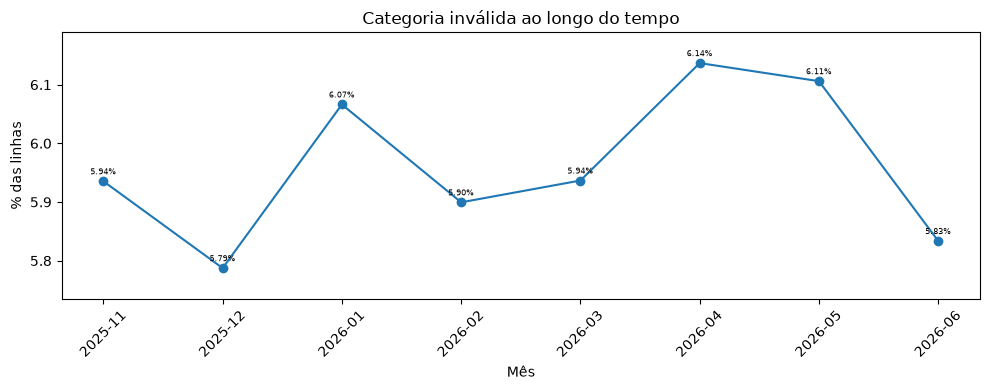

In [23]:
sql_invalid_category_month = f"""
SELECT
  FORMAT_DATE('%Y-%m', DATE(dt_hr_venda)) AS mes,
  COUNT(*) AS linhas,
  COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL) AS categorias_invalidas,
  SAFE_DIVIDE(
    COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL),
    COUNT(*)
  ) AS pct_invalida
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

invalid_category_month = run_bq(
    sql_invalid_category_month,
    "categoria inválida por mês",
)
display(invalid_category_month)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    invalid_category_month["mes"],
    invalid_category_month["pct_invalida"] * 100,
    marker="o",
)
for mes, pct in zip(invalid_category_month["mes"], invalid_category_month["pct_invalida"] * 100):
    ax.annotate(f"{pct:.2f}%", (mes, pct), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=6)
ax.margins(y=0.15)
ax.set_title("Categoria inválida ao longo do tempo")
ax.set_xlabel("Mês")
ax.set_ylabel("% das linhas")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

É um problema estrutural e constante, ficando entre 5,79% e 6,14%.
Sem relação com período específico.

### 2.3.1 A categoria inválida se concentra em App ou Site?

Comparamos a taxa de categoria inválida **dentro de cada canal**, além do share dos registros inválidos.

O `lift_vs_global` ajuda a interpretar:

- `1,00`: mesma incidência da base;
- `> 1,00`: incidência acima da média;
- `< 1,00`: incidência abaixo da média.

[BigQuery] categoria inválida por canal | estimativa processada: 2.46 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_canal_venda_final_agrup,linhas,categorias_invalidas,pct_categoria_invalida,pct_invalida_global,lift_vs_global,share_dos_invalidos
0,App,45936,2758,0.0600,0.0596,1.0068,0.5164
1,Site,43630,2583,0.0592,0.0596,0.9928,0.4836


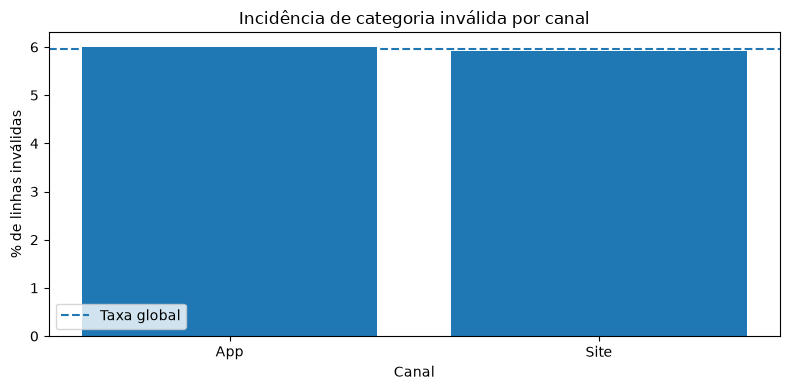

In [24]:
sql_invalid_category_channel = f"""
WITH base AS (
  SELECT
    des_canal_venda_final_agrup,
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
      AS categoria_invalida
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
global_rate AS (
  SELECT
    SAFE_DIVIDE(
      COUNTIF(categoria_invalida),
      COUNT(*)
    ) AS pct_invalida_global
  FROM base
),
by_channel AS (
  SELECT
    des_canal_venda_final_agrup,
    COUNT(*) AS linhas,
    COUNTIF(categoria_invalida) AS categorias_invalidas,
    SAFE_DIVIDE(
      COUNTIF(categoria_invalida),
      COUNT(*)
    ) AS pct_categoria_invalida
  FROM base
  GROUP BY 1
)
SELECT
  b.*,
  g.pct_invalida_global,

  SAFE_DIVIDE(
    b.pct_categoria_invalida,
    g.pct_invalida_global
  ) AS lift_vs_global,

  SAFE_DIVIDE(
    b.categorias_invalidas,
    SUM(b.categorias_invalidas) OVER ()
  ) AS share_dos_invalidos

FROM by_channel b
CROSS JOIN global_rate g
ORDER BY pct_categoria_invalida DESC
"""

invalid_category_channel = run_bq(
    sql_invalid_category_channel,
    "categoria inválida por canal",
)
display(invalid_category_channel)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    invalid_category_channel["des_canal_venda_final_agrup"],
    invalid_category_channel["pct_categoria_invalida"] * 100,
)
ax.axhline(
    invalid_category_channel["pct_invalida_global"].iloc[0] * 100,
    linestyle="--",
    label="Taxa global",
)
ax.set_title("Incidência de categoria inválida por canal")
ax.set_xlabel("Canal")
ax.set_ylabel("% de linhas inválidas")
ax.legend()
fig.tight_layout()
plt.show()

Sem relação com o canal de venda.

### 2.3.2 A concentração muda ao longo dos meses?

A taxa mensal é calculada **dentro de cada canal**. Assim evitamos concluir que um canal tem mais problema apenas porque possui mais volume.

[BigQuery] categoria inválida por mês e canal | estimativa processada: 2.46 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,mes,des_canal_venda_final_agrup,linhas,categorias_invalidas,pct_categoria_invalida
0,2025-11-01,App,5757,366,0.0636
1,2025-11-01,Site,5666,312,0.0551
2,2025-12-01,App,5900,340,0.0576
3,2025-12-01,Site,5677,330,0.0581
4,2026-01-01,App,5868,357,0.0608
5,2026-01-01,Site,5556,336,0.0605
6,2026-02-01,App,5303,321,0.0605
7,2026-02-01,Site,5020,288,0.0574
8,2026-03-01,App,5894,358,0.0607
9,2026-03-01,Site,5594,324,0.0579


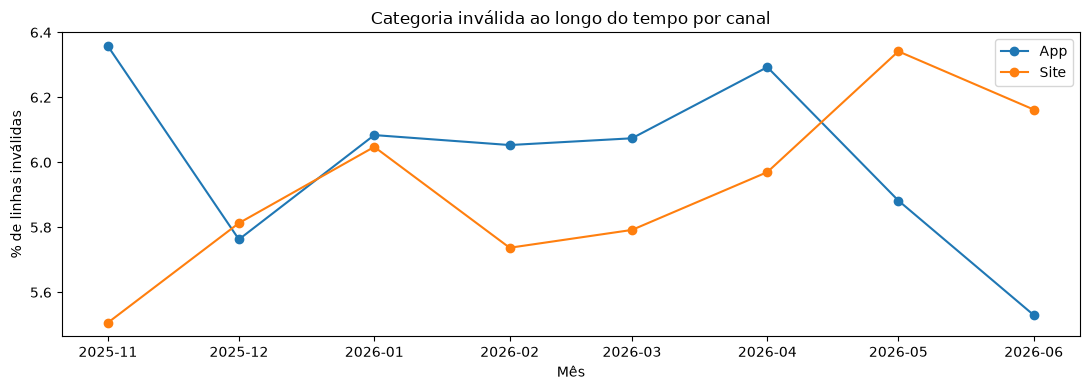

In [25]:
sql_invalid_category_month_channel = f"""
SELECT
  DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
  des_canal_venda_final_agrup,

  COUNT(*) AS linhas,

  COUNTIF(
    SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
  ) AS categorias_invalidas,

  SAFE_DIVIDE(
    COUNTIF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
    ),
    COUNT(*)
  ) AS pct_categoria_invalida

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1, 2
ORDER BY 1, 2
"""

invalid_category_month_channel = run_bq(
    sql_invalid_category_month_channel,
    "categoria inválida por mês e canal",
)
invalid_category_month_channel["mes"] = pd.to_datetime(
    invalid_category_month_channel["mes"]
)

display(invalid_category_month_channel)

fig, ax = plt.subplots(figsize=(11, 4))

for canal, group in invalid_category_month_channel.groupby("des_canal_venda_final_agrup"):
    ax.plot(
        group["mes"],
        group["pct_categoria_invalida"] * 100,
        marker="o",
        label=canal,
    )

ax.set_title("Categoria inválida ao longo do tempo por canal")
ax.set_xlabel("Mês")
ax.set_ylabel("% de linhas inválidas")
ax.legend()
fig.tight_layout()
plt.show()

Sem relação com tempo e canal.

### 2.3.3 Quais valores inválidos aparecem em cada canal?

O que pode-se verificar é se determinados valores inválidos se repetem e se estão concentrados em App ou Site. Isso pode ajudar a localizar a origem do problema no pipeline.

In [26]:
sql_invalid_values_by_channel = f"""
WITH ranked AS (
  SELECT
    des_canal_venda_final_agrup,
    des_categoria_material AS valor_invalido,
    COUNT(*) AS linhas,

    ROW_NUMBER() OVER (
      PARTITION BY des_canal_venda_final_agrup
      ORDER BY COUNT(*) DESC, des_categoria_material
    ) AS rank_canal

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
  GROUP BY 1, 2
)
SELECT
  des_canal_venda_final_agrup,
  rank_canal,
  valor_invalido,
  linhas
FROM ranked
WHERE rank_canal <= 10
ORDER BY des_canal_venda_final_agrup, rank_canal
"""

invalid_values_by_channel = run_bq(
    sql_invalid_values_by_channel,
    "top valores inválidos por canal",
)

display(invalid_values_by_channel)

[BigQuery] top valores inválidos por canal | estimativa processada: 2.46 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_canal_venda_final_agrup,rank_canal,valor_invalido,linhas
0,App,1,0.0010040408688505784,1
1,App,2,0.0019208619303319862,1
2,App,3,0.0021335390609045993,1
3,App,4,0.0022656236553724673,1
4,App,5,0.0027613439178184535,1
5,App,6,0.0028674220578636476,1
6,App,7,0.0038429595049671405,1
7,App,8,0.0045236387712643839,1
8,App,9,0.00465820730362276,1
9,App,10,0.0047259230380081877,1


**Conclusão possível:** ausência de padrão, todos com linhas = 1, e com um valor entre 0 e 1.

### 2.3.4 Existe padrão por hora do dia?

Hora vai de **0 (meia-noite) a 23**. Para cada hora calculamos a **taxa** = linhas com o problema ÷ linhas da hora.

**Como saber se uma diferença é real ou acaso?** Se o problema não depende da hora, cada hora teria a mesma
taxa da base, com uma pequena oscilação aleatória. A **faixa cinza** é essa oscilação esperada (intervalo de
95%: taxa global ± 1,96 × √(p(1−p)/n)). Pontos **vermelhos** ficam fora da faixa.

**Cuidado com comparações múltiplas:** com 24 horas, mesmo sem padrão nenhum espera-se que ~1 hora
(5% de 24) caia fora da faixa por puro acaso. Por isso olhamos também o **teste qui-quadrado**, que avalia as
24 horas de uma vez: p-valor < 0,05 indica que a taxa **varia** com a hora. Um padrão operacional (ex.: carga
ou rotina noturna) apareceria como um **bloco de horas consecutivas** acima da faixa, não como pontos isolados.

[BigQuery] Categoria inválida por hora do dia | estimativa processada: 1.99 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


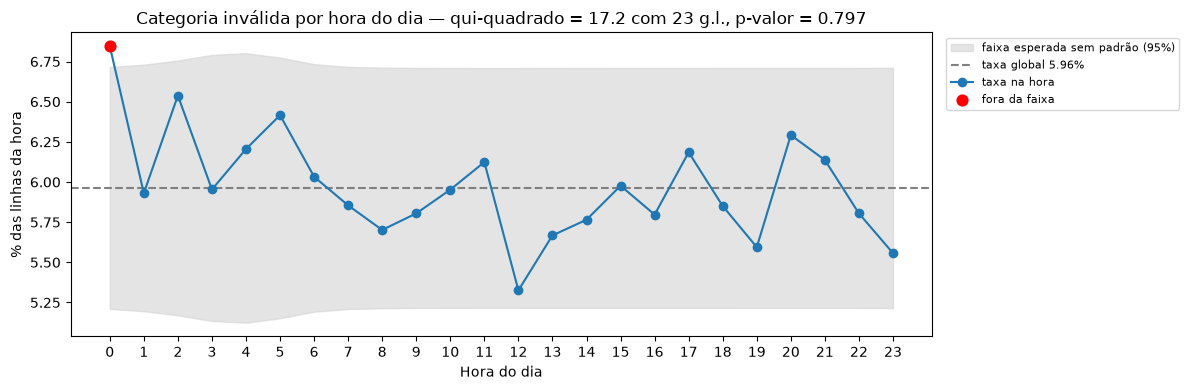

Horas fora da faixa: 1 de 24 (esperado por acaso ≈ 1) -> [0]


,hora,linhas,ocorrencias,taxa,lift_vs_global,fora_da_faixa
0,0,3798,260,0.0685,1.1480,True
1,1,3659,217,0.0593,0.9945,False
2,2,3426,224,0.0654,1.0964,False
3,3,3141,187,0.0595,0.9984,False
4,4,3062,190,0.0621,1.0406,False
5,5,3273,210,0.0642,1.0760,False
6,6,3630,219,0.0603,1.0117,False
7,7,3792,222,0.0585,0.9818,False
8,8,3841,219,0.0570,0.9561,False
9,9,3859,224,0.0580,0.9734,False


In [27]:
def taxa_por_hora(condicao_sql: str, titulo: str) -> pd.DataFrame:
    """Taxa de um problema por hora do dia, faixa de 95% esperada sem padrão e teste qui-quadrado."""
    sql = f"""
    SELECT
      EXTRACT(HOUR FROM dt_hr_venda) AS hora,
      COUNT(*) AS linhas,
      COUNTIF({condicao_sql}) AS ocorrencias
    FROM `{TABLE_ID}`
    WHERE {DATE_FILTER}
    GROUP BY 1
    ORDER BY 1
    """
    tabela = run_bq(sql, titulo)
    taxa_global = tabela["ocorrencias"].sum() / tabela["linhas"].sum()
    tabela["taxa"] = tabela["ocorrencias"] / tabela["linhas"]
    margem = 1.96 * np.sqrt(taxa_global * (1 - taxa_global) / tabela["linhas"])
    tabela["faixa_min"] = taxa_global - margem
    tabela["faixa_max"] = taxa_global + margem
    tabela["fora_da_faixa"] = (tabela["taxa"] < tabela["faixa_min"]) | (tabela["taxa"] > tabela["faixa_max"])
    tabela["lift_vs_global"] = tabela["taxa"] / taxa_global

    # qui-quadrado (tabela 24 horas x [com problema, sem problema])
    esperado = tabela["linhas"] * taxa_global
    qui2 = (((tabela["ocorrencias"] - esperado) ** 2 / esperado)
            + ((tabela["linhas"] - tabela["ocorrencias"] - (tabela["linhas"] - esperado)) ** 2
               / (tabela["linhas"] - esperado))).sum()
    graus = len(tabela) - 1
    try:
        from scipy.stats import chi2
        p_valor = chi2.sf(qui2, graus)
        texto_p = f"p-valor = {p_valor:.3f}"
    except ImportError:
        texto_p = f"(valor crítico a 5% com {graus} g.l. ≈ 35,2)"

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(tabela["hora"], tabela["faixa_min"] * 100, tabela["faixa_max"] * 100,
                    color="lightgray", alpha=0.6, label="faixa esperada sem padrão (95%)")
    ax.axhline(taxa_global * 100, color="gray", linestyle="--", label=f"taxa global {taxa_global:.2%}")
    ax.plot(tabela["hora"], tabela["taxa"] * 100, marker="o", label="taxa na hora")
    fora = tabela[tabela["fora_da_faixa"]]
    ax.scatter(fora["hora"], fora["taxa"] * 100, color="red", zorder=3, s=60, label="fora da faixa")
    ax.set_xticks(range(24))
    ax.set_title(f"{titulo} — qui-quadrado = {qui2:.1f} com {graus} g.l., {texto_p}")
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("% das linhas da hora")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout()
    plt.show()

    print(f"Horas fora da faixa: {int(tabela['fora_da_faixa'].sum())} de 24 "
          f"(esperado por acaso ≈ 1) -> {fora['hora'].tolist()}")
    return tabela


invalid_category_hour = taxa_por_hora(
    "SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL",
    "Categoria inválida por hora do dia",
)
display(invalid_category_hour[["hora", "linhas", "ocorrencias", "taxa", "lift_vs_global", "fora_da_faixa"]])

Inconclusivo

### 2.3.5 É possível recuperar as categorias inválidas?

O número gravado no campo é aleatório (2.3.3) e não diz nada sobre a categoria original. Mas o **grão da tabela** ajuda: existe **uma linha por hora × canal × categoria**, ou seja, no máximo 8 linhas por hora × canal (uma para cada categoria válida).

Se a linha inválida fosse uma venda *extra*, apareceriam horas com as 8 categorias válidas **e** uma inválida. Se ela for uma das 8 categorias que **perdeu o rótulo**, a soma de válidas + inválidas nunca passa de 8.

In [28]:
sql_invalid_slot = f"""
WITH slot AS (
  SELECT
    dt_hr_venda,
    des_canal_venda_final_agrup,
    COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL)     AS categorias_validas,
    COUNTIF(SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL) AS categorias_invalidas
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1, 2
)
SELECT
  categorias_validas,
  categorias_invalidas,
  categorias_validas + categorias_invalidas AS total_linhas_no_slot,
  COUNT(*) AS slots_hora_canal
FROM slot
GROUP BY 1, 2
ORDER BY 1 DESC, 2
"""

invalid_slot = run_bq(sql_invalid_slot, "categorias válidas × inválidas por hora × canal")

display(
    invalid_slot
    .pivot_table(
        index="categorias_validas",
        columns="categorias_invalidas",
        values="slots_hora_canal",
        fill_value=0,
    )
    .astype(int)
    .sort_index(ascending=False)
)

print(
    "Slots com mais de 8 linhas (válidas + inválidas):",
    int(invalid_slot.loc[invalid_slot["total_linhas_no_slot"] > 8, "slots_hora_canal"].sum()),
)
print(
    "Slots com 8 categorias válidas E alguma inválida:",
    int(invalid_slot.loc[
        (invalid_slot["categorias_validas"] == 8) & (invalid_slot["categorias_invalidas"] > 0),
        "slots_hora_canal",
    ].sum()),
)

[BigQuery] categorias válidas × inválidas por hora × canal | estimativa processada: 2.46 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


categorias_invalidas,0,1,2,3,4
categorias_validas,,,,,
8,5976,0,0,0,0
7,645,3072,0,0,0
6,297,261,670,0,0
5,170,102,54,72,0
4,88,60,22,7,11
3,41,25,8,3,0
2,11,9,7,0,0
1,3,0,0,0,0


Slots com mais de 8 linhas (válidas + inválidas): 0
Slots com 8 categorias válidas E alguma inválida: 0


**Leitura:** em nenhuma hora × canal a soma de válidas + inválidas passa de 8, e nunca existe uma linha inválida numa hora em que as 8 categorias já aparecem. Portanto a linha inválida **é sempre uma das 8 categorias que perdeu o nome**, não uma venda extra.

Isso permite a regra de recuperação: para cada linha inválida, listamos as categorias que **faltam** naquela hora × canal.

- **1 categoria faltante:** a categoria original só pode ser essa → **recuperável com segurança**.
- **2 ou mais faltantes:** a linha pode ser qualquer uma delas. É comum de madrugada, quando algumas categorias simplesmente não vendem.

In [29]:
sql_invalid_recovery = f"""
WITH categorias AS (
  SELECT DISTINCT des_categoria_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
),
invalidas AS (
  SELECT
    dt_hr_venda,
    des_canal_venda_final_agrup,
    des_categoria_material AS valor_invalido,
    qt_material,
    receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL
),
presentes AS (
  SELECT DISTINCT dt_hr_venda, des_canal_venda_final_agrup, des_categoria_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
),
faltantes AS (
  -- todas as categorias possíveis, menos as que já aparecem naquela hora × canal
  SELECT i.*, c.des_categoria_material AS categoria_faltante
  FROM invalidas i
  CROSS JOIN categorias c
  LEFT JOIN presentes p
    ON  p.dt_hr_venda = i.dt_hr_venda
    AND p.des_canal_venda_final_agrup = i.des_canal_venda_final_agrup
    AND p.des_categoria_material = c.des_categoria_material
  WHERE p.des_categoria_material IS NULL
)
SELECT
  dt_hr_venda,
  des_canal_venda_final_agrup,
  valor_invalido,
  ANY_VALUE(qt_material) AS qt_material,
  ANY_VALUE(receita_aprovada) AS receita_aprovada,
  COUNT(*) AS n_candidatas,
  STRING_AGG(categoria_faltante, ' | ' ORDER BY categoria_faltante) AS categorias_candidatas,
  IF(COUNT(*) = 1, ANY_VALUE(categoria_faltante), NULL) AS categoria_recuperada
FROM faltantes
GROUP BY 1, 2, 3
"""

invalid_recovery = run_bq(sql_invalid_recovery, "candidatas para cada categoria inválida")

invalid_recovery["situacao"] = pd.cut(
    invalid_recovery["n_candidatas"],
    bins=[0, 1, 2, np.inf],
    labels=["1 candidata (recuperável)", "2 candidatas", "3 ou mais candidatas"],
)

recovery_summary = (
    invalid_recovery
    .groupby("situacao", observed=True)
    .agg(linhas=("valor_invalido", "count"), qt_material=("qt_material", "sum"))
)
recovery_summary["pct_linhas"] = recovery_summary["linhas"] / recovery_summary["linhas"].sum()
recovery_summary["pct_qt_material"] = recovery_summary["qt_material"] / recovery_summary["qt_material"].sum()
display(recovery_summary)

print("Exemplos:")
display(
    invalid_recovery
    .sort_values("dt_hr_venda")
    [["dt_hr_venda", "des_canal_venda_final_agrup", "valor_invalido",
      "n_candidatas", "categorias_candidatas", "categoria_recuperada"]]
    .head(10)
)

[BigQuery] candidatas para cada categoria inválida | estimativa processada: 4.51 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,linhas,qt_material,pct_linhas,pct_qt_material
situacao,,,,
1 candidata (recuperável),3072,364511,0.5752,0.6246
2 candidatas,1601,181827,0.2998,0.3115
3 ou mais candidatas,668,37284,0.1251,0.0639


Exemplos:


,dt_hr_venda,des_canal_venda_final_agrup,valor_invalido,n_candidatas,categorias_candidatas,categoria_recuperada
1596,2025-11-01 00:00:00,App,0.5856088596599518,1,CORPO E BANHO,CORPO E BANHO
980,2025-11-01 02:00:00,App,0.8303732139551202,1,CABELOS,CABELOS
2895,2025-11-01 03:00:00,App,0.64165636296257378,2,FACIAL | PERFUMARIA MASCULINA,NaN
220,2025-11-01 03:00:00,Site,0.21382878532457478,3,CABELOS | FACIAL | GIFTS,NaN
2959,2025-11-01 06:00:00,App,0.15526728300090956,1,GIFTS,GIFTS
4183,2025-11-01 07:00:00,App,0.12724309285947305,1,PERF. DE ENTRADA E DEOS,PERF. DE ENTRADA E DEOS
3380,2025-11-01 08:00:00,App,0.251265657570872,2,GIFTS | PERF. DE ENTRADA E DEOS,NaN
3383,2025-11-01 08:00:00,App,0.46253499781315549,2,GIFTS | PERF. DE ENTRADA E DEOS,NaN
2516,2025-11-01 09:00:00,App,0.96279615763875082,1,FACIAL,FACIAL
5153,2025-11-01 09:00:00,Site,0.46890960777217822,1,PERFUMARIA MASCULINA,PERFUMARIA MASCULINA


#### E quando há 2 ou mais candidatas? O preço médio resolve?

A ideia natural seria escolher a candidata cujo **preço médio por item** (`receita_aprovada / qt_material`) fosse mais parecido com o da linha inválida. O problema: no grão hora × canal, o preço médio de uma mesma categoria **varia muito de uma hora para outra** (mix de produtos, promoções, kits), e as faixas das categorias se sobrepõem.

[BigQuery] variação do preço médio por hora, por categoria | estimativa processada: 4.04 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_categoria_material,linhas,preco_medio_item,p10,p25,mediana,p75,p90
0,FACIAL,8953,21.3026,14.5020,26.2879,47.0586,69.7517,93.5114
1,CABELOS,9785,27.5654,24.1768,28.5300,32.6793,36.7590,42.0729
2,MAQUIAGEM,9965,32.2459,22.9388,32.1510,41.9716,51.3729,61.8157
3,CORPO E BANHO,10408,36.7252,26.3754,36.1266,42.6779,47.6048,52.4986
4,PERF. DE ENTRADA E DEOS,10337,45.7276,34.1699,41.2972,47.7459,53.1708,59.6445
5,PERFUMARIA FEMININA,10281,61.4396,38.4694,53.1625,82.2054,114.2455,138.8875
6,PERFUMARIA MASCULINA,10350,80.8523,48.2441,78.5900,108.4983,137.9518,159.5011
7,GIFTS,9992,112.9565,73.4556,93.5584,113.3428,133.8597,152.4647


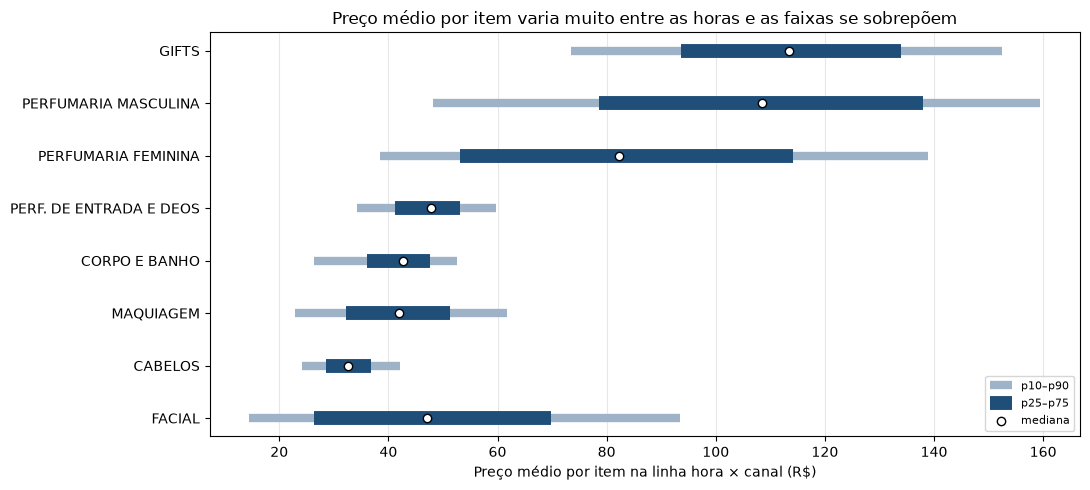

In [30]:
sql_price_spread = f"""
SELECT
  des_categoria_material,
  COUNT(*) AS linhas,
  SAFE_DIVIDE(SUM(receita_aprovada), SUM(qt_material)) AS preco_medio_item,
  APPROX_QUANTILES(SAFE_DIVIDE(receita_aprovada, qt_material), 100)[OFFSET(10)] AS p10,
  APPROX_QUANTILES(SAFE_DIVIDE(receita_aprovada, qt_material), 100)[OFFSET(25)] AS p25,
  APPROX_QUANTILES(SAFE_DIVIDE(receita_aprovada, qt_material), 100)[OFFSET(50)] AS mediana,
  APPROX_QUANTILES(SAFE_DIVIDE(receita_aprovada, qt_material), 100)[OFFSET(75)] AS p75,
  APPROX_QUANTILES(SAFE_DIVIDE(receita_aprovada, qt_material), 100)[OFFSET(90)] AS p90
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
  AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
  AND receita_aprovada > 0
  AND qt_material > 0
GROUP BY 1
ORDER BY preco_medio_item
"""

price_spread = run_bq(sql_price_spread, "variação do preço médio por hora, por categoria")
price_spread[["preco_medio_item", "p10", "p25", "mediana", "p75", "p90"]] = (
    price_spread[["preco_medio_item", "p10", "p25", "mediana", "p75", "p90"]].astype(float)
)
display(price_spread)

fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(len(price_spread))
ax.hlines(y, price_spread["p10"], price_spread["p90"], color="#9fb3c8", linewidth=6, label="p10–p90")
ax.hlines(y, price_spread["p25"], price_spread["p75"], color="#1f4e79", linewidth=10, label="p25–p75")
ax.scatter(price_spread["mediana"], y, color="white", edgecolor="black", zorder=3, label="mediana")
ax.set_yticks(y)
ax.set_yticklabels(price_spread["des_categoria_material"])
ax.set_xlabel("Preço médio por item na linha hora × canal (R$)")
ax.set_title("Preço médio por item varia muito entre as horas e as faixas se sobrepõem")
ax.grid(axis="x", alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

As faixas p10–p90 das categorias se sobrepõem bastante (por exemplo FACIAL, CABELOS, MAQUIAGEM e CORPO E BANHO ocupam praticamente a mesma região). Para medir o quanto o preço é confiável como "classificador", testamos nas **linhas válidas**, onde sabemos a resposta certa:

- **Entre as 8 categorias:** a categoria de preço de referência mais próximo é a verdadeira?
- **Entre 2 categorias** (o caso ambíguo mais comum): comparando a categoria verdadeira com cada uma das outras 7, com que frequência o preço escolhe a certa?

O preço de referência é o preço médio ponderado da categoria no mesmo mês e canal.

In [31]:
sql_price_classifier = f"""
WITH preco_ref AS (
  SELECT
    DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
    des_canal_venda_final_agrup,
    des_categoria_material,
    SAFE_DIVIDE(SUM(receita_aprovada), SUM(qt_material)) AS preco_ref
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
    AND receita_aprovada > 0
  GROUP BY 1, 2, 3
),
validas AS (
  SELECT
    FARM_FINGERPRINT(CONCAT(CAST(dt_hr_venda AS STRING), des_canal_venda_final_agrup, des_categoria_material)) AS id_linha,
    DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,
    des_canal_venda_final_agrup,
    des_categoria_material AS categoria_real,
    SAFE_DIVIDE(receita_aprovada, qt_material) AS preco_linha
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
    AND receita_aprovada > 0
    AND qt_material > 0
),
distancias AS (
  -- distância (em log) entre o preço da linha e o preço de referência de cada categoria
  SELECT
    v.id_linha,
    v.categoria_real,
    r.des_categoria_material AS categoria_comparada,
    ABS(LN(v.preco_linha / r.preco_ref)) AS distancia
  FROM validas v
  JOIN preco_ref r
    ON  r.mes = v.mes
    AND r.des_canal_venda_final_agrup = v.des_canal_venda_final_agrup
),
mais_proxima AS (
  -- categoria com preço de referência mais próximo de cada linha
  SELECT *
  FROM distancias
  WHERE TRUE
  QUALIFY ROW_NUMBER() OVER (PARTITION BY id_linha ORDER BY distancia) = 1
),
entre_8 AS (
  SELECT
    COUNT(*) AS linhas,
    AVG(IF(categoria_comparada = categoria_real, 1, 0)) AS acerto
  FROM mais_proxima
),
entre_2 AS (
  -- cada linha válida contra cada uma das outras 7 categorias
  SELECT
    COUNT(*) AS pares,
    AVG(IF(real.distancia < outra.distancia, 1, 0)) AS acerto
  FROM distancias real
  JOIN distancias outra
    ON  outra.id_linha = real.id_linha
    AND outra.categoria_comparada != real.categoria_real
  WHERE real.categoria_comparada = real.categoria_real
)
SELECT 'Escolher entre 8 categorias' AS cenario, linhas AS comparacoes, acerto, 1 / 8 AS acerto_por_acaso FROM entre_8
UNION ALL
SELECT 'Escolher entre 2 categorias', pares, acerto, 1 / 2 FROM entre_2
"""

price_classifier = run_bq(sql_price_classifier, "preço médio como classificador de categoria")
display(price_classifier)

[BigQuery] preço médio como classificador de categoria | estimativa processada: 4.51 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cenario,comparacoes,acerto,acerto_por_acaso
0,Escolher entre 8 categorias,80071,0.3350,0.1250
1,Escolher entre 2 categorias,560497,0.7724,0.5000


**Conclusão — é possível recuperar?**

- **Sim, quando há 1 candidata: 3.072 linhas (57,5% das inválidas e 62,5% do `qt_material` inválido).** A estrutura do grão garante que a linha inválida é a única categoria ausente naquela hora × canal, então a recuperação é **determinística**, sem estimativa. Com isso, a categoria inválida cai de ~6,0% para ~2,5% das linhas.
- **Não, quando há 2 ou mais candidatas: 2.269 linhas (42,5%).** O preço médio por item **não é confiável** para desempatar:
  - o preço de uma mesma categoria varia muito de hora para hora (FACIAL vai de R$ 15 a R$ 94 entre p10 e p90; PERFUMARIA FEMININA de R$ 38 a R$ 139) e as faixas se sobrepõem;
  - mesmo nas linhas **válidas**, onde a resposta é conhecida, o preço acerta a categoria em só **33,5%** dos casos entre 8 opções e, entre apenas 2 opções, erra **~1 em cada 4** (77,2% de acerto, contra 50% por acaso).

**Decisão:** recuperar apenas os casos de 1 candidata e manter os demais como `CATEGORIA_INVALIDA`. Os totais diários (target) não mudam, pois essas linhas já estavam incluídas; a recuperação melhora somente as análises e features por categoria.

## 2.4 Receita negativa

Receita negativa pode representar estorno, devolução ou ajuste. Sem confirmação de negócio, o comportamento correto é **quantificar e investigar**, não excluir automaticamente.

In [32]:
sql_negative_revenue = f"""
SELECT
  COUNTIF(receita_aprovada < 0) AS linhas_receita_aprovada_negativa,
  SAFE_DIVIDE(COUNTIF(receita_aprovada < 0), COUNT(*)) AS pct_linhas_negativas,
  CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64) AS receita_aprovada_negativa_total,
  CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64) AS receita_aprovada_nao_negativa_total,
  SAFE_DIVIDE(
    -CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64),
    CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
  ) AS impacto_abs_negativo_sobre_positivo
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

negative_revenue = run_bq(sql_negative_revenue, "receita negativa")
display(negative_revenue)

[BigQuery] receita negativa | estimativa processada: 2.05 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,linhas_receita_aprovada_negativa,pct_linhas_negativas,receita_aprovada_negativa_total,receita_aprovada_nao_negativa_total,impacto_abs_negativo_sobre_positivo
0,3513,0.0392,"-21,051,829.5400","511,361,656.1600",0.0412


### 2.4.1 Existe padrão por canal?

Comparamos a frequência de linhas negativas e o impacto financeiro dentro de cada canal. O objetivo é separar um comportamento sistêmico de algo concentrado em App ou Site.

[BigQuery] receita negativa por canal | estimativa processada: 2.52 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_canal_venda_final_agrup,linhas,linhas_negativas,pct_linhas_negativas,receita_aprovada_negativa,receita_aprovada_positiva,impacto_negativo_sobre_positivo
0,App,45936,1859,0.0405,"-16,197,443.4000","389,670,872.4900",0.0416
1,Site,43630,1654,0.0379,"-4,854,386.1400","121,690,783.6700",0.0399


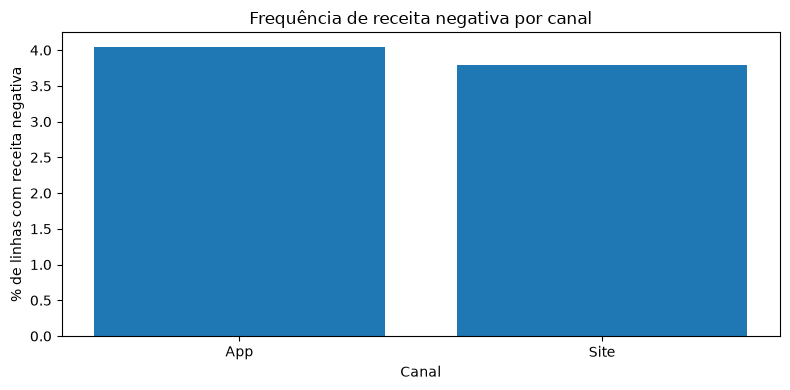

In [33]:
sql_negative_by_channel = f"""
SELECT
  des_canal_venda_final_agrup,
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada < 0) AS linhas_negativas,
  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_linhas_negativas,

  CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_aprovada_negativa,

  CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_aprovada_positiva,

  SAFE_DIVIDE(
    -CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64),
    CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
  ) AS impacto_negativo_sobre_positivo

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY ABS(receita_aprovada_negativa) DESC
"""

negative_by_channel = run_bq(
    sql_negative_by_channel,
    "receita negativa por canal",
)
display(negative_by_channel)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    negative_by_channel["des_canal_venda_final_agrup"],
    negative_by_channel["pct_linhas_negativas"] * 100,
)
ax.set_title("Frequência de receita negativa por canal")
ax.set_xlabel("Canal")
ax.set_ylabel("% de linhas com receita negativa")
fig.tight_layout()
plt.show()

### 2.4.2 Existe padrão por categoria?

Categorias inválidas são agrupadas em `__CATEGORIA_INVALIDA__` para verificar se a corrupção do campo e a receita negativa podem estar relacionadas.

[BigQuery] receita negativa por categoria | estimativa processada: 3.36 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_categoria_material,linhas,linhas_negativas,pct_linhas_negativas,receita_aprovada_negativa,receita_aprovada_positiva,impacto_negativo_sobre_positivo
0,PERFUMARIA FEMININA,10816,425,0.0393,"-5,642,496.0700","125,311,001.2100",0.0450
1,PERFUMARIA MASCULINA,10845,418,0.0385,"-5,087,520.4700","131,825,914.8800",0.0386
2,CORPO E BANHO,10855,404,0.0372,"-2,901,295.4900","74,603,719.8400",0.0389
3,PERF. DE ENTRADA E DEOS,10830,455,0.0420,"-2,081,865.1900","53,247,300.6000",0.0391
4,GIFTS,10513,417,0.0397,"-2,077,178.0100","51,562,388.3100",0.0403
5,__CATEGORIA_INVALIDA__,5341,198,0.0371,"-1,245,101.6100","30,510,019.5600",0.0408
6,CABELOS,10265,418,0.0407,"-813,835.1700","17,262,471.9700",0.0471
7,MAQUIAGEM,10470,410,0.0392,"-805,977.5800","18,088,375.1800",0.0446
8,FACIAL,9631,368,0.0382,"-396,559.9500","8,950,464.6100",0.0443


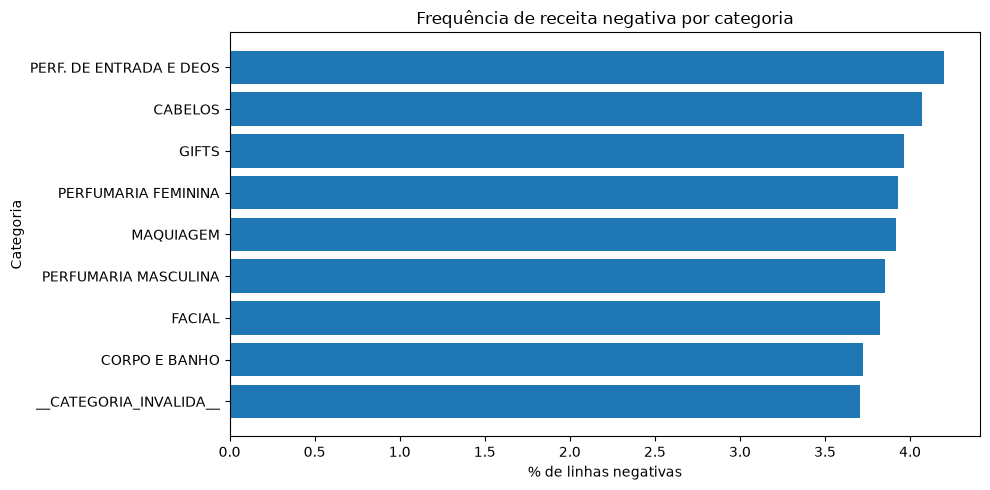

In [34]:
sql_negative_by_category = f"""
WITH base AS (
  SELECT
    IF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL,
      '__CATEGORIA_INVALIDA__',
      des_categoria_material
    ) AS des_categoria_material,
    receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  des_categoria_material,
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada < 0) AS linhas_negativas,
  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_linhas_negativas,

  CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_aprovada_negativa,

  CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
    AS receita_aprovada_positiva,

  SAFE_DIVIDE(
    -CAST(SUM(IF(receita_aprovada < 0, receita_aprovada, 0)) AS FLOAT64),
    CAST(SUM(IF(receita_aprovada >= 0, receita_aprovada, 0)) AS FLOAT64)
  ) AS impacto_negativo_sobre_positivo

FROM base
GROUP BY 1
ORDER BY ABS(receita_aprovada_negativa) DESC
"""

negative_by_category = run_bq(
    sql_negative_by_category,
    "receita negativa por categoria",
)
display(negative_by_category)

fig, ax = plt.subplots(figsize=(10, 5))
ordered = negative_by_category.sort_values("pct_linhas_negativas")
ax.barh(
    ordered["des_categoria_material"],
    ordered["pct_linhas_negativas"] * 100,
)
ax.set_title("Frequência de receita negativa por categoria")
ax.set_xlabel("% de linhas negativas")
ax.set_ylabel("Categoria")
fig.tight_layout()
plt.show()

### 2.4.3 Categoria × canal — concentração vs. taxa global

Em vez de um heatmap, comparamos cada combinação com a **taxa global de receita negativa**.

- `diferenca_pp`: diferença em pontos percentuais contra a taxa global;
- `lift_vs_global`: taxa do grupo dividida pela taxa global;
- lift ≈ `1,0` indica comportamento próximo ao padrão geral.

Isso evita superinterpretar pequenas diferenças visuais de cor.

In [35]:
sql_negative_category_channel = f"""
WITH base AS (
  SELECT
    IF(
      SAFE_CAST(des_categoria_material AS NUMERIC) IS NOT NULL,
      '__CATEGORIA_INVALIDA__',
      des_categoria_material
    ) AS des_categoria_material,
    des_canal_venda_final_agrup,
    receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
global_rate AS (
  SELECT
    SAFE_DIVIDE(
      COUNTIF(receita_aprovada < 0),
      COUNT(*)
    ) AS pct_negativa_global
  FROM base
),
grouped AS (
  SELECT
    des_categoria_material,
    des_canal_venda_final_agrup,
    COUNT(*) AS linhas,
    COUNTIF(receita_aprovada < 0) AS linhas_negativas,
    SAFE_DIVIDE(
      COUNTIF(receita_aprovada < 0),
      COUNT(*)
    ) AS pct_linhas_negativas,
    CAST(
      SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
      AS FLOAT64
    ) AS receita_aprovada_negativa
  FROM base
  GROUP BY 1, 2
)
SELECT
  g.*,
  r.pct_negativa_global,
  100 * (g.pct_linhas_negativas - r.pct_negativa_global)
    AS diferenca_pp,
  SAFE_DIVIDE(
    g.pct_linhas_negativas,
    r.pct_negativa_global
  ) AS lift_vs_global,
  SAFE_DIVIDE(
    ABS(g.receita_aprovada_negativa),
    SUM(ABS(g.receita_aprovada_negativa)) OVER ()
  ) AS share_valor_negativo
FROM grouped g
CROSS JOIN global_rate r
ORDER BY ABS(g.pct_linhas_negativas - r.pct_negativa_global) DESC
"""

negative_category_channel = run_bq(
    sql_negative_category_channel,
    "receita negativa por categoria x canal",
)

display(
    negative_category_channel[
        [
            "des_categoria_material",
            "des_canal_venda_final_agrup",
            "linhas",
            "linhas_negativas",
            "pct_linhas_negativas",
            "pct_negativa_global",
            "diferenca_pp",
            "lift_vs_global",
            "share_valor_negativo",
        ]
    ]
)

print(
    "Faixa de lift vs. taxa global:",
    f"{negative_category_channel['lift_vs_global'].min():.3f}",
    "a",
    f"{negative_category_channel['lift_vs_global'].max():.3f}",
)

[BigQuery] receita negativa por categoria x canal | estimativa processada: 3.82 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,des_categoria_material,des_canal_venda_final_agrup,linhas,linhas_negativas,pct_linhas_negativas,pct_negativa_global,diferenca_pp,lift_vs_global,share_valor_negativo
0,FACIAL,Site,4470,149,0.0333,0.0392,-0.5889,0.8499,0.0034
1,PERFUMARIA MASCULINA,Site,5390,190,0.0353,0.0392,-0.3972,0.8987,0.0555
2,PERF. DE ENTRADA E DEOS,Site,5348,229,0.0428,0.0392,0.3597,1.0917,0.0270
3,__CATEGORIA_INVALIDA__,Site,2583,93,0.0360,0.0392,-0.3218,0.9180,0.0113
4,FACIAL,App,5161,219,0.0424,0.0392,0.3211,1.0819,0.0155
5,PERFUMARIA MASCULINA,App,5455,228,0.0418,0.0392,0.2574,1.0656,0.1862
6,CORPO E BANHO,App,5468,202,0.0369,0.0392,-0.2280,0.9419,0.1105
7,CABELOS,App,5376,223,0.0415,0.0392,0.2258,1.0576,0.0297
8,PERFUMARIA FEMININA,App,5456,225,0.0412,0.0392,0.2017,1.0514,0.2075
9,PERF. DE ENTRADA E DEOS,App,5482,226,0.0412,0.0392,0.2003,1.0511,0.0719


Faixa de lift vs. taxa global: 0.850 a 1.092


### 2.4.4 Quando a receita negativa aparece na linha do tempo?

A análise diária permite distinguir um comportamento recorrente de episódios concentrados. Mostramos tanto a quantidade de linhas negativas quanto o valor negativo absoluto.

[BigQuery] receita negativa na linha do tempo | estimativa processada: 2.05 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,data,linhas_negativas,valor_negativo_abs,receita_aprovada_liquida_dia
27,2025-11-28,18,"641,051.2500","12,707,522.6100"
10,2025-11-11,22,"458,826.8600","6,267,619.5000"
18,2025-11-19,16,"289,235.1300","4,768,614.2000"
17,2025-11-18,14,"283,689.2500","4,158,846.5600"
12,2025-11-13,16,"272,882.7600","3,829,298.4400"
2,2025-11-03,18,"257,618.4800","6,165,950.5600"
5,2025-11-06,19,"257,422.4000","5,735,464.7400"
188,2026-05-08,16,"244,613.3000","4,230,467.1700"
14,2025-11-15,10,"224,391.3600","2,467,078.5400"
4,2025-11-05,25,"218,912.5500","5,286,456.3800"


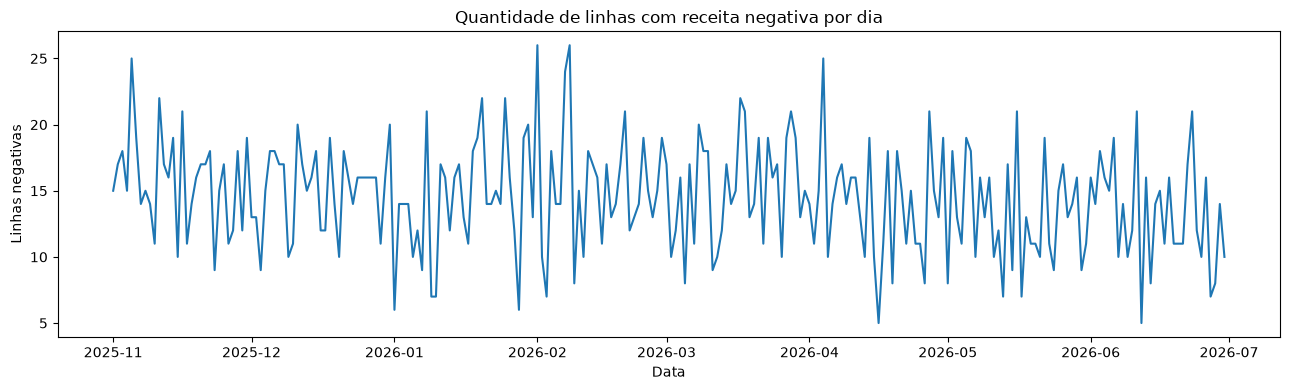

In [36]:
sql_negative_timeline = f"""
SELECT
  DATE(dt_hr_venda) AS data,
  COUNTIF(receita_aprovada < 0) AS linhas_negativas,
  CAST(
    -SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS valor_negativo_abs,
  CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada_liquida_dia
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

negative_timeline = run_bq(
    sql_negative_timeline,
    "receita negativa na linha do tempo",
)
negative_timeline["data"] = pd.to_datetime(negative_timeline["data"])

display(
    negative_timeline.nlargest(10, "valor_negativo_abs")
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    negative_timeline["data"],
    negative_timeline["linhas_negativas"],
)
ax.set_title("Quantidade de linhas com receita negativa por dia")
ax.set_xlabel("Data")
ax.set_ylabel("Linhas negativas")
fig.tight_layout()
plt.show()

### 2.4.5 Receita negativa ao longo dos meses — normalizada pela receita

O valor absoluto de receita negativa pode ser enganoso: meses de alto volume, como novembro/Black Friday, naturalmente tendem a apresentar valores absolutos maiores.

Por isso, usamos como principal indicador:

`impacto_negativo_pct = |receita negativa| / receita positiva do mês`

Assim medimos o peso relativo dos ajustes negativos independentemente do tamanho do mês.

[BigQuery] receita negativa mensal normalizada | estimativa processada: 2.05 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,mes,receita_aprovada_positiva,receita_aprovada_negativa_abs,receita_aprovada_liquida,linhas,linhas_receita_aprovada_negativa,pct_linhas_receita_aprovada_negativa,impacto_negativo_pct_receita_aprovada_positiva
0,2025-11-01,"134,818,940.5700","5,841,561.1000","128,977,379.4700",11423,474,0.0415,0.0433
1,2025-12-01,"66,015,825.5900","2,768,553.5200","63,247,272.0700",11577,469,0.0405,0.0419
2,2026-01-01,"51,480,912.8300","2,053,492.3600","49,427,420.4700",11424,440,0.0385,0.0399
3,2026-02-01,"36,395,530.6900","1,615,349.3300","34,780,181.3600",10323,436,0.0422,0.0444
4,2026-03-01,"54,384,042.7700","2,318,879.4900","52,065,163.2800",11488,473,0.0412,0.0426
5,2026-04-01,"46,032,179.5200","1,750,053.4400","44,282,126.0800",10983,419,0.0381,0.0380
6,2026-05-01,"72,914,675.0400","2,864,708.9000","70,049,966.1400",11497,404,0.0351,0.0393
7,2026-06-01,"49,319,549.1500","1,839,231.4000","47,480,317.7500",10851,398,0.0367,0.0373


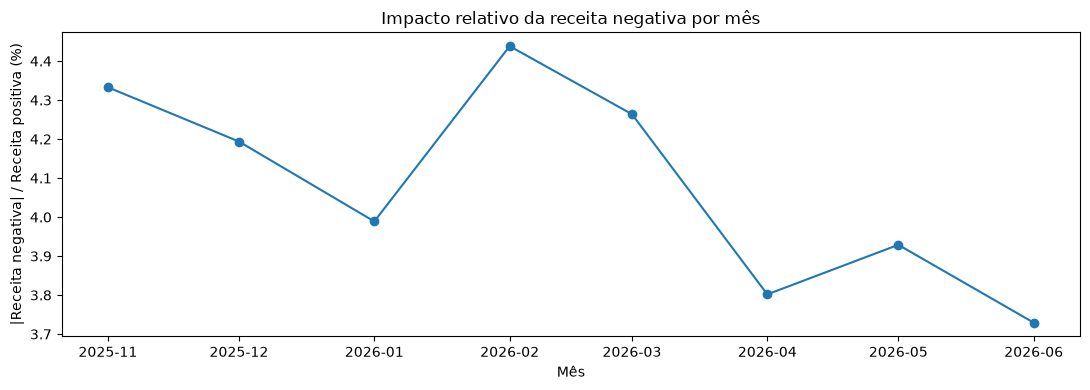

In [37]:
sql_negative_revenue_monthly_ratio = f"""
SELECT
  DATE_TRUNC(DATE(dt_hr_venda), MONTH) AS mes,

  CAST(
    SUM(IF(receita_aprovada > 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS receita_aprovada_positiva,

  CAST(
    -SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS receita_aprovada_negativa_abs,

  CAST(
    SUM(receita_aprovada)
    AS FLOAT64
  ) AS receita_aprovada_liquida,

  COUNT(*) AS linhas,

  COUNTIF(receita_aprovada < 0)
    AS linhas_receita_aprovada_negativa,

  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_linhas_receita_aprovada_negativa,

  SAFE_DIVIDE(
    -CAST(
      SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
      AS FLOAT64
    ),
    CAST(
      SUM(IF(receita_aprovada > 0, receita_aprovada, 0))
      AS FLOAT64
    )
  ) AS impacto_negativo_pct_receita_aprovada_positiva

FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
GROUP BY 1
ORDER BY 1
"""

negative_revenue_monthly_ratio = run_bq(
    sql_negative_revenue_monthly_ratio,
    "receita negativa mensal normalizada",
)

negative_revenue_monthly_ratio["mes"] = pd.to_datetime(
    negative_revenue_monthly_ratio["mes"]
)

display(negative_revenue_monthly_ratio)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    negative_revenue_monthly_ratio["mes"],
    negative_revenue_monthly_ratio[
        "impacto_negativo_pct_receita_aprovada_positiva"
    ] * 100,
    marker="o",
)
ax.set_title("Impacto relativo da receita negativa por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("|Receita negativa| / Receita positiva (%)")
fig.tight_layout()
plt.show()

In [38]:
negative_month_peak = negative_revenue_monthly_ratio.loc[
    negative_revenue_monthly_ratio[
        "impacto_negativo_pct_receita_aprovada_positiva"
    ].idxmax()
]

print(
    "Maior impacto relativo:",
    negative_month_peak["mes"].strftime("%Y-%m"),
    "|",
    f"{negative_month_peak['impacto_negativo_pct_receita_aprovada_positiva']:.2%}",
)

display(
    negative_revenue_monthly_ratio.sort_values(
        "impacto_negativo_pct_receita_aprovada_positiva",
        ascending=False,
    )
)

Maior impacto relativo: 2026-02 | 4.44%


,mes,receita_aprovada_positiva,receita_aprovada_negativa_abs,receita_aprovada_liquida,linhas,linhas_receita_aprovada_negativa,pct_linhas_receita_aprovada_negativa,impacto_negativo_pct_receita_aprovada_positiva
3,2026-02-01,"36,395,530.6900","1,615,349.3300","34,780,181.3600",10323,436,0.0422,0.0444
0,2025-11-01,"134,818,940.5700","5,841,561.1000","128,977,379.4700",11423,474,0.0415,0.0433
4,2026-03-01,"54,384,042.7700","2,318,879.4900","52,065,163.2800",11488,473,0.0412,0.0426
1,2025-12-01,"66,015,825.5900","2,768,553.5200","63,247,272.0700",11577,469,0.0405,0.0419
2,2026-01-01,"51,480,912.8300","2,053,492.3600","49,427,420.4700",11424,440,0.0385,0.0399
6,2026-05-01,"72,914,675.0400","2,864,708.9000","70,049,966.1400",11497,404,0.0351,0.0393
5,2026-04-01,"46,032,179.5200","1,750,053.4400","44,282,126.0800",10983,419,0.0381,0.0380
7,2026-06-01,"49,319,549.1500","1,839,231.4000","47,480,317.7500",10851,398,0.0367,0.0373


**Leitura:** novembro só será considerado mais problemático se o **percentual** de receita negativa também estiver elevado. Se o valor absoluto subir na Black Friday, mas o percentual permanecer estável, isso é compatível com o simples aumento de escala do negócio.

### 2.4.6 Existe padrão por hora do dia?

Mesma metodologia da seção 2.3.4 (taxa por hora, faixa esperada de 95% e qui-quadrado), agora para
`receita_aprovada < 0`. Um padrão operacional real — por exemplo, estornos processados em lote de madrugada —
apareceria como um **bloco de horas consecutivas** acima da faixa.

[BigQuery] Receita negativa por hora do dia | estimativa processada: 2.05 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


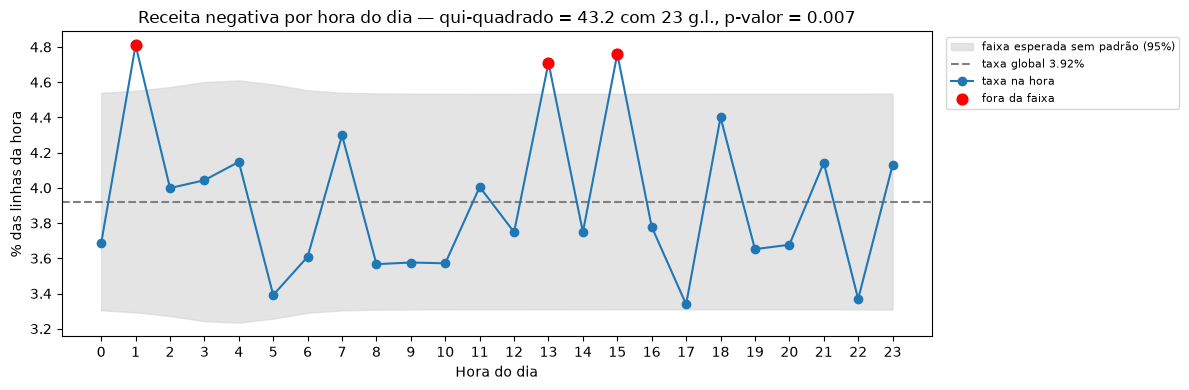

Horas fora da faixa: 3 de 24 (esperado por acaso ≈ 1) -> [1, 13, 15]


,hora,linhas,ocorrencias,taxa,lift_vs_global,fora_da_faixa
0,0,3798,140,0.0369,0.9398,False
1,1,3659,176,0.0481,1.2264,True
2,2,3426,137,0.0400,1.0195,False
3,3,3141,127,0.0404,1.0309,False
4,4,3062,127,0.0415,1.0575,False
5,5,3273,111,0.0339,0.8647,False
6,6,3630,131,0.0361,0.9201,False
7,7,3792,163,0.0430,1.0959,False
8,8,3841,137,0.0357,0.9094,False
9,9,3859,138,0.0358,0.9117,False


In [39]:
negative_revenue_hour = taxa_por_hora(
    "receita_aprovada < 0",
    "Receita negativa por hora do dia",
)
display(negative_revenue_hour[["hora", "linhas", "ocorrencias", "taxa", "lift_vs_global", "fora_da_faixa"]])

**Leitura:** com ~89 mil linhas, o qui-quadrado detecta diferenças pequenas. Por isso a pergunta prática é
dupla: (1) a variação é **estatisticamente** diferente do acaso? (2) ela forma um **padrão de negócio**
(horas consecutivas, horário de rotina)? Diferenças de poucos décimos de ponto percentual em horas
espalhadas, sem continuidade, não sustentam a hipótese de um processo em horário específico.

### 2.4.7 Receita negativa × desconto

Também investigamos se a receita negativa apresenta relação com `vlr_venda_desconto`.

Assumindo que `vlr_venda_desconto` representa o **valor concedido de desconto**, definimos:

`receita_bruta_estimada = receita_aprovada + vlr_venda_desconto`

e, quando o denominador é positivo:

`taxa_desconto = vlr_venda_desconto / receita_bruta_estimada`

A taxa não é calculada quando a receita bruta estimada é menor ou igual a zero, porque nesse caso o percentual perde interpretação econômica.

In [40]:
sql_negative_discount_relation = f"""
WITH base AS (
  SELECT
    receita_aprovada,
    vlr_venda_desconto,
    nr_pedidos,
    qt_material,

    receita_aprovada + vlr_venda_desconto
      AS receita_bruta_estimada,

    CASE
      WHEN vlr_venda_desconto >= 0
       AND receita_aprovada + vlr_venda_desconto > 0
      THEN SAFE_DIVIDE(
        vlr_venda_desconto,
        receita_aprovada + vlr_venda_desconto
      )
    END AS taxa_desconto,

    IF(receita_aprovada < 0, 'NEGATIVA', 'NAO_NEGATIVA')
      AS status_receita_aprovada

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  status_receita_aprovada,
  COUNT(*) AS linhas,

  COUNTIF(vlr_venda_desconto = 0) AS linhas_sem_desconto,
  COUNTIF(vlr_venda_desconto > 0) AS linhas_com_desconto,
  COUNTIF(vlr_venda_desconto < 0) AS linhas_desconto_negativo,

  COUNTIF(taxa_desconto IS NOT NULL) AS linhas_taxa_valida,

  CAST(AVG(vlr_venda_desconto) AS FLOAT64)
    AS desconto_medio_valor,

  CAST(
    APPROX_QUANTILES(vlr_venda_desconto, 100)[OFFSET(50)]
    AS FLOAT64
  ) AS desconto_mediano_valor,

  AVG(taxa_desconto) AS taxa_desconto_media,

  APPROX_QUANTILES(taxa_desconto, 100 IGNORE NULLS)[OFFSET(50)]
    AS taxa_desconto_mediana,

  APPROX_QUANTILES(taxa_desconto, 100 IGNORE NULLS)[OFFSET(90)]
    AS taxa_desconto_p90,

  SUM(nr_pedidos) AS nr_pedidos,
  SUM(qt_material) AS qt_material

FROM base
GROUP BY 1
ORDER BY 1
"""

negative_discount_relation = run_bq(
    sql_negative_discount_relation,
    "receita negativa x desconto",
)
display(negative_discount_relation)

[BigQuery] receita negativa x desconto | estimativa processada: 4.78 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,status_receita_aprovada,linhas,linhas_sem_desconto,linhas_com_desconto,linhas_desconto_negativo,linhas_taxa_valida,desconto_medio_valor,desconto_mediano_valor,taxa_desconto_media,taxa_desconto_mediana,taxa_desconto_p90,nr_pedidos,qt_material
0,NAO_NEGATIVA,86053,405,85648,0,85987,"4,229.6663","1,041.6500",0.339774326,0.311377794,0.542090917,6254692,9491377
1,NEGATIVA,3513,8,3505,0,497,"4,495.2663","1,058.5300",10.480707553,3.637313191,15.344422290,266203,404824


#### A ocorrência de receita negativa muda quando há desconto?

Primeiro fazemos uma leitura simples de incidência: linhas sem desconto, com desconto e, caso existam, valores de desconto negativos.

In [41]:
sql_negative_by_discount_presence = f"""
WITH base AS (
  SELECT
    receita_aprovada,
    vlr_venda_desconto,

    CASE
      WHEN vlr_venda_desconto < 0 THEN 'DESCONTO_NEGATIVO'
      WHEN vlr_venda_desconto = 0 THEN 'SEM_DESCONTO'
      WHEN vlr_venda_desconto > 0 THEN 'COM_DESCONTO'
      ELSE 'NULO'
    END AS grupo_desconto

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  grupo_desconto,
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada < 0) AS linhas_receita_aprovada_negativa,

  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_receita_aprovada_negativa,

  CAST(
    SUM(IF(receita_aprovada < 0, receita_aprovada, 0))
    AS FLOAT64
  ) AS receita_aprovada_negativa

FROM base
GROUP BY 1
ORDER BY linhas DESC
"""

negative_by_discount_presence = run_bq(
    sql_negative_by_discount_presence,
    "receita negativa por presença de desconto",
)
display(negative_by_discount_presence)

[BigQuery] receita negativa por presença de desconto | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,grupo_desconto,linhas,linhas_receita_aprovada_negativa,pct_receita_aprovada_negativa,receita_aprovada_negativa
0,COM_DESCONTO,89153,3505,0.0393,"-21,050,874.7400"
1,SEM_DESCONTO,413,8,0.0194,-954.8000


#### Receita negativa por intensidade de desconto

Para linhas em que a taxa de desconto é economicamente válida, dividimos o histórico em **5 faixas de mesma quantidade de observações**. Isso ajuda a verificar se a incidência de receita negativa cresce conforme aumenta a intensidade do desconto.

[BigQuery] receita negativa por intensidade de desconto | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,faixa_desconto,linhas,taxa_min,taxa_media,taxa_max,linhas_receita_aprovada_negativa,pct_receita_aprovada_negativa
0,1,17297,0E-9,0.162841393,0.215305571,0,0.0000
1,2,17297,0.215308546,0.248234297,0.280361021,0,0.0000
2,3,17297,0.280373227,0.312954053,0.348035765,0,0.0000
3,4,17297,0.348039983,0.397330437,0.456198286,0,0.0000
4,5,17296,0.456203696,0.868924582,408.128479657,497,0.0287


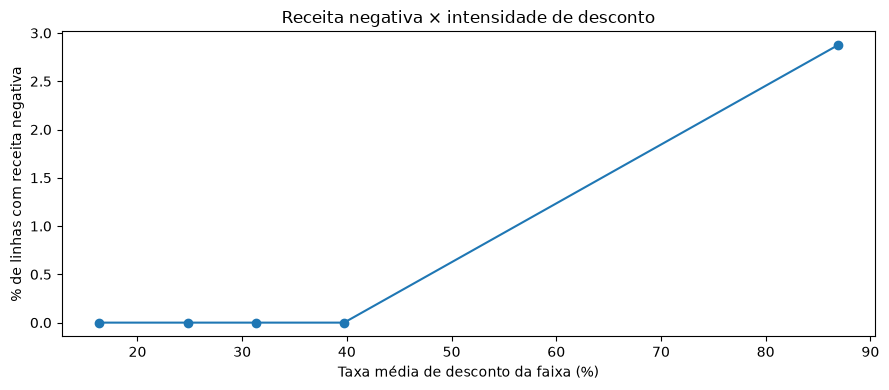

In [42]:
sql_negative_by_discount_bucket = f"""
WITH base AS (
  SELECT
    receita_aprovada,

    CASE
      WHEN vlr_venda_desconto >= 0
       AND receita_aprovada + vlr_venda_desconto > 0
      THEN SAFE_DIVIDE(
        vlr_venda_desconto,
        receita_aprovada + vlr_venda_desconto
      )
    END AS taxa_desconto

  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
valid AS (
  SELECT *
  FROM base
  WHERE taxa_desconto IS NOT NULL
),
bucketed AS (
  SELECT
    *,
    NTILE(5) OVER (ORDER BY taxa_desconto) AS faixa_desconto
  FROM valid
)
SELECT
  faixa_desconto,
  COUNT(*) AS linhas,
  MIN(taxa_desconto) AS taxa_min,
  AVG(taxa_desconto) AS taxa_media,
  MAX(taxa_desconto) AS taxa_max,

  COUNTIF(receita_aprovada < 0) AS linhas_receita_aprovada_negativa,

  SAFE_DIVIDE(
    COUNTIF(receita_aprovada < 0),
    COUNT(*)
  ) AS pct_receita_aprovada_negativa

FROM bucketed
GROUP BY 1
ORDER BY 1
"""

negative_by_discount_bucket = run_bq(
    sql_negative_by_discount_bucket,
    "receita negativa por intensidade de desconto",
)
display(negative_by_discount_bucket)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    negative_by_discount_bucket["taxa_media"] * 100,
    negative_by_discount_bucket["pct_receita_aprovada_negativa"] * 100,
    marker="o",
)
ax.set_title("Receita negativa × intensidade de desconto")
ax.set_xlabel("Taxa média de desconto da faixa (%)")
ax.set_ylabel("% de linhas com receita negativa")
fig.tight_layout()
plt.show()

**Leitura:** se a taxa de receita negativa permanecer aproximadamente estável entre as faixas, desconto provavelmente não explica o fenômeno. Se houver crescimento consistente nas faixas de maior desconto, teremos um sinal para investigação — ainda sem afirmar causalidade.

## 2.5 Cobertura temporal

O dataset deveria cobrir todas as horas entre 01/11/2025 e 30/06/2026. Geramos o calendário esperado no BigQuery e comparamos com o observado.

In [43]:
sql_coverage = f"""
WITH horas_esperadas AS (
  SELECT DATETIME(ts) AS dt_hr_venda
  FROM UNNEST(
    GENERATE_TIMESTAMP_ARRAY(
      TIMESTAMP('{START_DATE} 00:00:00'),
      TIMESTAMP('{END_DATE} 23:00:00'),
      INTERVAL 1 HOUR
    )
  ) AS ts
),
horas_observadas AS (
  SELECT DISTINCT dt_hr_venda
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
canais AS (
  SELECT des_canal_venda_final_agrup
  FROM UNNEST(['App', 'Site']) AS des_canal_venda_final_agrup
),
hora_canal_observado AS (
  SELECT DISTINCT
    dt_hr_venda,
    des_canal_venda_final_agrup
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
),
faltas_hora_canal AS (
  SELECT h.dt_hr_venda, c.des_canal_venda_final_agrup
  FROM horas_esperadas h
  CROSS JOIN canais c
  LEFT JOIN hora_canal_observado o
    ON h.dt_hr_venda = o.dt_hr_venda
   AND c.des_canal_venda_final_agrup = o.des_canal_venda_final_agrup
  WHERE o.dt_hr_venda IS NULL
)
SELECT
  (SELECT COUNT(*) FROM horas_esperadas) AS horas_esperadas,
  (
    SELECT COUNT(*)
    FROM horas_esperadas h
    LEFT JOIN horas_observadas o USING (dt_hr_venda)
    WHERE o.dt_hr_venda IS NULL
  ) AS horas_sem_registro,
  (SELECT COUNT(*) FROM faltas_hora_canal) AS combinacoes_hora_canal_ausentes
"""

coverage = run_bq(sql_coverage, "cobertura temporal")
display(coverage)

[BigQuery] cobertura temporal | estimativa processada: 1.15 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,horas_esperadas,horas_sem_registro,combinacoes_hora_canal_ausentes
0,5808,0,2


### Combinações hora × canal ausentes

Além da contagem, mostramos as combinações faltantes para entender se são eventos isolados ou um padrão operacional.

In [44]:
sql_missing_hour_channel = f"""
WITH horas_esperadas AS (
  SELECT DATETIME(ts) AS dt_hr_venda
  FROM UNNEST(
    GENERATE_TIMESTAMP_ARRAY(
      TIMESTAMP('{START_DATE} 00:00:00'),
      TIMESTAMP('{END_DATE} 23:00:00'),
      INTERVAL 1 HOUR
    )
  ) AS ts
),
canais AS (
  SELECT des_canal_venda_final_agrup
  FROM UNNEST(['App', 'Site']) AS des_canal_venda_final_agrup
),
observado AS (
  SELECT DISTINCT
    dt_hr_venda,
    des_canal_venda_final_agrup
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
)
SELECT
  h.dt_hr_venda,
  c.des_canal_venda_final_agrup
FROM horas_esperadas h
CROSS JOIN canais c
LEFT JOIN observado o
  ON h.dt_hr_venda = o.dt_hr_venda
 AND c.des_canal_venda_final_agrup = o.des_canal_venda_final_agrup
WHERE o.dt_hr_venda IS NULL
ORDER BY h.dt_hr_venda, c.des_canal_venda_final_agrup
LIMIT 100
"""

missing_hour_channel = run_bq(
    sql_missing_hour_channel,
    "exemplos hora × canal ausentes",
)
display(missing_hour_channel)

print(f"Combinações exibidas: {len(missing_hour_channel)}")

[BigQuery] exemplos hora × canal ausentes | estimativa processada: 1.15 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,dt_hr_venda,des_canal_venda_final_agrup
0,2026-04-05 05:00:00,Site
1,2026-06-13 04:00:00,Site


Combinações exibidas: 2


## 2.6 Precisão monetária no BigQuery

Na carga original foram encontrados números monetários com artefatos de ponto flutuante, por exemplo `3731.5600000000004`.

**Decisão:** preservar a carga bruta em `stg_fact_vendas` e usar `NUMERIC` arredondado a 2 casas em `fact_vendas`.

In [45]:
sql_precision = f"""
SELECT
  COUNT(*) AS linhas,
  COUNTIF(receita_aprovada != ROUND(receita_aprovada, 2)) AS receita_aprovada_acima_2_casas,
  COUNTIF(vlr_venda_desconto != ROUND(vlr_venda_desconto, 2)) AS desconto_acima_2_casas
FROM `{TABLE_ID}`
WHERE {DATE_FILTER}
"""

precision_check = run_bq(sql_precision, "precisão monetária")
display(precision_check)

display(
    bq_schema[
        bq_schema["name"].isin(["receita_aprovada", "vlr_venda_desconto"])
    ]
)

[BigQuery] precisão monetária | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,linhas,receita_aprovada_acima_2_casas,desconto_acima_2_casas
0,89566,0,0


,name,field_type,mode,description
3,receita_aprovada,NUMERIC,NULLABLE,None
6,vlr_venda_desconto,NUMERIC,NULLABLE,None


### 2.6.1 Impacto financeiro da normalização para 2 casas

A `stg_fact_vendas` preserva a carga original. Aqui quantificamos o efeito da normalização monetária.

**Importante:** a fact tratada usa **arredondamento (`ROUND`)**, não truncamento. Mostramos os dois cenários para evidenciar o impacto e o possível viés introduzido por truncar.

In [46]:
sql_precision_impact = f"""
WITH base AS (
  SELECT
    SAFE_CAST(receita_aprovada AS BIGNUMERIC) AS receita_aprovada_original
  FROM `{STG_TABLE_ID}`
  WHERE {DATE_FILTER}
    AND receita_aprovada IS NOT NULL
),
calc AS (
  SELECT
    receita_aprovada_original,
    ROUND(receita_aprovada_original, 2) AS receita_aprovada_round_2,
    TRUNC(receita_aprovada_original, 2) AS receita_aprovada_trunc_2
  FROM base
)
SELECT
  CAST(SUM(receita_aprovada_original) AS FLOAT64) AS receita_aprovada_original_total,
  CAST(SUM(receita_aprovada_round_2) AS FLOAT64) AS receita_aprovada_round_2_total,
  CAST(SUM(receita_aprovada_trunc_2) AS FLOAT64) AS receita_aprovada_trunc_2_total,

  CAST(SUM(receita_aprovada_original - receita_aprovada_round_2) AS FLOAT64)
    AS diferenca_liquida_round,

  CAST(SUM(ABS(receita_aprovada_original - receita_aprovada_round_2)) AS FLOAT64)
    AS ajuste_absoluto_total_round,

  CAST(MAX(ABS(receita_aprovada_original - receita_aprovada_round_2)) AS FLOAT64)
    AS maior_ajuste_linha_round,

  SAFE_DIVIDE(
    CAST(ABS(SUM(receita_aprovada_original - receita_aprovada_round_2)) AS FLOAT64),
    CAST(ABS(SUM(receita_aprovada_original)) AS FLOAT64)
  ) AS pct_impacto_liquido_round,

  CAST(SUM(receita_aprovada_original - receita_aprovada_trunc_2) AS FLOAT64)
    AS diferenca_liquida_trunc,

  CAST(SUM(ABS(receita_aprovada_original - receita_aprovada_trunc_2)) AS FLOAT64)
    AS ajuste_absoluto_total_trunc,

  SAFE_DIVIDE(
    CAST(ABS(SUM(receita_aprovada_original - receita_aprovada_trunc_2)) AS FLOAT64),
    CAST(ABS(SUM(receita_aprovada_original)) AS FLOAT64)
  ) AS pct_impacto_liquido_trunc

FROM calc
"""

precision_impact = run_bq(
    sql_precision_impact,
    "impacto da normalização monetária",
)
display(precision_impact.T.rename(columns={0: "valor"}))

print(
    "Impacto líquido do ROUND sobre a receita total:",
    f"{float(precision_impact.loc[0, 'pct_impacto_liquido_round']):.10%}",
)

[BigQuery] impacto da normalização monetária | estimativa processada: 1.96 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,valor
receita_aprovada_original_total,"490,309,826.7731"
receita_aprovada_round_2_total,"490,309,826.6200"
receita_aprovada_trunc_2_total,"490,309,598.3500"
diferenca_liquida_round,0.1531
ajuste_absoluto_total_round,8.1721
maior_ajuste_linha_round,0.0050
pct_impacto_liquido_round,0.0000
diferenca_liquida_trunc,228.4231
ajuste_absoluto_total_trunc,260.7769
pct_impacto_liquido_trunc,0.0000


Impacto líquido do ROUND sobre a receita total: 0.0000000312%


# 3. Analytical EDA — BigQuery agrega, Python visualiza

## 3.1 Série diária para Analytics e Machine Learning

Somente aqui trazemos dados para Pandas: uma tabela diária de aproximadamente 242 linhas, em vez da granularidade horária completa.

A série diária `daily` foi criada no início da seção 1 e é reutilizada aqui.

### Por que não modelar diretamente no grão horário?

O arquivo horário é valioso e será explorado, mas o **target permanece diário** porque o case solicita previsão de venda diária.

O grão horário pode ser usado a nosso favor para:
- entender o perfil intradiário;
- criar, se necessário, features **históricas** de comportamento horário;
- criar lags por canal/categoria/hora.

Não devemos usar informações do próprio dia realizado para prever esse mesmo dia. Modelar hora a hora e depois somar seria possível, mas adicionaria complexidade sem responder melhor ao objetivo principal do case. A estratégia inicial, portanto, é **forecast diário + enriquecimento com sinais históricos da granularidade horária**.

### Evolução da demanda

`qt_material` é o target do forecast: mede a demanda em unidades, que é o que a operação precisa planejar (estoque, reposição, separação). `nr_pedidos` acompanha como métrica de apoio.

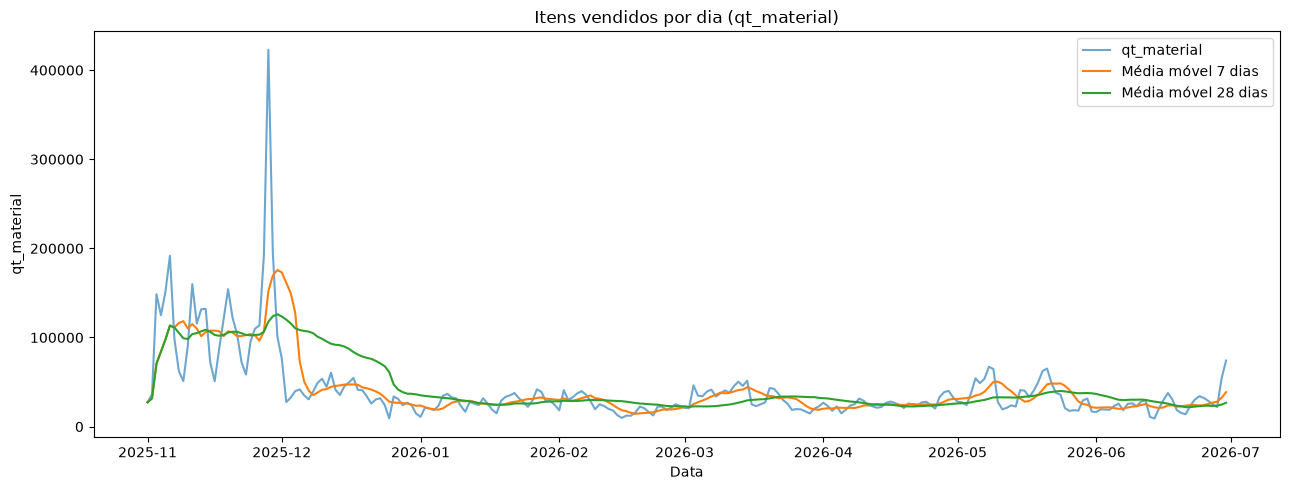

In [47]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily["data"], daily["qt_material"], label="qt_material", alpha=0.65)
ax.plot(
    daily["data"],
    daily["qt_material"].rolling(7, min_periods=1).mean(),
    label="Média móvel 7 dias",
)
ax.plot(
    daily["data"],
    daily["qt_material"].rolling(28, min_periods=1).mean(),
    label="Média móvel 28 dias",
)
ax.set_title("Itens vendidos por dia (qt_material)")
ax.set_xlabel("Data")
ax.set_ylabel("qt_material")
ax.legend()
fig.tight_layout()
plt.show()

### Baseline imediato: médias móveis de 7 e 28 dias

As médias móveis do gráfico acima são descritivas. Para tratá-las como **previsões**, precisamos deslocá-las um dia para trás, garantindo que a previsão de *t* use apenas informação disponível até *t-1*.

Usamos uma janela comum após 28 dias para comparar os dois baselines de forma justa. A métrica principal é **WAPE**. Também mostramos `1 - WAPE` como uma leitura percentual intuitiva, mas ela não substitui as métricas formais do modelo.

,modelo,MAE,WAPE,1-WAPE,Bias
0,Média móvel 7 dias,"11,110.1656",0.3603,0.6397,0.0943
1,Média móvel 28 dias,"15,631.8139",0.5070,0.4930,0.2222


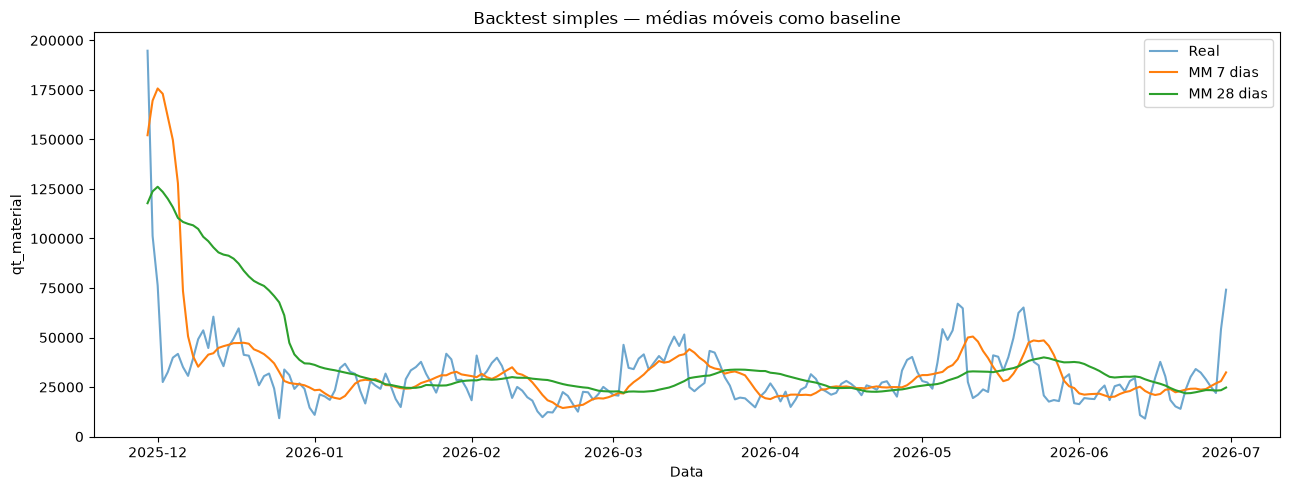

In [48]:
baseline = daily[["data", "qt_material"]].copy()

baseline["pred_media_movel_7"] = (
    baseline["qt_material"]
    .shift(1)
    .rolling(7, min_periods=7)
    .mean()
)

baseline["pred_media_movel_28"] = (
    baseline["qt_material"]
    .shift(1)
    .rolling(28, min_periods=28)
    .mean()
)

evaluation = baseline.dropna(
    subset=["pred_media_movel_7", "pred_media_movel_28"]
).copy()

def forecast_metrics(y_true, y_pred):
    error = y_pred - y_true
    abs_error = np.abs(error)

    mae = abs_error.mean()
    wape = abs_error.sum() / np.abs(y_true).sum()
    bias = error.sum() / y_true.sum()

    return {
        "MAE": mae,
        "WAPE": wape,
        "1-WAPE": 1 - wape,
        "Bias": bias,
    }

baseline_metrics = pd.DataFrame([
    {
        "modelo": "Média móvel 7 dias",
        **forecast_metrics(
            evaluation["qt_material"],
            evaluation["pred_media_movel_7"],
        ),
    },
    {
        "modelo": "Média móvel 28 dias",
        **forecast_metrics(
            evaluation["qt_material"],
            evaluation["pred_media_movel_28"],
        ),
    },
])

display(baseline_metrics)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(evaluation["data"], evaluation["qt_material"], label="Real", alpha=0.65)
ax.plot(evaluation["data"], evaluation["pred_media_movel_7"], label="MM 7 dias")
ax.plot(evaluation["data"], evaluation["pred_media_movel_28"], label="MM 28 dias")
ax.set_title("Backtest simples — médias móveis como baseline")
ax.set_xlabel("Data")
ax.set_ylabel("qt_material")
ax.legend()
fig.tight_layout()
plt.show()

## 3.2 Extremos de negócio — nível diário total

Aqui usamos IQR no **total diário do e-commerce** para identificar dias extraordinários que o modelo de forecast terá de compreender.

Esta análise **não é uma regra de Data Quality** e não implica remoção. Um pico simultâneo de itens, pedidos e receita pode ser um evento comercial perfeitamente legítimo.

[BigQuery] limites de outliers | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,q1_qt_material,q3_qt_material,q1_nr_pedidos,q3_nr_pedidos,q1_receita_aprovada,q3_receita_aprovada,li_qt_material,ls_qt_material,li_nr_pedidos,ls_nr_pedidos,li_receita_aprovada,ls_receita_aprovada,dias_outlier_qt_material,dias_outlier_nr_pedidos,dias_outlier_receita_aprovada
0,22519,40919,15124,28133,"1,351,056.1500","2,245,633.4300","-5,081.0000","68,519.0000","-4,389.5000","47,646.5000","9,190.2300","3,587,499.3500",26,25,25


/tmp/ipykernel_563/1122840689.py:71: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(daily["qt_material"], vert=False)
/tmp/ipykernel_563/1122840689.py:75: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(daily["nr_pedidos"], vert=False)
/tmp/ipykernel_563/1122840689.py:79: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(daily["receita_aprovada"], vert=False)


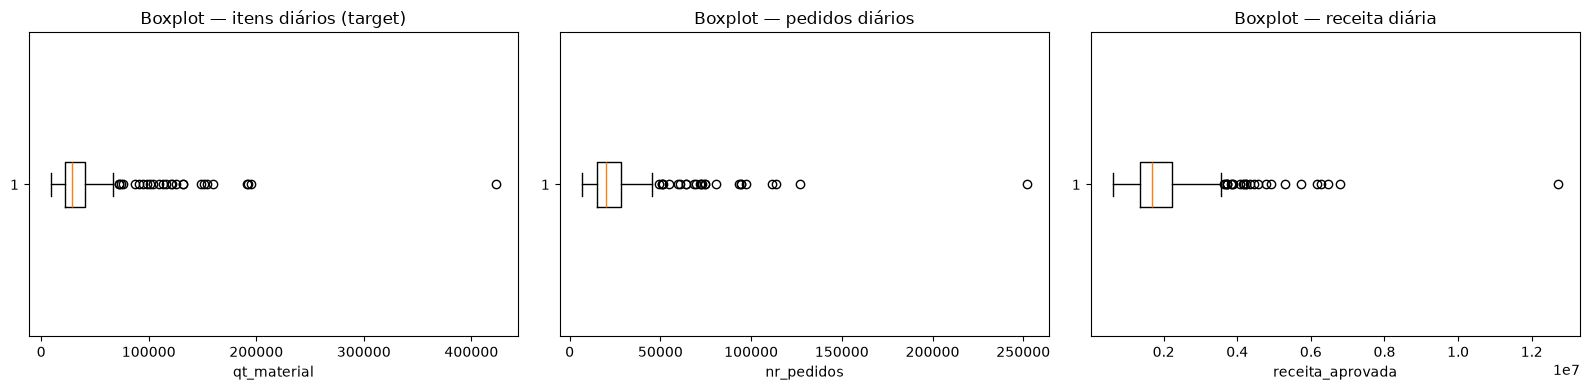

,metrica,dias
0,Outlier de qt_material,26
1,Outlier de nr_pedidos,25
2,Outlier de receita_aprovada,25
3,qt_material + nr_pedidos,23
4,qt_material sem nr_pedidos,3
5,nr_pedidos sem qt_material,2
6,qt_material + nr_pedidos + receita_aprovada,22


,data,qt_material,nr_pedidos,receita_aprovada,itens_por_pedido,outlier_qt_material,outlier_nr_pedidos,outlier_receita_aprovada
27,2025-11-28,422860,251986,"12,707,522.6100",1.6781,True,True,True
28,2025-11-29,194761,126711,"6,783,608.8600",1.5370,True,True,True
26,2025-11-27,192614,111484,"6,463,206.1100",1.7277,True,True,True
5,2025-11-06,191673,113918,"5,735,464.7400",1.6826,True,True,True
10,2025-11-11,159901,97447,"6,267,619.5000",1.6409,True,True,True
18,2025-11-19,154178,94350,"4,768,614.2000",1.6341,True,True,True
4,2025-11-05,151324,94316,"5,286,456.3800",1.6044,True,True,True
2,2025-11-03,148539,93066,"6,165,950.5600",1.5961,True,True,True
13,2025-11-14,132129,72915,"3,882,949.2200",1.8121,True,True,True
12,2025-11-13,131695,74445,"3,829,298.4400",1.7690,True,True,True


In [49]:
sql_daily_outliers = f"""
WITH daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    SUM(qt_material) AS qt_material,
    SUM(nr_pedidos) AS nr_pedidos,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1
),
quartis AS (
  SELECT
    APPROX_QUANTILES(qt_material, 100)[OFFSET(25)] AS q1_qt_material,
    APPROX_QUANTILES(qt_material, 100)[OFFSET(75)] AS q3_qt_material,

    APPROX_QUANTILES(nr_pedidos, 100)[OFFSET(25)] AS q1_nr_pedidos,
    APPROX_QUANTILES(nr_pedidos, 100)[OFFSET(75)] AS q3_nr_pedidos,

    APPROX_QUANTILES(receita_aprovada, 100)[OFFSET(25)] AS q1_receita_aprovada,
    APPROX_QUANTILES(receita_aprovada, 100)[OFFSET(75)] AS q3_receita_aprovada
  FROM daily
),
limites AS (
  SELECT
    *,
    q1_qt_material - 1.5 * (q3_qt_material - q1_qt_material) AS li_qt_material,
    q3_qt_material + 1.5 * (q3_qt_material - q1_qt_material) AS ls_qt_material,

    q1_nr_pedidos - 1.5 * (q3_nr_pedidos - q1_nr_pedidos) AS li_nr_pedidos,
    q3_nr_pedidos + 1.5 * (q3_nr_pedidos - q1_nr_pedidos) AS ls_nr_pedidos,

    q1_receita_aprovada - 1.5 * (q3_receita_aprovada - q1_receita_aprovada) AS li_receita_aprovada,
    q3_receita_aprovada + 1.5 * (q3_receita_aprovada - q1_receita_aprovada) AS ls_receita_aprovada
  FROM quartis
)
SELECT
  l.*,

  COUNTIF(
    d.qt_material < l.li_qt_material
    OR d.qt_material > l.ls_qt_material
  ) AS dias_outlier_qt_material,

  COUNTIF(
    d.nr_pedidos < l.li_nr_pedidos
    OR d.nr_pedidos > l.ls_nr_pedidos
  ) AS dias_outlier_nr_pedidos,

  COUNTIF(
    d.receita_aprovada < l.li_receita_aprovada
    OR d.receita_aprovada > l.ls_receita_aprovada
  ) AS dias_outlier_receita_aprovada

FROM daily d
CROSS JOIN limites l
GROUP BY
  q1_qt_material, q3_qt_material,
  q1_nr_pedidos, q3_nr_pedidos,
  q1_receita_aprovada, q3_receita_aprovada,
  li_qt_material, ls_qt_material,
  li_nr_pedidos, ls_nr_pedidos,
  li_receita_aprovada, ls_receita_aprovada
"""

outlier_limits = run_bq(sql_daily_outliers, "limites de outliers")
display(outlier_limits)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].boxplot(daily["qt_material"], vert=False)
axes[0].set_title("Boxplot — itens diários (target)")
axes[0].set_xlabel("qt_material")

axes[1].boxplot(daily["nr_pedidos"], vert=False)
axes[1].set_title("Boxplot — pedidos diários")
axes[1].set_xlabel("nr_pedidos")

axes[2].boxplot(daily["receita_aprovada"], vert=False)
axes[2].set_title("Boxplot — receita diária")
axes[2].set_xlabel("receita_aprovada")

fig.tight_layout()
plt.show()

# Diagnóstico complementar: os mesmos picos aparecem em qt_material e nr_pedidos?
daily_outlier_flags = daily[[
    "data",
    "qt_material",
    "nr_pedidos",
    "receita_aprovada",
    "itens_por_pedido",
]].copy()

limits = outlier_limits.iloc[0]

daily_outlier_flags["outlier_qt_material"] = (
    (daily_outlier_flags["qt_material"] < limits["li_qt_material"])
    | (daily_outlier_flags["qt_material"] > limits["ls_qt_material"])
)
daily_outlier_flags["outlier_nr_pedidos"] = (
    (daily_outlier_flags["nr_pedidos"] < limits["li_nr_pedidos"])
    | (daily_outlier_flags["nr_pedidos"] > limits["ls_nr_pedidos"])
)
daily_outlier_flags["outlier_receita_aprovada"] = (
    (daily_outlier_flags["receita_aprovada"] < limits["li_receita_aprovada"])
    | (daily_outlier_flags["receita_aprovada"] > limits["ls_receita_aprovada"])
)

outlier_overlap = pd.DataFrame({
    "metrica": [
        "Outlier de qt_material",
        "Outlier de nr_pedidos",
        "Outlier de receita_aprovada",
        "qt_material + nr_pedidos",
        "qt_material sem nr_pedidos",
        "nr_pedidos sem qt_material",
        "qt_material + nr_pedidos + receita_aprovada",
    ],
    "dias": [
        int(daily_outlier_flags["outlier_qt_material"].sum()),
        int(daily_outlier_flags["outlier_nr_pedidos"].sum()),
        int(daily_outlier_flags["outlier_receita_aprovada"].sum()),
        int((daily_outlier_flags["outlier_qt_material"] & daily_outlier_flags["outlier_nr_pedidos"]).sum()),
        int((daily_outlier_flags["outlier_qt_material"] & ~daily_outlier_flags["outlier_nr_pedidos"]).sum()),
        int((~daily_outlier_flags["outlier_qt_material"] & daily_outlier_flags["outlier_nr_pedidos"]).sum()),
        int((
            daily_outlier_flags["outlier_qt_material"]
            & daily_outlier_flags["outlier_nr_pedidos"]
            & daily_outlier_flags["outlier_receita_aprovada"]
        ).sum()),
    ],
})

display(outlier_overlap)

display(
    daily_outlier_flags[
        daily_outlier_flags[
            ["outlier_qt_material", "outlier_nr_pedidos", "outlier_receita_aprovada"]
        ].any(axis=1)
    ].sort_values("qt_material", ascending=False)
)

### Como interpretar estes boxplots

- **Caixa:** vai de Q1 (25% dos dias abaixo) até Q3 (75% dos dias abaixo). Portanto contém os 50% centrais da distribuição.
- **Linha laranja dentro da caixa:** mediana, isto é, metade dos dias abaixo e metade acima.
- **Bigodes:** chegam até a observação mais extrema que ainda esteja dentro dos limites de Tukey.
- **Círculos fora dos bigodes:** dias sinalizados como outliers estatísticos. Cada círculo é um dia.

Pelos limites calculados acima para `qt_material` (target): Q1 = **22.519 itens**, Q3 = **40.919 itens** e limite superior ≈ **68.519 itens**. Como o limite inferior é negativo (≈ -5.081), ele não é relevante para uma quantidade vendida não negativa. Assim, os **26 dias** sinalizados são todos dias acima de ~68,5 mil itens. Em `nr_pedidos` são **25 dias** acima de ~47,6 mil pedidos.

Para receita: Q1 ≈ **R$ 1,35 mi**, Q3 ≈ **R$ 2,25 mi** e limite superior ≈ **R$ 3,59 mi**. Existem **25 dias** sinalizados. A grande concentração de pontos à direita indica uma distribuição assimétrica, típica de e-commerce com campanhas e datas comerciais.

**Importante:** o ponto muito distante à direita não deve ser removido automaticamente. Ele representa um dia real que precisa ser confrontado com calendário comercial/campanhas.

### Por que olhar pedidos também?

Um dia extremo em `qt_material` pode ter duas explicações diferentes: **mais pedidos** ou **mais itens por pedido**. Ao cruzar outliers de `qt_material` com `nr_pedidos` e observar `itens_por_pedido`, conseguimos distinguir um pico de tráfego/conversão de uma mudança no tamanho da cesta. Dos 26 dias extremos em `qt_material`, 23 também são extremos em `nr_pedidos`.


### 3.2.1 Extremos por categoria × canal — qt_material

O boxplot anterior olha o e-commerce como um todo. Agora repetimos a regra de Tukey **dentro de cada categoria × canal**, porque segmentos com escalas diferentes não devem compartilhar o mesmo limite.

Para cada segmento com **mais de 20 dias observados**:

- Q1 = percentil 25%;
- Q3 = percentil 75%;
- IQR = Q3 − Q1;
- limite inferior = Q1 − 1,5 × IQR;
- limite superior = Q3 + 1,5 × IQR.

A análise abaixo considera somente `qt_material`, o target. O objetivo é responder **quando** ocorreu um extremo e **quanto** ele ultrapassou o comportamento esperado do próprio segmento.

Categorias numéricas inválidas são excluídas deste corte porque já foram tratadas separadamente como problema de qualidade.

In [50]:
sql_segment_outliers_qt_material = f"""
WITH daily_segment AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    des_categoria_material,
    des_canal_venda_final_agrup,
    SUM(qt_material) AS qt_material
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
    AND SAFE_CAST(des_categoria_material AS NUMERIC) IS NULL
  GROUP BY 1, 2, 3
),
stats AS (
  SELECT
    *,
    COUNT(*) OVER (
      PARTITION BY des_categoria_material, des_canal_venda_final_agrup
    ) AS n_dias,

    PERCENTILE_CONT(qt_material, 0.25) OVER (
      PARTITION BY des_categoria_material, des_canal_venda_final_agrup
    ) AS q1_qt_material,

    PERCENTILE_CONT(qt_material, 0.75) OVER (
      PARTITION BY des_categoria_material, des_canal_venda_final_agrup
    ) AS q3_qt_material

  FROM daily_segment
),
limits AS (
  SELECT
    *,
    q3_qt_material - q1_qt_material AS iqr_qt_material,
    q1_qt_material - 1.5 * (q3_qt_material - q1_qt_material) AS limite_inferior,
    q3_qt_material + 1.5 * (q3_qt_material - q1_qt_material) AS limite_superior
  FROM stats
  WHERE n_dias > 20
),
outliers AS (
  SELECT
    *,
    CASE
      WHEN qt_material > limite_superior THEN 'ACIMA'
      WHEN qt_material < limite_inferior THEN 'ABAIXO'
    END AS direcao,

    CASE
      WHEN qt_material > limite_superior
        THEN qt_material - limite_superior
      WHEN qt_material < limite_inferior
        THEN limite_inferior - qt_material
    END AS excesso_qt_material,

    CASE
      WHEN qt_material > limite_superior
        THEN SAFE_DIVIDE(
          qt_material - limite_superior,
          ABS(limite_superior)
        )
      WHEN qt_material < limite_inferior
        THEN SAFE_DIVIDE(
          limite_inferior - qt_material,
          ABS(limite_inferior)
        )
    END AS excesso_pct_limite

  FROM limits
  WHERE
    qt_material > limite_superior
    OR qt_material < limite_inferior
)
SELECT
  data,
  des_categoria_material,
  des_canal_venda_final_agrup,
  n_dias,
  qt_material,
  q1_qt_material,
  q3_qt_material,
  iqr_qt_material,
  limite_inferior,
  limite_superior,
  direcao,
  excesso_qt_material,
  excesso_pct_limite
FROM outliers
ORDER BY excesso_pct_limite DESC, excesso_qt_material DESC
"""

segment_outliers_qt_material = run_bq(
    sql_segment_outliers_qt_material,
    "outliers de qt_material por categoria x canal",
)

segment_outliers_qt_material["data"] = pd.to_datetime(
    segment_outliers_qt_material["data"]
)

print(
    f"Extremos encontrados: {len(segment_outliers_qt_material):,}"
    f"  (detalhe por dia em `segment_outliers_qt_material`; abaixo, só o resumo por segmento)"
)

[BigQuery] outliers de qt_material por categoria x canal | estimativa processada: 3.14 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Extremos encontrados: 376  (detalhe por dia em `segment_outliers_qt_material`; abaixo, só o resumo por segmento)


#### Resumo por segmento

A tabela abaixo mostra **quantos dias extremos** cada combinação apresentou. Ela não indica erro: mede apenas a frequência de dias que excederam os limites do próprio histórico.

In [51]:
segment_outlier_summary = (
    segment_outliers_qt_material
    .groupby(["des_categoria_material", "des_canal_venda_final_agrup"], as_index=False)
    .agg(
        n_dias=("n_dias", "max"),
        dias_outlier=("data", "nunique"),
        maior_excesso_qt_material=("excesso_qt_material", "max"),
        maior_excesso_pct=("excesso_pct_limite", "max"),
        primeiro_extremo=("data", "min"),
        ultimo_extremo=("data", "max"),
    )
)

segment_outlier_summary["pct_dias_outlier"] = (
    segment_outlier_summary["dias_outlier"]
    / segment_outlier_summary["n_dias"]
)

segment_outlier_summary = segment_outlier_summary.sort_values(
    ["pct_dias_outlier", "maior_excesso_pct"],
    ascending=False,
)

display(segment_outlier_summary)

,des_categoria_material,des_canal_venda_final_agrup,n_dias,dias_outlier,maior_excesso_qt_material,maior_excesso_pct,primeiro_extremo,ultimo_extremo,pct_dias_outlier
4,FACIAL,App,242,42,"26,721.0000",12.3537,2025-11-03,2026-05-22,0.1736
8,MAQUIAGEM,App,242,34,"31,599.7500",10.5500,2025-11-02,2026-06-17,0.1405
5,FACIAL,Site,242,33,"7,861.6250",15.9021,2025-11-03,2026-05-22,0.1364
0,CABELOS,App,242,27,"16,185.5000",5.2920,2025-11-03,2026-06-17,0.1116
15,PERFUMARIA MASCULINA,Site,242,25,"25,542.8750",8.6407,2025-11-03,2026-06-30,0.1033
1,CABELOS,Site,242,25,"4,303.3750",5.1132,2025-11-03,2025-12-01,0.1033
3,CORPO E BANHO,Site,242,25,"17,510.3750",4.9992,2025-11-05,2026-05-09,0.1033
9,MAQUIAGEM,Site,242,22,"11,609.0000",11.9067,2025-11-02,2026-05-21,0.0909
12,PERFUMARIA FEMININA,App,242,22,"45,649.2500",2.7498,2025-11-03,2025-12-12,0.0909
10,PERF. DE ENTRADA E DEOS,App,242,22,"13,671.7500",2.0633,2025-11-06,2026-05-09,0.0909


#### Leitura

Um registro como:

`PERFUMARIA FEMININA | App | 80.000 itens | limite superior 35.000 | excesso 45.000`

significa que naquele dia o segmento vendeu **45 mil itens acima do limite de Tukey calculado a partir do seu próprio histórico**.

Esse resultado continua sendo um **extremo estatístico**, não um erro. O próximo passo é confrontar os maiores excessos com contexto comercial — especialmente Black Friday — antes de decidir qualquer tratamento.

[BigQuery] top 10 dias + calendário comercial | estimativa processada: 3.42 MB


/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,data,qt_material,nr_pedidos,receita_aprovada,preco_medio_item,evento_proximo
0,2025-11-28,422860,251986,"12,707,522.6100",30.0514,Black Friday (0d)
1,2025-11-29,194761,126711,"6,783,608.8600",34.8304,Black Friday (1d)
2,2025-11-27,192614,111484,"6,463,206.1100",33.5552,Black Friday (-1d)
3,2025-11-06,191673,113918,"5,735,464.7400",29.9232,NaN
4,2025-11-11,159901,97447,"6,267,619.5000",39.1969,NaN
5,2025-11-19,154178,94350,"4,768,614.2000",30.9293,NaN
6,2025-11-05,151324,94316,"5,286,456.3800",34.9347,NaN
7,2025-11-03,148539,93066,"6,165,950.5600",41.5107,NaN
8,2025-11-14,132129,72915,"3,882,949.2200",29.3876,NaN
9,2025-11-13,131695,74445,"3,829,298.4400",29.0770,NaN


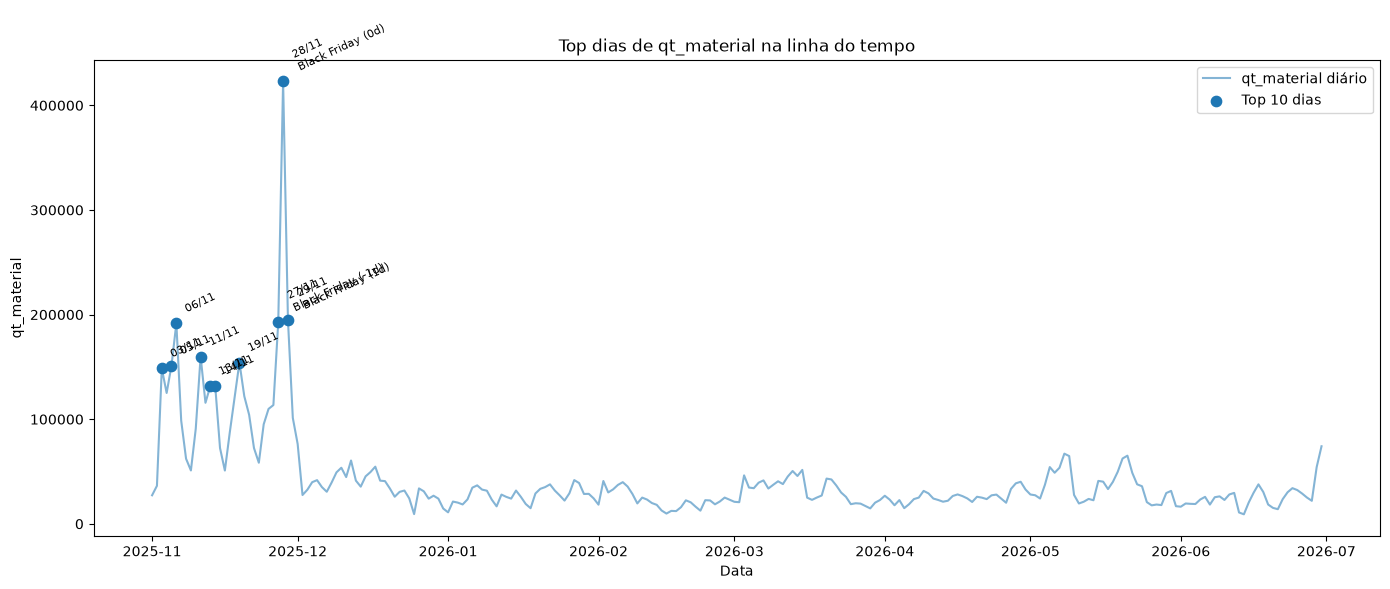

In [52]:
sql_top_days = f"""
WITH calendario_comercial AS (
  SELECT *
  FROM UNNEST([
    STRUCT(DATE '2025-11-28' AS data_evento, 'Black Friday' AS evento)
  ])
),
daily AS (
  SELECT
    DATE(dt_hr_venda) AS data,
    SUM(qt_material) AS qt_material,
    SUM(nr_pedidos) AS nr_pedidos,
    CAST(SUM(receita_aprovada) AS FLOAT64) AS receita_aprovada,
    SAFE_DIVIDE(
      CAST(SUM(receita_aprovada) AS FLOAT64),
      SUM(qt_material)
    ) AS preco_medio_item
  FROM `{TABLE_ID}`
  WHERE {DATE_FILTER}
  GROUP BY 1
),
top_days AS (
  SELECT *
  FROM daily
  ORDER BY qt_material DESC
  LIMIT 10
)
SELECT
  t.*,
  ARRAY_TO_STRING(
    ARRAY_AGG(
      IF(
        ABS(DATE_DIFF(t.data, c.data_evento, DAY)) <= 3,
        CONCAT(
          c.evento,
          ' (',
          CAST(DATE_DIFF(t.data, c.data_evento, DAY) AS STRING),
          'd)'
        ),
        NULL
      )
      IGNORE NULLS
    ),
    ', '
  ) AS evento_proximo
FROM top_days t
LEFT JOIN calendario_comercial c
  ON ABS(DATE_DIFF(t.data, c.data_evento, DAY)) <= 3
GROUP BY
  t.data,
  t.qt_material,
  t.nr_pedidos,
  t.receita_aprovada,
  t.preco_medio_item
ORDER BY t.qt_material DESC
"""

top_days = run_bq(sql_top_days, "top 10 dias + calendário comercial")
top_days["data"] = pd.to_datetime(top_days["data"])
display(top_days)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily["data"], daily["qt_material"], alpha=0.55, label="qt_material diário")
ax.scatter(
    top_days["data"],
    top_days["qt_material"],
    s=55,
    label="Top 10 dias",
    zorder=3,
)

for _, row in top_days.iterrows():
    label = row["data"].strftime("%d/%m")
    if pd.notna(row["evento_proximo"]) and row["evento_proximo"]:
        label += f"\n{row['evento_proximo']}"

    ax.annotate(
        label,
        (row["data"], row["qt_material"]),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8,
        rotation=25,
    )

ax.set_title("Top dias de qt_material na linha do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("qt_material")
ax.legend()
fig.tight_layout()
plt.show()

O calendário comercial acima é uma **camada contextual de apoio**. Para este case mantemos apenas **Black Friday**, por ser o evento comercial que queremos testar explicitamente contra os maiores picos observados.

Em produção, eventos comerciais deveriam vir de uma dimensão/calendário versionada, e não ficar hardcoded no notebook.

# 4. Relações entre métricas — Python

A partir daqui usamos a pequena visão diária já agregada pelo BigQuery. Correlação é uma ferramenta exploratória, não causalidade.

,receita_aprovada,nr_pedidos,qt_material,vlr_venda_desconto,preco_medio_item,ticket_medio,itens_por_pedido
receita_aprovada,1.0000,0.9365,0.9022,0.8575,-0.3396,-0.3734,0.2107
nr_pedidos,0.9365,1.0000,0.9832,0.8905,-0.5943,-0.6483,0.3462
qt_material,0.9022,0.9832,1.0000,0.9146,-0.6750,-0.6793,0.4775
vlr_venda_desconto,0.8575,0.8905,0.9146,1.0000,-0.5703,-0.5465,0.4800
preco_medio_item,-0.3396,-0.5943,-0.6750,-0.5703,1.0000,0.9427,-0.7862
ticket_medio,-0.3734,-0.6483,-0.6793,-0.5465,0.9427,1.0000,-0.5706
itens_por_pedido,0.2107,0.3462,0.4775,0.4800,-0.7862,-0.5706,1.0000


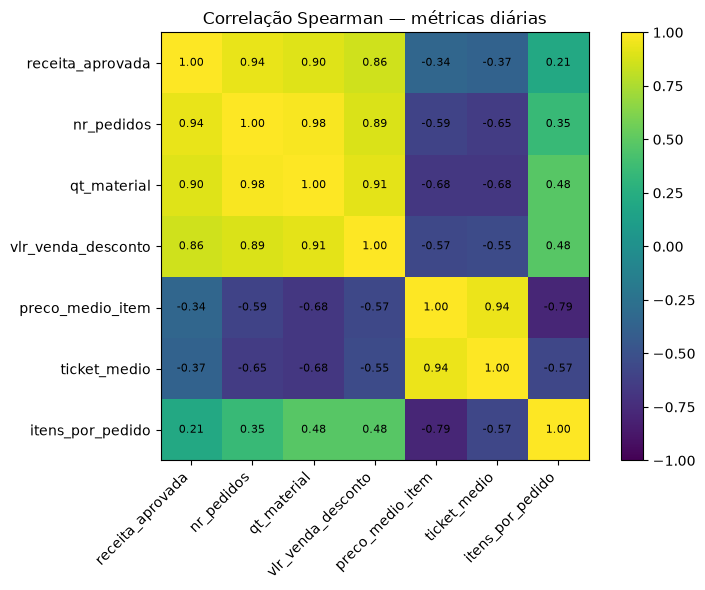

In [53]:
corr_columns = [
    "receita_aprovada",
    "nr_pedidos",
    "qt_material",
    "vlr_venda_desconto",
    "preco_medio_item",
    "ticket_medio",
    "itens_por_pedido",
]

corr = daily[corr_columns].corr(method="spearman")
display(corr)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlação Spearman — métricas diárias")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax)
fig.tight_layout()
plt.show()

# 5. Model Readiness

### Target proposto
**`qt_material` diário**: demanda em unidades, que é o que a operação planeja (estoque, reposição, separação). Também é aditivo entre categorias e canais.

`nr_pedidos` fica como métrica de apoio. Como vem agregado por hora × categoria × canal, um pedido com itens de duas categorias provavelmente é contado nas duas; a soma diária não é o número de pedidos distintos (hipótese a validar com o negócio). `receita_aprovada` permanece como KPI financeiro.

`receita_aprovada` permanece como KPI financeiro e pode ser modelada em uma análise complementar.

### Risco de leakage
Para prever o dia *t*, métricas realizadas do próprio dia *t* não podem ser features: receita, pedidos, itens, desconto e mix realizado do mesmo período só existem depois da venda.

### Features candidatas
- calendário: dia da semana, mês, fim de semana;
- lags `t-1`, `t-7`, `t-14`, `t-28`;
- rolling mean/std calculados apenas com passado;
- lags de preço médio, receita e pedidos;
- tendência temporal;
- feriados/datas comerciais, caso sejam adicionados como fonte conhecida antes da previsão.

### Validação
Split aleatório não é apropriado. Usaremos **backtest temporal / expanding window**.

### Baselines obrigatórios
- naive t-1;
- naive sazonal t-7;
- média móvel histórica.

### Métricas
MAE, WAPE, Bias e Skill vs baseline. MAPE será tratado com cautela.

# 6. Resumo executivo

In [54]:
top_day = top_days.iloc[0]
top_weekday = weekday.loc[weekday["qt_material_mediana"].idxmax()]
bottom_weekday = weekday.loc[weekday["qt_material_mediana"].idxmin()]
peak_hour = hourly.loc[hourly["share_qt_material_media"].idxmax()]

executive_summary = pd.DataFrame([
    {
        "tema": "Data Quality",
        "insight": (
            f"{float(invalid_category.loc[0, 'pct_categoria_invalida']):.2%} "
            "das linhas possuem categoria inválida."
        ),
        "implicacao": "Preservar vendas nos totais e excluir apenas de análises categóricas.",
    },
    {
        "tema": "Receita negativa",
        "insight": (
            f"{float(negative_revenue.loc[0, 'pct_linhas_negativas']):.2%} "
            "das linhas têm receita negativa."
        ),
        "implicacao": "Validar estorno/devolução/ajuste antes de qualquer tratamento.",
    },
    {
        "tema": "Maior dia de demanda",
        "insight": f"{top_day['data']} — {int(top_day['qt_material']):,} itens.",
        "implicacao": "Picos legítimos devem ser aprendidos pelo modelo, não removidos mecanicamente.",
    },
    {
        "tema": "Dia da semana",
        "insight": (
            f"Maior mediana: {top_weekday['dia_semana']}; "
            f"menor: {bottom_weekday['dia_semana']}."
        ),
        "implicacao": "Dia da semana é uma feature relevante.",
    },
    {
        "tema": "Intradiário",
        "insight": f"Hora de maior participação média: {int(peak_hour['hora'])}h.",
        "implicacao": "Existe padrão horário relevante para planejamento operacional.",
    },
])

display(executive_summary)

,tema,insight,implicacao
0,Data Quality,5.96% das linhas possuem categoria inválida.,Preservar vendas nos totais e excluir apenas d...
1,Receita negativa,3.92% das linhas têm receita negativa.,Validar estorno/devolução/ajuste antes de qual...
2,Maior dia de demanda,"2025-11-28 00:00:00 — 422,860 itens.",Picos legítimos devem ser aprendidos pelo mode...
3,Dia da semana,Maior mediana: Quarta; menor: Domingo.,Dia da semana é uma feature relevante.
4,Intradiário,Hora de maior participação média: 11h.,Existe padrão horário relevante para planejame...
